# DIMER Notebook: Modern Image Classification and Transfer Representations
## From ResNet to MobileNet, ConvNeXt and Vision Transformers

**Notebook profile:** `E2E`  
**Pedagogical mode:** `WORKSHOP`  
**DIMER Notebook Specification:** `2.1`  
**Comparison scope:** `MULTI-MODEL`  
**Standalone:** yes  
**Canonical task:** six-species image classification  
**Adaptation:** frozen backbone + identical six-class linear probe

This notebook compares six live DIMER image-classification backbones:

1. ResNet-50
2. MobileNetV4-Conv-Small
3. ConvNeXt-Tiny
4. ViT-B/16
5. SwinV2-Tiny
6. EVA-02 Base 448

The native ImageNet heads are not compared. Every checkpoint is instead treated as a frozen feature extractor, then the exact same linear classifier is fitted on top of its representation.

> **Interpretation boundary:** this is a **pretrained checkpoint comparison**, not a pure architecture ablation. The models differ in architecture, pretraining data, training recipe, model capacity and native input resolution.

**AI Use Disclosure:** Generative AI assisted with this notebook’s code and instructional content under maintainer direction. The maintainer remains responsible for review, validation, and release decisions. AI-generated material may contain errors; validation claims are limited to documented runs and configurations. AI use does not imply independent verification, provider endorsement, or release approval.

## How to use this notebook

**Who it is for.** Learners who can run Python cells in Colab/Jupyter and are new to modern vision backbones, frozen representations, or transfer learning.

**Runtime.** Use the documented GPU runtime for the six-backbone comparison, on **Linux x86_64** (Google Colab, Kaggle or a Linux Jupyter server). The setup cells build an isolated Python 3.12.12 environment from Linux wheels; Windows and macOS kernels are not supported.

**How to run it.**
1. Select the documented runtime/accelerator.
2. Choose **Run all** for the canonical path; leave the default settings unchanged on your first pass.
3. Read the explanatory markdown while the notebook runs.
4. Sections marked **Infrastructure** support reproducibility, model acquisition, or orchestration. Run those cells as written; understanding their implementation is not a learning objective.

### Task at a glance

`image → frozen pretrained backbone → representation → k-NN / common linear probe → predicted species`

### Roadmap

1. Understand the task and its input/output contract.
2. Inspect and validate the built-in data or inputs.
3. Establish the baseline/reference behavior.
4. Run the model or multi-model comparison.
5. Inspect errors, disagreements, robustness, and/or resource tradeoffs.
6. Try one controlled change and explain what changed.
7. Write an evidence-based conclusion; optionally continue with BYOD.

### What successful execution looks like

You should finish with a validated input/sample, the notebook's principal baseline/reference, model outputs and evaluation results, at least one diagnostic or qualitative comparison, and machine-readable results/provenance where supported. Exact values can vary slightly across supported runtimes; focus on the defined metrics and the observed pattern.


## 1. Why not compare the native ImageNet heads?

The built-in heads all predict ImageNet classes, while this notebook uses six bird species outside a clean shared six-class mapping.

A direct comparison would mix model quality with an arbitrary ontology-mapping policy.

The controlled experiment is instead:

`image → frozen pretrained representation → identical six-class linear probe`

## 2. Architectural progression

- **ResNet-50:** residual convolutional network.
- **MobileNetV4:** efficiency-oriented mobile convolutional network.
- **ConvNeXt-Tiny:** modernized ConvNet informed by transformer-era design choices.
- **ViT-B/16:** global self-attention over fixed image patches.
- **SwinV2-Tiny:** hierarchical transformer with local shifted-window attention.
- **EVA-02 Base:** high-capacity transformer with masked-image-modeling lineage and a 448×448 input.

The final comparison therefore spans both architectural ideas and practical deployment envelopes.

## Setup: isolated environment

> **Infrastructure.** Run these two cells as written; understanding their implementation is not a learning objective.

Hosted runtimes such as Colab import some packages, NumPy among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env/`) and leaves the kernel's packages untouched:

1. it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match;
2. `uv` creates a managed CPython **3.12.12** environment, whatever Python the kernel itself runs;
3. it installs the 53 packages of the carried hash lock (`tools/modern-image-workshop-requirements.lock`, compiled from the pins listed in Section 4) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact wheel that was locked.

The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message. The first run downloads PyTorch with its CUDA libraries and takes several minutes; a re-run in the same runtime reuses the environment.

In [1]:
# @title Infrastructure: build the isolated environment (uv, CPython 3.12.12, hash-locked wheels)
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
# Generated by tools/build_modern_workshop_runtime.py from tools/modern-image-workshop-requirements.lock.
import hashlib
import io
import os
import platform
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = "requirements.lock.txt"
LOCK_SHA256 = '3779dd39199db78f7e32f727447327ae0efef96b9c18e563609c8701478002d6'
LOCKED_PACKAGES = 53
# The hash-locked requirements: `uv pip compile --generate-hashes` for CPython 3.12 on x86_64-manylinux_2_28,
# compiled from the notebook's direct pins (listed again in Section 4).
# Carried in pieces of at most 1,000 characters.
LOCK_TEXT = (
    '# This file was autogenerated by uv via the following command:\n#    uv pip compile tools/modern-image-workshop-requirements.in --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: --index-url https://pypi.org/simple -o tools/modern-image-workshop-requirements.lock\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via requests\ncharset-normalizer==3.5.2 \\\n    --hash=sha256:01077390b03f7988f11d700a2194e69b119741a86b1a638b1db88891e3eced8e \\\n    --hash=sha256:01b0c0d2262a9e28e8484a278c7e1b5d650e3ac8cf2683d2967e25899f208bdf \\\n    --hash=sha256:04851f73ae72b8413dddadb16a49dfee95263553741fd42d546f7d66907e6be5 \\\n    --hash=sha256:0521c5665880b33d603717defa76c094048900010897909952397feb3039da56 \\\n    --hash=sha256:0774bf9bf620249fee3e0b8b9fd3065de213be30f3aa94ce2494b3b638949e26 \\\n'
    '    --hash=sha256:0891b9d3903c5571c03771ca669a4b0ec5618ca722a5c957d3d29cd4e5062848 \\\n    --hash=sha256:0c951d5e6dd9c2ff60609476752bee49da4206adde960ebc247766937f72e718 \\\n    --hash=sha256:0fed1d06615f022ee3b13caf5e8b180cfea32bb2c5aded8a9d44277afc040f93 \\\n    --hash=sha256:114e4d0c92d618409ed82a99e22b5c5e768fe995f2973f78265f4524f49d4640 \\\n    --hash=sha256:11912e4bb14baae7c5d8791aa55ba0a3a03ec6729073307b0f57270abaa713d3 \\\n    --hash=sha256:11a4d68a6ecda3292cb1e50239e111543ba5d709bb62a6b4ea1afcfa729d8875 \\\n    --hash=sha256:124fbf1a8ff966d87ae05bb8bd45a71f966055ed8bba320d0c7cf450bc5f4d0e \\\n    --hash=sha256:1461ac396c4fdb983a675f20aa555624f0ee18ac83d832b9244ffff3d8055275 \\\n    --hash=sha256:1503bccbeb36d5527790c3930327704c39af22de3112f1b1666a9f3ce15ee204 \\\n    --hash=sha256:15bb4005af6320d259dc7593ca84a38d7fe06a421dbcf7b910ae23979101e787 \\\n    --hash=sha256:15c44f7edfd477b06f517a5cc317fc1707edb9de2c865f43d4b6513907473234 \\\n'
    '    --hash=sha256:16fa0eccf81304b79c5cd87f9271c3b85dd9dd99245e4422ae9c0dd45e0f99d3 \\\n    --hash=sha256:183b88127acdb4fabe59d951ab424faf1af7b63cdbb5f776186c1ea2ffcaed98 \\\n    --hash=sha256:195c26fb65950f8fce54e26349852b7bdd7c5f120aeefbcc440b8a20faaed4a3 \\\n    --hash=sha256:1afb975bd5d68d5ce9f6b6d44fdf2f7e34b895a35e95708a7a91b20a3b51d187 \\\n    --hash=sha256:1b4cbc7c3491ccb4aa17fcd8165649d01cf39f76de1696da8631b5f71b85401d \\\n    --hash=sha256:1bc0baf5ef96b6ede57d47f4b8fe4d9d84019c3bfcbeb20a41edc6a6ee341f1f \\\n    --hash=sha256:1c50fe28bbc2ced33386f298650d91218076c05420e6cbd790b913adc41659e7 \\\n    --hash=sha256:1db38f4c5496827c1a501846d64d14c3b80c7e6714e406cd7dc36a9899fa1011 \\\n    --hash=sha256:211d5a3eb6af8f513b8d4ca19a8c1b7accab1b5f0d3175f9826b03c1a920dc1f \\\n    --hash=sha256:23851fb4e1b85ed3f6c2a27b777cdfe2e19fb5b38429a8faf38c7542b7665869 \\\n    --hash=sha256:254eb48b9fa5ee9898a3c445825a1f340fe53712a098904b39b0bddba8ea3cb1 \\\n'
    '    --hash=sha256:2625388c6c754520c37abaf3b41eb34d1cc4a373f457898f08606c8e362b891d \\\n    --hash=sha256:281cb91036248400f4cc957495cccd44c275c2e0c5854f7e45ac5cf7dc193847 \\\n    --hash=sha256:28a15fdad492a99b6eccfaaed66ef3f74050680545ea61ec8b2f4c538f1f1320 \\\n    --hash=sha256:28b4f0d66fb834ff90f28209ac7bce77868c45d8c93e26f906709d9b7c2e1af9 \\\n    --hash=sha256:2a925889534b3748302dae5dead07cc13480de1dac3aea80a941b729b471ef93 \\\n    --hash=sha256:2b7b3bbfb4fe8ef40600792d762fbaa9057559f9d3fad209525b7a22b99e91fd \\\n    --hash=sha256:2c9ad19a6cfcd5ea5c0d41161d22f9df1dcc277e9bef2751391334546a314c00 \\\n    --hash=sha256:2cc961b171b3f3440f410489ab3573e86aea8736134ebbb40ea1338b7f0831bc \\\n    --hash=sha256:2ce45c6627b22c47e390bc91a41c3d13032192e699fa0bea96e9671b373d69b0 \\\n    --hash=sha256:2e06a3a98f916dd41d27f3105e02e7a40181c98c94b9158733d03a6f80506c09 \\\n    --hash=sha256:304d5463e65a35d7bb0850550e0780395395f6fcf452f04db7d5ca7cecc425ac \\\n'
    '    --hash=sha256:304d8e4d493af723536393eee0c689eb7813f4a474c8b479dee63f1fdd98f621 \\\n    --hash=sha256:30fcd120b732aa79317f08dee04d7de0847822e4cf7ee0e9f445bb958832252c \\\n    --hash=sha256:31f3930700408d211f13378ccbe1c40845d8da54bd0681fac3a9b5aae81c7aa8 \\\n    --hash=sha256:34276fd796040bf0993ab33a369aa572e6979c7aab225a88893667ad8eac8f7a \\\n    --hash=sha256:355ad8011081dec5412240c087a9a0c9d4d5039f3ed11a3f13e18c2b29b56c51 \\\n    --hash=sha256:38a873987f3be698494da8b2e3085e29da02da7b633dce73e79c699a113d7bf0 \\\n    --hash=sha256:39de2a259fc954455c57274dc94c79d5842774e1247a016aff30bc0efed0f4ef \\\n    --hash=sha256:3d14b50de6bf4d0edf857a9386836846f982b8f524e188e2e68b96d702bcf4aa \\\n    --hash=sha256:3d21b8b13c7592db2ac5e544a6d83187b995257472b0c9e8351b6d507ae37ed6 \\\n    --hash=sha256:3d31298449090ab8d47b7b1b2a555ff73cac7ed438a08b7ac160980c7ebed649 \\\n    --hash=sha256:3ddacd27458c45bdacd6bd6db644bfb730efbf9e830310186e3045c9c5be8fb2 \\\n'
    '    --hash=sha256:3df041de8887954562c9b261cba85ca0e9ded74048daf125f45edcfaa4832229 \\\n    --hash=sha256:40ab6bffa02ae10a0581e6c198be7d2d8ca5c2a0c64e4ed3465d766df457573e \\\n    --hash=sha256:4275811936e2f06feff5e598fb42a1b7ae852da8e39605211892b56b81a34efd \\\n    --hash=sha256:443eae2bf318abeaf6f15d785138f71fd6de770e99a92158b8b814265e079115 \\\n    --hash=sha256:447441e76ec720b15e64418d32e092297340387053047c7c694f579efb0ee1d9 \\\n    --hash=sha256:4495c5002a7b28557e7e222e77e0b661183e432b7d6d2e788101e3f240e05b8c \\\n    --hash=sha256:44bd4fbb29dfbeba60e7d2bd000c59e4b21ddb3cc53912b14048d37092706d7c \\\n    --hash=sha256:4685902cf26edf013ed7a3da0f426ebba7a00ebb9541386d835afbf002c11cab \\\n    --hash=sha256:498dc3188ca05a68231ac3fdbfc7f57eb67e1343c30e0fea17f8218c1599b253 \\\n    --hash=sha256:4c2b5031f63e331e3839b40aed2dd6f191e9c07edbde303e7876846ea1946995 \\\n    --hash=sha256:4d48f2d08b9de5864e2c8744d4461b862fb149a18274abc8b698c45975573438 \\\n'
    '    --hash=sha256:4f87960d57feabfb618e4e0af6e7371645fa26a277860739d6e5d6e0012c92f0 \\\n    --hash=sha256:50e3adfb96fc189eb27b1cf62d3b598b89b4bb0420d93a3d3e42e137409011be \\\n    --hash=sha256:51cf45226a9b588d0d2b4880c62d686934b63ab0bd79ca23ab0e9762eb27441b \\\n    --hash=sha256:52aa6992700996af31f375de0c6bacd402b0097fe40b53c426b9f51a90ebabc7 \\\n    --hash=sha256:55ea99acb17b9325618de155a0cd6a2e8f5d10be008113e1d433bbb58db543b2 \\\n    --hash=sha256:56bc200a365efb37383b7852e4cc5898d3b2da5987289b543956cf8cad71018a \\\n    --hash=sha256:588461c2e8384d309bd63e5826019b6977bc66d629b99ac8737bb795d7b2cb5a \\\n    --hash=sha256:58ca3755ee7ff7f59b57789ec9833c9de9ea275405cdd240eda1f193112e398a \\\n    --hash=sha256:58f361dcbab699cf8f42db3f47c8e7fd1036f138c23a5d08de9fde5f425a730c \\\n    --hash=sha256:598a11a2c7ebaa5334bf698bf29568c9c390abac6a154d8170fedecd1cea38c5 \\\n    --hash=sha256:59f63901b0031c3136cf64704dcb21de0bbae62ce2c9529bc39d27665463de37 \\\n'
    '    --hash=sha256:5cde776b7cc66e4f6c99612cea4aa7269aa65863f7a15841b2c264f103822f4e \\\n    --hash=sha256:5e2b6b57e9733d39f0c9fd3185efa6b8e29652c4cd8fe94180272cf6ed9a78c4 \\\n    --hash=sha256:5fb29fb8cd1a46c27a1bf9613ad5ec2599310d46b4025d9556404a6b6a292800 \\\n    --hash=sha256:6045373d5a89a5ec71afde535db987ca28e76dfa276c2d4c818265b375d4b055 \\\n    --hash=sha256:619799369eeef6366ed3e8755a5670f4f2f0fb6b30a0fd7264dc0fdc2357058e \\\n    --hash=sha256:62588a277bfb59def052abd940703fa35107152bf479781a878617d60faf8fb5 \\\n    --hash=sha256:62603db9a7caa0802eaa28c1c46fecd7b3a263a774069c24c3c28c302448721c \\\n    --hash=sha256:65cd72beeeca9d3aaea1201e5923859f308f952f9c71de93f06063c79f0f7a3b \\\n    --hash=sha256:68eb192d85ab8e5f6ec69c2bc6ac0179fbf04a5ac1569d12fbef74883fe102d0 \\\n    --hash=sha256:6bd128f206a7752ae1f2ab6c61bf8a24ba28913a10df8b14c2637b973ff97a80 \\\n    --hash=sha256:6be488a102b8cf28d0391d8c4ba7748938ae28b78ad901f8585520fca33ead1a \\\n'
    '    --hash=sha256:7218e8f32b0956cfcd048fd42d9d5779809745ca1d86113ca56f66e7ae1549c4 \\\n    --hash=sha256:7441d755b7ab94f8d4eb3e43ec05482d760842fd263d003a99102d742cd835e2 \\\n    --hash=sha256:749e97e1b32313717a565abbe321bc2190bc8b35f1a67e4cdbc7c56c8d8ffe58 \\\n    --hash=sha256:75a3ceed0724d625d64b86ca20aba182e4df462e04c2414fc941c0f523f06aac \\\n    --hash=sha256:780fbe7cab297b81dad9fb8dc5eb003c0468ffb0d9e5f65068c53a34661a96bc \\\n    --hash=sha256:78456a747de8dc58360ffa581f30a002baf5aa28cb262536545e91f113ed7639 \\\n    --hash=sha256:7967d08cf06dee78443b874f98c98036f624f3a4e73e11f9f64f5be4d25393cf \\\n    --hash=sha256:7a881931aa470808df94a8c380eed2bbbc76cd9dc622310f99665658c821eb6d \\\n    --hash=sha256:7dcd882da75ef9adf94903b1e3b9419e8aa8fb4c7396822b834b9ef7fb96954f \\\n    --hash=sha256:7e841fb9010836c992c9f12fcbd43a831de93a5f726fc1ccd8ca1d0268c5014c \\\n    --hash=sha256:7fdde2c9fd9e3eca40631e024664cf2584272cc8f96308cbe5fdfc930f51d8bc \\\n'
    '    --hash=sha256:8024d00c3faf3fc0c16e07a69f4405e8eac7cc0ab15f65fe6cf43827c4cf72b4 \\\n    --hash=sha256:80d02b6f04e92601a081dd97b23d3128033098bff5d35d392ddcc0476ea11253 \\\n    --hash=sha256:838dcc90063569a0448120554591a1d6c4a4ffe11babf048908793154ab86ade \\\n    --hash=sha256:849df64e889b2e17230d58410a03dba311a65b163508fd33679b2b737d4b7858 \\\n    --hash=sha256:87475fabc8d9996fd9c27debb395e642e8c838d78a00b6e932227a0e06b81e26 \\\n    --hash=sha256:87e50a3e7cb90af586b6c5faf23e302a970415ac73bd7bd90a515a04b427ef96 \\\n    --hash=sha256:89b53f3cda69831909888e0494f4fa0bcd3537e3e138dabeb620bd6ad946bae8 \\\n    --hash=sha256:8a893cc101149f80a653f82062ebc95b34525a2614382e1da5458fe7c6997249 \\\n    --hash=sha256:8b2bfab86aa71ae13aa41a6a26aab338e0db2b8bc75434b05aea89e011ff35a4 \\\n    --hash=sha256:8d86d6fc60743dc916eb79e2eb1ec4818e21e427731543af40a3021851174a13 \\\n    --hash=sha256:915563965d418f986e7e145accc592eae9e1a1be3566ff98a05d7a9ec42a76e1 \\\n'
    '    --hash=sha256:92888bb3187c5ba50500b00b3b310c9f2c651709d28036077680cb5255450a03 \\\n    --hash=sha256:93223adc95033dd47133a46ccfc316a0139176fd79085762e27202ec56018f03 \\\n    --hash=sha256:9373ad13ef0d2c0fb761e04e55bfdee5a08b52cef2c882c8fbe9935b1517152e \\\n    --hash=sha256:9409a8bf35cf78353942504b24a57de3d75b708997a1e4bd8db71ac8633ce364 \\\n    --hash=sha256:9b7f416ff0978e2f2249330527f0ad6fa02f4932e6199692d3b52da2048c19e4 \\\n    --hash=sha256:9bde855991b7e362c146535e3136a50bfaffc0487d38b33ca7e5edefc6e23849 \\\n    --hash=sha256:9cae88599c7219005d879f98e5ed53341e9a122af585e1091200358a3003d2a0 \\\n    --hash=sha256:9cf9b1a857e25c4baceeb3624e92a56df3668f398c4acba74e174d81fb4d1d3a \\\n    --hash=sha256:9f56f72050826f63dcee7a7f55b0a77168cb3bfc553fd405e7f8f9ece75a4036 \\\n    --hash=sha256:a090bb2c68df85450502e3e20d665e3a5af9c65a84d6508ed477badd49166fd3 \\\n    --hash=sha256:a192e2c40070d92c3ccf777e3a5c4ff515573cd2bb7ed0c537fdadbbec5bbf21 \\\n'
    '    --hash=sha256:a19a731138fc27d5682277d3b9df22855cea1239bce7fcec5f78f42ef2d1f3c3 \\\n    --hash=sha256:a66c3bc5ab1f0ff2164fc9965ddd611ff0802173f4b9d24554c563f6ab7e1d6e \\\n    --hash=sha256:a815775b6c38d4e0ff7bcffbeba67feded90202bb6a226b8dd35f1c855217413 \\\n    --hash=sha256:a89012d6d5476ee112d20d998570ed58df2260a852afb1758809cd6900411d21 \\\n    --hash=sha256:ae4f5fea5b8b8ccff88238cc8569303e5ee95efae67fa62922a311397a71f346 \\\n    --hash=sha256:b6856554c4f44d79fc2307d5768854310a8f0096e501c75637542c82292b0429 \\\n    --hash=sha256:b6b751274acb69d77b3323d6b7dbaa3c7fdfc1eb829b7eb61d262f32e1af9685 \\\n    --hash=sha256:b736353c0a625bbd5fcec108576e2385db3496f4f771f785ff32e108d3c3bc45 \\\n    --hash=sha256:b7fd005a73d9e657273b7a10dc71a9e03c8fb9ee6999798d6918ce095b81ac7f \\\n    --hash=sha256:b91363207bd9dc966a691e959bb47f64b30f7ac4b072be9968b366982f7db77c \\\n    --hash=sha256:ba0b1d2620edf869789c3879223f52bf2afc5d31b3cb47cc57b3a12c05e2aa9d \\\n'
    '    --hash=sha256:bbbfc8e28816f19d7c0f1816664980c0a9875d01b27cdf8eedddb639d9e108ad \\\n    --hash=sha256:bd16aabe4a02a297c23417aa17ac6299dbd8c49f673bcd645b4929b11f5a4400 \\\n    --hash=sha256:c0afc6800ba57ccc350374c5bd6150419915d95ce93cdbab2d783d75eaf30ecb \\\n    --hash=sha256:c6708715abcf3c73b99508253e961a9967f02fe536532834149574eda6de0d1c \\\n    --hash=sha256:c7c9ab723cde841fefb34efbad91e87f00a674b1fe1cd0784fde742bf2c154dc \\\n    --hash=sha256:c8f3d67aeaf55f017982b73683f0e7342ba2f6635a78f69ce89ebb26aa411e5c \\\n    --hash=sha256:c9790464842f85f437dbbb54417eda1e0e6bfc52dd8d22d6fd1c994b73b2dc74 \\\n    --hash=sha256:ca403d7e4798f525fdfc78e258820419cbbd0f0ecbab9de7840e3c017cf6b8cf \\\n    --hash=sha256:d008d90a7f2471519aef0c90dfbe73b3e6e4d5e66ac48e19154c17e89e98b604 \\\n    --hash=sha256:d19fbd981a488e22cd04883659ca6b08f50b5974f9fd7c95655ef6a043e5893f \\\n    --hash=sha256:d1befeed746d247c81127bb14de9dc3d30edb6e5976d34f83f86ed262b1d9105 \\\n'
    '    --hash=sha256:d2374b62878abb00cd8309b32af6c0b715cd02dec0ca74ef12e5069bdc64144a \\\n    --hash=sha256:d376bbd28b3a8999db1a103b3b388aee6f1ddeb3e51bc2172993efdcd86e064d \\\n    --hash=sha256:d4a7319f304a774bed22115bc891618e45f85065ab44ea6acd07d274e750519a \\\n    --hash=sha256:d6734d2ef8a50fbf8445c139477da401f50d62a0606bf00e20ec6d87773fefb1 \\\n    --hash=sha256:d760fe2a4d7c3b226cb9026d6a842868d52a7901bd98420e1baf14e80da85cf5 \\\n    --hash=sha256:d913de495d90407cd859d263bee2e5d1a4ed3eb6573c04e70d9ec619a7cbed7f \\\n    --hash=sha256:db19d07e2e0129e974a0e65d0064fc222a446cd5122c2fd4184d2af9fc734a9e \\\n    --hash=sha256:dca9ab98072a5a54ebacebdc45f53e645336b320c667410b061be1ca588ae709 \\\n    --hash=sha256:ddc7dacc8ece3a182e7f15cb862d1fd616b46d076cb1ae9dd232b2c38b655874 \\\n    --hash=sha256:ddf19c062bea7a0cc80f519243d2c01dd091be0cf952a0750d4ad576709559f5 \\\n    --hash=sha256:def79fa35ef0cef8d2accec024f4fdc7ead3012ff02f5215c783f39f03ef8cfc \\\n'
    '    --hash=sha256:df29a0a7107f7011e77f4eebdddec4c7331e24d787a0b21a46d63bdf7445da95 \\\n    --hash=sha256:e09a3942ecbdee5cce73ea9d42da82b81b72ac1bf031ce069b93b5adf4eac8cd \\\n    --hash=sha256:e242bb1c5e76e97dfa9e7f209a71e93a01d7f19ffdd5cfbb2e2d55b4f08f8ab0 \\\n    --hash=sha256:e243bd13217235fc7290c621941c3f5cc8b66e4872495be821d7436ba2fb838d \\\n    --hash=sha256:e2af3aad578aa6bd1384bcf4750fc285e5a9de53f40b7d41e5a0bf748edeb2b3 \\\n    --hash=sha256:e4e81e09c1578b8df602e3db08b0b3ea0a6947ad612f52bf8dc5ea8d47691f0c \\\n    --hash=sha256:e54da4baf05720032d527874d40b65fa4d7e5c6c6a43d0c3adbeffcaf275a2b3 \\\n    --hash=sha256:e80e6c2f55656b4824d72065abb4ddd6a525c74bd78a0aab5d9fc2cf4fb5af50 \\\n    --hash=sha256:ed2a239c0ea213acc1908150a3037257083c7c083128f1a4cec2ec4b97dca491 \\\n    --hash=sha256:ed905975ab14056a2e5eb1c376cb2e1ebc5396baf84163939c518556fccde9f5 \\\n    --hash=sha256:ee21e28f0430bd6dc9086c6e525d5e818a44a5ad19720c8a0ef766792f3eb5e5 \\\n'
    '    --hash=sha256:ee43c17b173d46a3212baa6ead3ae258eeabdae48c263a01ccf0218c366dd655 \\\n    --hash=sha256:ef4fcbf3327382cd4c9f540babd61248208af7b93eec4de397b4d5f58a09e288 \\\n    --hash=sha256:eff0ac9dbe711a4aee69bf04a83896aa9b85f19641264053a9f6d48573abb7dd \\\n    --hash=sha256:f0aa869112ef88429ae17820d99c3dd9504c9e9c671d3c246f3d7442cb051084 \\\n    --hash=sha256:f3c96f633825733f735c5a9cf21d21a257d8e1edf0b1cee0a064b9c424ca0f7d \\\n    --hash=sha256:f5833ad231be5eb6553de524a70f48d71b2c8563101750531e0b80184e175cd4 \\\n    --hash=sha256:f5ec61164adcec446f8969a3358ec3f9b26bbda3b9213e5586d219afa8df2915 \\\n    --hash=sha256:f7d486c83842422badd511868fd8a9a20e9407ace71564b6af47ce7e60a336c1 \\\n    --hash=sha256:fb9e68df06293761f9fe66ade60a9bc6d0f5e42b8acf2939a9158af86ab0e5bd \\\n    --hash=sha256:fc14a032f813bf5fe624d991960ea83e9715adc27e4c1830a2361eb1d02ac341 \\\n    --hash=sha256:fcff63213e8e6e47770541a4607175404f47cbb3ebea7b6058cc82d524a0e424 \\\n'
    '    --hash=sha256:fd1fbe0f116b6e55da77aca2c6ddcddcfac2186cbf78bdebf40fc156efca389d \\\n    --hash=sha256:fe9753dfee015c570d73df76f899f18444d41388bffcde097deba51c4fadbb9f\n    # via requests\ncontourpy==1.4.0 \\\n    --hash=sha256:018227e134b73090b06f911e773a526c77c9af426be29065500ce096a5accd4c \\\n    --hash=sha256:072a702e2e178f4fcf96f04775d0c059e4c917925abf0d3208ebb6865df3c23d \\\n    --hash=sha256:0c7a4c2716a4e98342221954416a836cca77c996c14ddbf22b5f01d5d93ca09c \\\n    --hash=sha256:107ec46f7aa1664266d69b1181aadc953d58d39f7d8d648fa5b795d4a060b0de \\\n    --hash=sha256:181bea01bc742734ae672fa00c717d855dd35e1f029536406538c52e7b0cd73d \\\n    --hash=sha256:186ba929df36d61b6127da2e89cd1357e4cb79aca647381ab1a6feb0b152877b \\\n    --hash=sha256:196759a3e4db60e1546167e361090ebb6d199aa3aafc9e34ea17a5ac3b23e814 \\\n    --hash=sha256:20156f5a1ac4f8ce02656e39a61e82164a3d359796dc8026f75b062783d500e1 \\\n    --hash=sha256:20da2f86bfaed60dbba729fe738c8241b1dd22b6cf7e8cbbf30df290bd04ba28 \\\n'
    '    --hash=sha256:2deb580178ca19437a84bd77e4bc2cd91a8ccad212413a83c273900868b5978c \\\n    --hash=sha256:2e741a39dfc96babe1722561e81351aeec104526c57dbe91c167c1db606c2d55 \\\n    --hash=sha256:3863ef2e2b13fe93f8c0ebb08ee400cb07153b8b0e91c5acb26e4537f283634f \\\n    --hash=sha256:3e0a2392533e5e2abdf277c951047516acc8d2f3c42b2dd9dc34c907c9ebabf2 \\\n    --hash=sha256:404dbcd9233513dfd1323b66ea593fef90e899f658f6b8a9ed8e93bd0ca669db \\\n    --hash=sha256:417be048f7e122cefbe2a34c51a1f2b0410f8eb35796f794d45475ddb7872d9d \\\n    --hash=sha256:423bd5f4b3f11d54a8c597234e513382e3454bb106b8ec7ae32ba4ed63f8d99b \\\n    --hash=sha256:432e89f835cf01f8d2123a130a3126b17ee6e0348e4d62c0973872b30aa873bf \\\n    --hash=sha256:43c3ccbb32c6294b183dcc8e8c46dacf5ecef809497e3d48a5be298eef185ad0 \\\n    --hash=sha256:43d80072a32299bf945de0a6dd4e034ea0162e832261de2e07a274a5adbba9c9 \\\n    --hash=sha256:4bffcb2e8cc5c0e837631acab59dd04265fdac376550e7c3e310523877c68cb7 \\\n'
    '    --hash=sha256:510f7d93d94cf6ebf4e2cd0640bea16ab8affac7547230175b6745b596ce0599 \\\n    --hash=sha256:5450f091ac1be0be3ad3a2a3b3f23b5e443e78c670ced4fd347d626f92a28fd2 \\\n    --hash=sha256:5545ff38229c15d11d822fc6f7415b932da9f4975f53e305b7b96ebfb01f889c \\\n    --hash=sha256:5a4c89c7f38a0d7a94356d74e3391073c4325c4d47ad2fd065c3fe7dbae16c0c \\\n    --hash=sha256:61624f6722480aa7e168fd746164e7bfdf48f8ccb6542f1613741200dc37e2b1 \\\n    --hash=sha256:618137ec5778fb76d494c9ec854b104a377fddba0d128bef7136cce2c3bf0df8 \\\n    --hash=sha256:630d32f06cedf37b7f1dd2b6a12e4492826bd477a4c9c7b2e2fee6ce3a2cea76 \\\n    --hash=sha256:64039341e2d8804f1a13bda8c69083eab935167bbd7e856cf096241f17d5bd45 \\\n    --hash=sha256:6507a016976a75a15aee47809a34605de6244ccc056e6164bf9fb14b27eecad4 \\\n    --hash=sha256:6ced1670fafee703b8277ab1645072a226e74f167166eae146fb743916119b67 \\\n    --hash=sha256:6e697d94e69f499ff6bebb899cae97a58d5d14f0e1fe9568b43a0248d2f9af8c \\\n'
    '    --hash=sha256:6f963ea9f0d68d2b6a02d861e3c0aae09ae25ba21f243fcf281e9fed468b078d \\\n    --hash=sha256:738c44fa71735a617f36da58e32810512407d283d5d1bb5b1cecb00d7eeba7cf \\\n    --hash=sha256:758e7496cec3195fc28a28945eab3ceef348c47fb95c7afc2eca2f3901209c8c \\\n    --hash=sha256:78ed5c5f962b3e156109f0531b174a65ba80d13cc681a70227b12524c162e184 \\\n    --hash=sha256:79b06c60d5e569ce12c5da8f0c51217cdc484386e2349fa717c30fafb56d2871 \\\n    --hash=sha256:7f861af508fca2384eef392bc1d8377cfa349b2b854cb11b45d89c75780e2561 \\\n    --hash=sha256:80c7fc8e7ac217777ce7ba2db3cf8478652b5a4b335283111012ff9eaac9d842 \\\n    --hash=sha256:86d05cec773c9507a3950122e0e40ce77c23c75ceeb2fc189514e71893cbb34b \\\n    --hash=sha256:875f42444c9cf48d56f724f2637e60d0f73b3b12c9041e1484580a233edf9591 \\\n    --hash=sha256:90feb8da006803a95ba573fddc9536357d0c3faddc3a4c9e22816ca49af52878 \\\n    --hash=sha256:912c6afaa106e2f74ba22b30416b77ef7eb94e3bdc5a4df51ab147845dba9b6d \\\n'
    '    --hash=sha256:96019f059bcb3774acc0104be3360a57b36d33eaaa2e1d7f77c800ca8e07618b \\\n    --hash=sha256:9c0e07c691f3b3321913ed9b8161c50ea5f77fadd006f52f5e755359b0dcbfc5 \\\n    --hash=sha256:a03b32c2e7eda8b17757c022162c13c86f5c3d6f937dddf9ba3c3ff7b513953b \\\n    --hash=sha256:a1c8a74744fa746eeaa12f0f9ed7f8b4add9d8f1b14d95e3b5e133675eac888f \\\n    --hash=sha256:a3e67bc1a6a4618a1dac7c3053a9ffece5ddfa2046b2670b342cf430bb0b87d1 \\\n    --hash=sha256:a58b5f130afec61a093d743cdda435cc4047748b6791627e34a68f41ec3a9b07 \\\n    --hash=sha256:a5e2bb871b90cd7a52bdee63bf80ef7acb46398d27efc66d7679240016efc5aa \\\n    --hash=sha256:abd0f7e51ecc52bf8c95713bd80b1c17c516a71fa391c54475308a4377903c2b \\\n    --hash=sha256:b7794ea07cab575633daad8d6e963b662053391022294d3aacc1d9ba9ef54114 \\\n    --hash=sha256:b9dc493e7924e5aa32d89d0b8e50986280f3d4b284968a792787bd7bcffd3cad \\\n    --hash=sha256:be85d160e7c795113c2a93254dde2fc7e86b375322570eee78b420969426973c \\\n'
    '    --hash=sha256:bee6ff96653e0807cd0f8eaef00174a031e3a2effa5c20f49a5a8d574b05af23 \\\n    --hash=sha256:c76f3a5318164db7d9401132fc1b5364b784c613c93fa506e3b5e6d1bf353ec8 \\\n    --hash=sha256:c8be3392b84cf43373a488874dc1ebf46f60784a70977f92586e18019d71c7ed \\\n    --hash=sha256:c927ec747633e68c9920bcaad48b0bcefe648812b822f18c34e2d0e2270a3d2a \\\n    --hash=sha256:cc87f2ffa84a49a77d76cb792f28a48ff3b05a222aa0b2bddbd839ba78e1d5ca \\\n    --hash=sha256:dd59df9e2fb0aff8bd7fd1adb9f349b7c835245a9d0f18c2f2deeb537190f2b1 \\\n    --hash=sha256:ddf5a2596d716fd3793434844caf31abc7a40b1e8718431420c89858268fb909 \\\n    --hash=sha256:de503609fdb71f597634ca64fb4bd2f13d27c97f140e912b1e8ed93544840df0 \\\n    --hash=sha256:e21d1d4a9db5b3a793649c7ab0ddb4697f2818929eec871a7b9c45fce7b2a1ea \\\n    --hash=sha256:e439ab450c93455feb0218532ded3e946ec7a9b5f459069f122cfa44b89229f6 \\\n    --hash=sha256:ea09dc704029930cbd097f75cb0cc1db9852adbcf1a151fac7e9559f7bcbfd19 \\\n'
    '    --hash=sha256:ef47fef9a912c77e3d84b014f701e5a9340f25703e9ed3bcebe37f91fb69dc49 \\\n    --hash=sha256:ef9440f6f8506246269a82734f5ff9e2e4c5e775b3996fc883cc491c5257eca6 \\\n    --hash=sha256:f1219a8898523cba821085f2da8a1b962cc696325763f09d7f93538ba43b2d70 \\\n    --hash=sha256:f863c6100bf926cf47d13f3cd75f9bb8ebd98aaab230eeb4468b91f98f39a6b3 \\\n    --hash=sha256:fa1b787362a3856e63dd2b89449f6c384d55ee1beb8f94f4bcc871b40f02462c \\\n    --hash=sha256:fc9feef8f1f001c5b87decadc67c4a5d1eebb62ca39c4763d1237ff62cf2b707\n    # via matplotlib\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n'
    '    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n'
    '    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.3 \\\n    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f\n    # via cuda-bindings\ncuda-toolkit==13.0.3.0 \\\n    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f\n    # via torch\ncycler==0.12.1 \\\n    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \\\n'
    '    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c\n    # via matplotlib\nfilelock==4.0.9 \\\n    --hash=sha256:635e7d67fa92654eed444e75e9ca18426d34e77ad9c469bf4373f75a932f7b22 \\\n    --hash=sha256:9287fd61b99a806e5202be29a83034c0808a1b9830e820537c2f5773981f7eeb\n    # via\n    #   huggingface-hub\n    #   torch\nfonttools==4.66.1 \\\n    --hash=sha256:058cd823b80bac59e64dfad9e3b6fcd677852f9a3804971bbf6b48cc611e785c \\\n    --hash=sha256:05aeb146451f37289f782c3c861f3d0f4b86c2dd2e4620b46683544c7406640e \\\n    --hash=sha256:05c0fff6b4a5d872ed89cab2c4f81060b86ace263903eb4e8d0edcac47a60dfa \\\n    --hash=sha256:08d8956e3ec990c75230d92f1630b215e8f3738c83a003421c22b31ebfd0ce15 \\\n    --hash=sha256:09ae73bd219e1245debd8376077a0fa6e03175e255c4f51bae5f6a271bfe384a \\\n    --hash=sha256:0dc6fd99cb8c30941036308b148da9432640442a6f26f36d71dad9be24cbd0e9 \\\n    --hash=sha256:1801fdad5600118327171e0e8aa79f7cc48831dd55ab36998c9de03bd5ffe6cd \\\n'
    '    --hash=sha256:261d8dc95845e751f975fe8d6075600593ee253470d46d1b84801688051b09f6 \\\n    --hash=sha256:2aeb745f2664eb811026997c95628071137a777ea2ad296deec9cb393f0b23cf \\\n    --hash=sha256:2c7340497cf53490293e0c2b61011e0191633022ede0a0a964a68157a98b0fb4 \\\n    --hash=sha256:2ce4c93160535761f22c80b2afbc96cabc09855363a5d1a5554265b8a4c85901 \\\n    --hash=sha256:2d320483928c7831f0139ecb361954a26b2e2a8995681200155835dd8cd4a7d5 \\\n    --hash=sha256:2d637468dac23aac0e223bd52e66f8faa3b0dfcef57435460fa2107e830226cd \\\n    --hash=sha256:3087a430722aba8de429c2539fd2a58a9cf05238cdfefd8626460001052ca878 \\\n    --hash=sha256:34378db9a398b59de18cc79d942f0a907c6fc6301945e065ec888202f607aa3f \\\n    --hash=sha256:36bb24d4b98faacaff04af1d5e0a4285feba6ed1da6728cd34b6b6deb6bbb934 \\\n    --hash=sha256:38ce8f5fbd5c17dd2153d47d7c8d4108f3deda3f2b4a79b60ddc470a58faded3 \\\n    --hash=sha256:43d1284c1964666ee833f2badd3017dc138f53d4889043ffca66c5ce4188f188 \\\n'
    '    --hash=sha256:53e5854ea8003efec34adc0863c18ce91da923018354d27366f7fee7db928d7a \\\n    --hash=sha256:56d41d650cb8fc6cfe1d85ed7c62a0a56cbeed07bc65ca795475b914d401312a \\\n    --hash=sha256:5de5d80fbc0e50ff794c244e8fb7afd3eadfe0fa232ba8b162b8c551df22fcb4 \\\n    --hash=sha256:60f5ea17aed4262630afa43f26997ceabd6417fa05dcedf54c665f5a29193e18 \\\n    --hash=sha256:64967c6ddb0d4c610dfd8cb1485981b2d27972ddfb7d4bbbd9e199d2a089c450 \\\n    --hash=sha256:668f092bc0de8902167df6a0d5c5aedc3b4f9e43cf88eea92e9b46a2bd3968f5 \\\n    --hash=sha256:66fad3b7874062c2a2692f0ae6dea56d24f01b778c7f191950ca3ff997e25a88 \\\n    --hash=sha256:6946fe7bfb28590a1fd4061a17609c9a843952deb65dcf30d1fe725070c3e7a4 \\\n    --hash=sha256:71c7ca1b5f46f5dd549f56b47d47c0b709217675c23d3a7bc6aa1a69b6d9bbae \\\n    --hash=sha256:72299346b96b9244dabcc051b24e4653da4edfda6105544cfb10ce856a1afaac \\\n    --hash=sha256:7234ae9e28db64273fbbfa72caebd0a97e3bdba6b05064114741b9539ef339d0 \\\n'
    '    --hash=sha256:7b8ff9e0edbcee2fbf7dff0c41b9041c1901c26acf64e23adb67495012df11de \\\n    --hash=sha256:7cf4f996f9b1cb549bff9ea4c50813988a26ec922c95cfa85c7e4f1270447e06 \\\n    --hash=sha256:7f49f2834f5d006fe0f3bb10fec73b261806c50941f0cfbc08294074ffc32210 \\\n    --hash=sha256:83572afe48733bad7a4a9c11721d3a726c2e976d82b063fc9bdd049d76955abd \\\n    --hash=sha256:8526b2b7ec4db6b81efb83438be52b1264eda9a4994d867163cfe8c65581ce8d \\\n    --hash=sha256:8aed2bbcd6216253ef1b015763593365ee8084f621dfa53bb957c19d5e05f7cd \\\n    --hash=sha256:90de3477394c73481d27d2b86091c1c736053ee13ff52c42f0e151948e8578c6 \\\n    --hash=sha256:9261ef507f2dd74203443a472b65b5a26429eb378f975016dec7dc7305b24898 \\\n    --hash=sha256:9ea6c93091cbf83161a544388746a0911550bd98cb911faca3591cf5ead166ac \\\n    --hash=sha256:b13c8c541ce0b794add3211b3641cc0e113d707f73e06235e6fe9731bd7c45a9 \\\n    --hash=sha256:b18803cbdef248e7ee1be59cb277fbbe1da1faaa6f726fa5d3557904e6a3d967 \\\n'
    '    --hash=sha256:b878c78b2af11b879bd4f26bb0d8bda2a4c64543fdd3f28efe2c80f97f043885 \\\n    --hash=sha256:b8b71db96d605784e2c5ebf0788a406018ea8fdd80338491f4c83613d5cd1fec \\\n    --hash=sha256:b913b8e9f7ca9bec44d1eb919f591c596c61041aa357c96be55ff93169859e91 \\\n    --hash=sha256:c258eba62260beb33c110b03a6912cefa3635239c4ab5615b7225fb6f7b85238 \\\n    --hash=sha256:c47299bca4b5acaaeb32100f77b944feea151de9ef1773365a410dc3d49b945b \\\n    --hash=sha256:c666fefdd5613a0e99aa4516e6ff4ef87aa86cf1c7ba12a73550f4770e46b750 \\\n    --hash=sha256:c724e56213494c6695335577822b2d1628d102e71614de8b7eb8e30886d6a314 \\\n    --hash=sha256:d3b5403e82d0c7659ff1d9f956e29a3a68d094f043e9f5bc0442796fc3a4fb58 \\\n    --hash=sha256:d4f76868aea9cc4ce47fdbeaa904c02ee7d85dd0ad095071ae77f0bda6e62cf5 \\\n    --hash=sha256:d84ac0bf776b68396185bd919dd29e633d94300660335efc40b55b294b886903 \\\n    --hash=sha256:d8f0a8f16c4f3a5a87ca971de2631792d8cb4d570951f2000acf712f157d40db \\\n'
    '    --hash=sha256:dbb7b950f8c02deaffb6968994691e8589d671b7ef8396bc9d5b5c0dfbb7292f \\\n    --hash=sha256:dfba62cc93199ba62c376f90f2a9147d92730d301e44f88e013e50ff5edf6193 \\\n    --hash=sha256:e1cde50b3ec84ca6fe63ca815de183dbecb88e8adf8ada82d8ea130ef12b2b43 \\\n    --hash=sha256:e7ea7a08547a453fa000db96ed5714a3dc7e2b4255b9243f897921f8c10c169a \\\n    --hash=sha256:eef76d5796e604f9d6753fa6d323c4eb9f4e0e43f1dcca553f3e6914f1667b64 \\\n    --hash=sha256:f08ab7f8461c37ecfdd29ad97fb0c0780b50501bd664bb0f46b6e83ed2b9d2a7 \\\n    --hash=sha256:fdf4afd75c643e60ef4a96fe64fc8a9def27d2a542112332371a9e5066885f9a\n    # via matplotlib\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via\n    #   huggingface-hub\n    #   torch\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n'
    '    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n'
    '    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhuggingface-hub==0.36.2 \\\n    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \\\n    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270\n    # via\n    #   -r tools/modern-image-workshop-requirements.in\n    #   timm\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via requests\njinja2==3.1.6 \\\n'
    '    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nkiwisolver==1.5.1 \\\n    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \\\n    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \\\n    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \\\n    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \\\n    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \\\n    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \\\n    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \\\n    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \\\n    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \\\n'
    '    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \\\n    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \\\n    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \\\n    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \\\n    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \\\n    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \\\n    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \\\n    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \\\n    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \\\n    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \\\n    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \\\n'
    '    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \\\n    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \\\n    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \\\n    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \\\n    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \\\n    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \\\n    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \\\n    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \\\n    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \\\n    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \\\n    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \\\n'
    '    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \\\n    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \\\n    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \\\n    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \\\n    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \\\n    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \\\n    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \\\n    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \\\n    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \\\n    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \\\n    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \\\n'
    '    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \\\n    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \\\n    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \\\n    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \\\n    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \\\n    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \\\n    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \\\n    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \\\n    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \\\n    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \\\n    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \\\n'
    '    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \\\n    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \\\n    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \\\n    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \\\n    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \\\n    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \\\n    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \\\n    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \\\n    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \\\n    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \\\n    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \\\n'
    '    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \\\n    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \\\n    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \\\n    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \\\n    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \\\n    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \\\n    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \\\n    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \\\n    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \\\n    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \\\n    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \\\n'
    '    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \\\n    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \\\n    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \\\n    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \\\n    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \\\n    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \\\n    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \\\n    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \\\n    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \\\n    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \\\n    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \\\n'
    '    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \\\n    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \\\n    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \\\n    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \\\n    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \\\n    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \\\n    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \\\n    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \\\n    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \\\n    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \\\n    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \\\n'
    '    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \\\n    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \\\n    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \\\n    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \\\n    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \\\n    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \\\n    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \\\n    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \\\n    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \\\n    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \\\n    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \\\n'
    '    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \\\n    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \\\n    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \\\n    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \\\n    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \\\n    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \\\n    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \\\n    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \\\n    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \\\n    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \\\n    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \\\n'
    '    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \\\n    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \\\n    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \\\n    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \\\n    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \\\n    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \\\n    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \\\n    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \\\n    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \\\n    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \\\n    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \\\n'
    '    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \\\n    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \\\n    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \\\n    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \\\n    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \\\n    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \\\n    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \\\n    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \\\n    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \\\n    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \\\n    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404\n    # via matplotlib\nmarkupsafe==3.0.4 \\\n'
    '    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \\\n    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \\\n    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \\\n    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \\\n    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \\\n    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \\\n    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \\\n    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \\\n    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \\\n    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \\\n    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \\\n'
    '    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \\\n    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \\\n    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \\\n    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \\\n    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \\\n    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \\\n    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \\\n    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \\\n    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \\\n    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \\\n    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \\\n'
    '    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \\\n    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \\\n    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \\\n    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \\\n    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \\\n    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \\\n    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \\\n    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \\\n    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \\\n    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \\\n    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \\\n'
    '    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \\\n    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \\\n    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \\\n    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \\\n    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \\\n    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \\\n    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \\\n    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \\\n    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \\\n    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \\\n    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \\\n'
    '    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \\\n    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \\\n    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \\\n    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \\\n    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \\\n    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \\\n    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \\\n    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \\\n    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \\\n    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \\\n    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \\\n'
    '    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \\\n    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \\\n    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \\\n    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \\\n    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \\\n    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \\\n    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \\\n    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \\\n    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \\\n    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \\\n    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \\\n'
    '    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \\\n    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \\\n    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \\\n    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \\\n    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \\\n    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \\\n    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \\\n    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \\\n    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \\\n    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \\\n    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \\\n'
    '    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \\\n    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \\\n    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \\\n    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \\\n    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \\\n    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \\\n    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \\\n    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \\\n    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \\\n    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \\\n    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \\\n'
    '    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \\\n    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \\\n    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \\\n    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \\\n    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \\\n    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \\\n    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \\\n    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \\\n    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \\\n    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \\\n    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \\\n'
    '    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \\\n    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \\\n    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \\\n    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \\\n    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \\\n    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \\\n    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \\\n    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \\\n    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \\\n    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \\\n    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \\\n'
    '    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \\\n    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \\\n    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \\\n    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \\\n    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \\\n    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \\\n    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \\\n    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \\\n    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \\\n    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \\\n    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \\\n'
    '    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \\\n    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \\\n    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \\\n    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \\\n    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \\\n    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \\\n    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \\\n    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \\\n    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \\\n    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \\\n    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \\\n'
    '    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \\\n    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \\\n    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \\\n    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \\\n    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \\\n    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \\\n    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \\\n    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \\\n    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \\\n    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \\\n    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \\\n'
    '    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \\\n    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \\\n    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \\\n    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \\\n    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \\\n    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \\\n    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \\\n    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3\n    # via jinja2\nmatplotlib==3.10.6 \\\n    --hash=sha256:05be9bdaa8b242bc6ff96330d18c52f1fc59c6fb3a4dd411d953d67e7e1baf98 \\\n    --hash=sha256:08f141d55148cd1fc870c3387d70ca4df16dee10e909b3b038782bd4bda6ea07 \\\n    --hash=sha256:08fc803293b4e1694ee325896030de97f74c141ccff0be886bb5915269247676 \\\n'
    '    --hash=sha256:091cea22e059b89f6d7d1a18e2c33a7376c26eee60e401d92a4d6726c4e12706 \\\n    --hash=sha256:13fcd07ccf17e354398358e0307a1f53f5325dca22982556ddb9c52837b5af41 \\\n    --hash=sha256:1565aae810ab79cb72e402b22facfa6501365e73ebab70a0fdfb98488d2c3c0c \\\n    --hash=sha256:1678bb61d897bb4ac4757b5ecfb02bfb3fddf7f808000fb81e09c510712fda75 \\\n    --hash=sha256:1b53bd6337eba483e2e7d29c5ab10eee644bc3a2491ec67cc55f7b44583ffb18 \\\n    --hash=sha256:25f7a3eb42d6c1c56e89eacd495661fc815ffc08d9da750bca766771c0fd9110 \\\n    --hash=sha256:2adf92d9b7527fbfb8818e050260f0ebaa460f79d61546374ce73506c9421d09 \\\n    --hash=sha256:30fdd37edf41a4e6785f9b37969de57aea770696cb637d9946eb37470c94a453 \\\n    --hash=sha256:31ca662df6a80bd426f871105fdd69db7543e28e73a9f2afe80de7e531eb2347 \\\n    --hash=sha256:376a624a218116461696b27b2bbf7a8945053e6d799f6502fc03226d077807bf \\\n    --hash=sha256:3d80d60d4e54cda462e2cd9a086d85cd9f20943ead92f575ce86885a43a565d5 \\\n'
    '    --hash=sha256:470fc846d59d1406e34fa4c32ba371039cd12c2fe86801159a965956f2575bd1 \\\n    --hash=sha256:491e25e02a23d7207629d942c666924a6b61e007a48177fdd231a0097b7f507e \\\n    --hash=sha256:4d6ca6ef03dfd269f4ead566ec6f3fb9becf8dab146fb999022ed85ee9f6b3eb \\\n    --hash=sha256:4dd83e029f5b4801eeb87c64efd80e732452781c16a9cf7415b7b63ec8f374d7 \\\n    --hash=sha256:56cd2d20842f58c03d2d6e6c1f1cf5548ad6f66b91e1e48f814e4fb5abd1cb95 \\\n    --hash=sha256:590f5925c2d650b5c9d813c5b3b5fc53f2929c3f8ef463e4ecfa7e052044fb2b \\\n    --hash=sha256:59c8ac8382fefb9cb71308dde16a7c487432f5255d8f1fd32473523abecfecdf \\\n    --hash=sha256:658bc91894adeab669cf4bb4a186d049948262987e80f0857216387d7435d833 \\\n    --hash=sha256:662df55604a2f9a45435566d6e2660e41efe83cd94f4288dfbf1e6d1eae4b0bb \\\n    --hash=sha256:6f4a69196e663a41d12a728fab8751177215357906436804217d6d9cf0d4d6cf \\\n    --hash=sha256:70aaf890ce1d0efd482df969b28a5b30ea0b891224bb315810a3940f67182899 \\\n'
    '    --hash=sha256:7bac38d816637343e53d7185d0c66677ff30ffb131044a81898b5792c956ba76 \\\n    --hash=sha256:819e409653c1106c8deaf62e6de6b8611449c2cd9939acb0d7d4e57a3d95cc7a \\\n    --hash=sha256:83847b47f6524c34b4f2d3ce726bb0541c48c8e7692729865c3df75bfa0f495a \\\n    --hash=sha256:84e82d9e0fd70c70bc55739defbd8055c54300750cbacf4740c9673a24d6933a \\\n    --hash=sha256:886f989ccfae63659183173bb3fced7fd65e9eb793c3cc21c273add368536951 \\\n    --hash=sha256:8913b7474f6dd83ac444c9459c91f7f0f2859e839f41d642691b104e0af056aa \\\n    --hash=sha256:8fa4c43d6bfdbfec09c733bca8667de11bfa4970e8324c471f3a3632a0301c15 \\\n    --hash=sha256:905b60d1cb0ee604ce65b297b61cf8be9f4e6cfecf95a3fe1c388b5266bc8f4f \\\n    --hash=sha256:942a8de2b5bfff1de31d95722f702e2966b8a7e31f4e68f7cd963c7cd8861cf6 \\\n    --hash=sha256:94f0b4cacb23763b64b5dace50d5b7bfe98710fed5f0cef5c08135a03399d98b \\\n    --hash=sha256:9df5851b219225731f564e4b9e7f2ac1e13c9e6481f941b5631a0f8e2d9387ce \\\n'
    '    --hash=sha256:a3276c85370bc0dfca051ec65c5817d1e0f8f5ce1b7787528ec8ed2d524bbc2f \\\n    --hash=sha256:abb5d9478625dd9c9eb51a06d39aae71eda749ae9b3138afb23eb38824026c7e \\\n    --hash=sha256:acc86dd6e0e695c095001a7fccff158c49e45e0758fdf5dcdbb0103318b59c9f \\\n    --hash=sha256:bc31e693da1c08012c764b053e702c1855378e04102238e6a5ee6a7117c53a47 \\\n    --hash=sha256:bc7316c306d97463a9866b89d5cc217824e799fa0de346c8f68f4f3d27c8693d \\\n    --hash=sha256:c7e0518e0d223683532a07f4b512e2e0729b62674f1b3a1a69869f98e6b1c7e3 \\\n    --hash=sha256:cbd5eb50b7058b2892ce45c2f4e92557f395c9991f5c886d1bb74a1582e70fd6 \\\n    --hash=sha256:cc332891306b9fb39462673d8225d1b824c89783fee82840a709f96714f17a5c \\\n    --hash=sha256:d00932b0d160ef03f59f9c0e16d1e3ac89646f7785165ce6ad40c842db16cc2e \\\n    --hash=sha256:e228cd2ffb8f88b7d0b29e37f68ca9aaf83e33821f24a5ccc4f082dd8396bc27 \\\n    --hash=sha256:ea117a9c1627acaa04dbf36265691921b999cbf515a015298e54e1a12c3af837 \\\n'
    '    --hash=sha256:ec01b645840dd1996df21ee37f208cd8ba57644779fa20464010638013d3203c \\\n    --hash=sha256:ee1d607b3fb1590deb04b69f02ea1d53ed0b0bf75b2b1a5745f269afcbd3cdd3 \\\n    --hash=sha256:f2d684c3204fa62421bbf770ddfebc6b50130f9cad65531eeba19236d73bb488 \\\n    --hash=sha256:f3b23315a01981689aa4e1a179dbf6ef9fbd17143c3eea77548c2ecfb0499438 \\\n    --hash=sha256:f44c8d264a71609c79a78d50349e724f5d5fc3684ead7c2a473665ee63d868aa \\\n    --hash=sha256:f56a0d1ab05d34c628592435781d185cd99630bdfd76822cd686fb5a0aecd43a \\\n    --hash=sha256:f7173f8551b88f4ef810a94adae3128c2530e0d07529f7141be7f8d8c365f051 \\\n    --hash=sha256:f9c862d91ec0b7842920a4cfdaaec29662195301914ea54c33e01f1a28d014b2\n    # via -r tools/modern-image-workshop-requirements.in\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n'
    '    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n'
    '    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n'
    '    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n'
    '    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n'
    '    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n'
    '    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n'
    '    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   -r tools/modern-image-workshop-requirements.in\n    #   contourpy\n    #   matplotlib\n    #   torchvision\nnvidia-cublas==13.1.1.3 \\\n    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \\\n    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \\\n    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n'
    '    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via\n    #   cuda-toolkit\n    #   nvidia-cublas\nnvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.24.0.43 \\\n    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \\\n    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \\\n    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n'
    '    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n'
    '    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.1 \\\n    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \\\n    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \\\n    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215\n    # via torch\nnvidia-nccl-cu13==2.30.7 \\\n    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \\\n    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50\n    # via torch\nnvidia-nvjitlink==13.4.92 \\\n'
    '    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \\\n    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \\\n    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \\\n    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\npackaging==26.3 \\\n'
    '    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   huggingface-hub\n    #   matplotlib\npillow==11.3.0 \\\n    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n'
    '    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n'
    '    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n'
    '    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n'
    '    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n'
    '    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n'
    '    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n'
    '    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n'
    '    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n'
    '    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n    # via\n    #   -r tools/modern-image-workshop-requirements.in\n    #   matplotlib\n    #   torchvision\npyparsing==3.3.3 \\\n'
    '    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \\\n    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4\n    # via matplotlib\npython-dateutil==2.9.0.post0 \\\n    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \\\n    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427\n    # via matplotlib\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n'
    '    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n'
    '    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n'
    '    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n'
    '    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n'
    '    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n'
    '    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n'
    '    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   huggingface-hub\n    #   timm\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via huggingface-hub\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n'
    '    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   -r tools/modern-image-workshop-requirements.in\n    #   timm\nsetuptools==84.0.0 \\\n'
    '    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nsix==1.17.0 \\\n    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \\\n    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81\n    # via python-dateutil\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntimm==1.0.29 \\\n    --hash=sha256:1af8d12bb7e15c5f96e98d60b7b8319cd7f31730778bf1af58e912a7ce171576 \\\n    --hash=sha256:4266486e355c9beb9432e689de580d09e2efe7fa92a9a79e76c03e7763eac724\n    # via -r tools/modern-image-workshop-requirements.in\ntorch==2.14.0 \\\n    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \\\n'
    '    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \\\n    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \\\n    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \\\n    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \\\n    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \\\n    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \\\n    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \\\n    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \\\n    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \\\n    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \\\n    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \\\n'
    '    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \\\n    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \\\n    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \\\n    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \\\n    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \\\n    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \\\n    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \\\n    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \\\n    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \\\n    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \\\n    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \\\n'
    '    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963\n    # via\n    #   -r tools/modern-image-workshop-requirements.in\n    #   timm\n    #   torchvision\ntorchaudio==2.11.0 \\\n    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \\\n    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \\\n    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \\\n    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \\\n    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \\\n    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \\\n    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \\\n    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \\\n    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \\\n'
    '    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \\\n    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \\\n    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \\\n    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \\\n    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \\\n    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \\\n    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \\\n    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \\\n    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \\\n    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \\\n    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \\\n'
    '    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \\\n    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \\\n    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \\\n    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \\\n    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \\\n    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \\\n    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \\\n    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84\n    # via -r tools/modern-image-workshop-requirements.in\ntorchvision==0.29.0 \\\n    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \\\n    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \\\n'
    '    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \\\n    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \\\n    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \\\n    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \\\n    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \\\n    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \\\n    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \\\n    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \\\n    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \\\n    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \\\n    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \\\n'
    '    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \\\n    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \\\n    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \\\n    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \\\n    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \\\n    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \\\n    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \\\n    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \\\n    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \\\n    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \\\n    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e\n    # via\n    #   -r tools/modern-image-workshop-requirements.in\n'
    '    #   timm\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via huggingface-hub\ntriton==3.8.0 \\\n    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \\\n    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \\\n    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \\\n    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \\\n    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \\\n    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \\\n    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \\\n    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \\\n'
    '    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \\\n    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \\\n    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \\\n    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3\n    # via torch\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n    #   huggingface-hub\n    #   torch\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via requests\n'
)

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"
ISOLATED_ENV = Path(os.environ.get("DIMER_ISOLATED_ENV", "dimer_isolated_env")).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / "bin" / "python"
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + "_tools")

if SKIP_INSTALL:
    print("DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; "
          "the notebook runs in this kernel.")
else:
    if platform.system() != "Linux" or platform.machine() != "x86_64":
        raise RuntimeError("This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux "
                           "Jupyter): its locked environment is built from manylinux x86_64 wheels.")
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode("utf-8")).hexdigest() != LOCK_SHA256:
        raise RuntimeError("The carried lock does not match its digest: "
                           "restore this cell from the repository.")
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding="utf-8", newline="\n")
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError("The pinned uv wheel failed its size/SHA-256 check: refusing to run it. "
                           "Run this cell again; if it repeats, the download is being altered.")
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith(".data/scripts/uv"))
        uv = ISOLATED_TOOLS / "uv"
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ)
    for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        print("Creating the isolated Python", MANAGED_PYTHON, "environment...", flush=True)
        subprocess.run([str(uv), "venv", "--quiet", "--managed-python", "--python", MANAGED_PYTHON,
                        str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run(
        [str(ISOLATED_PYTHON), "-c", "import platform; print(platform.python_version())"],
        env=uv_env, check=True, capture_output=True, text=True,
    ).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f"{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: "
                           "delete that folder (or start a fresh runtime) and run this cell again.")
    print("Installing the hash-locked packages "
          "(several minutes on a fresh runtime; the CUDA wheels are large)...", flush=True)
    subprocess.run([str(uv), "pip", "install", "--quiet", "--python", str(ISOLATED_PYTHON),
                    "--require-hashes", "--only-binary", ":all:", "--index-url", "https://pypi.org/simple",
                    "-r", str(lock_path)], env=uv_env, check=True)
    print({"isolated_environment": str(ISOLATED_ENV), "isolated_python": isolated_version,
           "kernel_python": platform.python_version(), "locked_packages": LOCKED_PACKAGES,
           "setup_seconds": round(time.perf_counter() - setup_started)})

Creating the isolated Python 3.12.12 environment...
Installing the hash-locked packages (several minutes on a fresh runtime; the CUDA wheels are large)...
{'isolated_environment': '/content/dimer_isolated_env', 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 53, 'setup_seconds': 65}


The next cell starts one Python process in that environment and routes **every later code cell** to it. Printed output and figures come back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. These two cells are marked `# dimer: kernel cell` and are the only cells that run in the kernel, so there is no restart step. If you re-run a single cell later, it still runs in the isolated environment with the variables created so far; to start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [2]:
# @title Route the remaining cells to the isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import signal
from multiprocessing.connection import Connection

from IPython import get_ipython as _kernel_shell

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    try:
        import google
    except ImportError:
        google = types.ModuleType("google")
        google.__path__ = []
        sys.modules["google"] = google
    _colab = types.ModuleType("google.colab")
    _files = types.ModuleType("google.colab.files")
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]


if SKIP_INSTALL:
    print("Routing disabled: the notebook runs in this kernel.")
else:
    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [
        t for t in _ip.input_transformers_cleanup if getattr(t, "__name__", "") != "_route_to_isolated_runtime"
    ]
    if isinstance(globals().get("_DIMER_ISOLATED_RUNTIME"), IsolatedRuntime):
        _DIMER_ISOLATED_RUNTIME.close()
    _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print(f"Every later code cell now runs in {ISOLATED_PYTHON} (pid {_DIMER_ISOLATED_RUNTIME.proc.pid}).")

Every later code cell now runs in /content/dimer_isolated_env/bin/python (pid 1532).


## 3. Configuration

The defaults define the canonical `Run all` path.

In [3]:
USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ""  # @param {type:"string"}
BYOD_MODEL_KEYS = ["resnet50","mobilenetv4","convnext","vit","swinv2","eva02"]

FEATURE_BATCH_SIZE = 8  # @param {type:"integer"}
LATENCY_REPEATS = 10  # @param {type:"integer"}

# Full-batch AdamW from a zero-initialised linear layer. At lr 0.05 the lowest validation loss fell at epoch 1 for
# five of the six backbones (a one-step probe); lr 0.001 over 1000 epochs trains a real probe, as in the ViT workshop.
PROBE_EPOCHS = 1000
PROBE_LR = 0.001
PROBE_WEIGHT_DECAY = 1e-4
KNN_K = 5

RUN_DATA_EFFICIENCY = True  # @param {type:"boolean"}
DATA_EFFICIENCY_PER_CLASS = [6, 12, 18]

RUN_PCA_VISUALIZATION = True  # @param {type:"boolean"}
RUN_RESOLUTION_STRESS = False  # @param {type:"boolean"}
# Longest side, in pixels, that each held-out source photo is reduced to before native preprocessing.
RESOLUTION_STRESS_SIZES = [96, 160]

SAMPLE_SEED = 42
OUTPUT_DIR = "outputs/modern_image_classification"
NOTEBOOK_FILE = "DIMER_Modern_Image_Classification_Workshop.ipynb"
NOTEBOOK_REVISION = "0.3.0-candidate"

if FEATURE_BATCH_SIZE < 1:
    raise ValueError("FEATURE_BATCH_SIZE must be >=1")
if LATENCY_REPEATS < 3:
    raise ValueError("LATENCY_REPEATS must be >=3")
print({
    "feature_batch_size": FEATURE_BATCH_SIZE,
    "latency_repeats": LATENCY_REPEATS,
    "data_efficiency": RUN_DATA_EFFICIENCY,
    "pca": RUN_PCA_VISUALIZATION,
    "resolution_stress": RUN_RESOLUTION_STRESS,
    "notebook_revision": NOTEBOOK_REVISION,
})

{'feature_batch_size': 8, 'latency_repeats': 10, 'data_efficiency': True, 'pca': True, 'resolution_stress': False, 'notebook_revision': '0.3.0-candidate'}


## 4. Runtime

This is the first cell that runs in the isolated environment built in the setup cells above. Nothing is installed here: the environment already holds the locked pins, and the cell checks that every imported version equals its pin before anything else runs. One pinned `timm` stack is used for all six backbones. Models are loaded one at a time and never stay in memory together.

The environment's Python is CPython 3.12.12 whatever Python the kernel runs. Earlier revisions installed into the kernel instead: the recorded 2026-09-28 Colab run of revision 0.2.0 used the kernel's Python 3.13.15 and the NumPy 2.1.3 the kernel had preloaded. This revision always uses the locked NumPy 2.5.3, the version of the 2026-09-28 CPU pre-flight, whose results matched that Colab run.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [4]:
import importlib.metadata as importlib_metadata
import platform
import sys

# The direct pins of the hash lock. Nothing is installed here: this cell runs in the isolated environment, and it
# stops if an imported version differs from its pin.
PINS = {
    "torch": "2.14.0",
    "torchvision": "0.29.0",
    "torchaudio": "2.11.0",
    "timm": "1.0.29",
    "safetensors": "0.8.0",
    "numpy": "2.5.3",
    "pillow": "11.3.0",
    "huggingface-hub": "0.36.2",
    "matplotlib": "3.10.6",
}

def dist_version(name):
    """The public version (PEP 440 without a local label such as +cu130), as pip compares `==` pins."""
    try:
        return importlib_metadata.version(name).split("+", 1)[0]
    except importlib_metadata.PackageNotFoundError:
        return None

mismatched = {k:(dist_version(k),v) for k,v in PINS.items() if dist_version(k) != v}
if mismatched:
    raise RuntimeError(f"The environment does not hold the locked pins (installed, pinned): {mismatched}. "
                       "Run the setup cells above in a fresh runtime.")

import numpy as np
import torch
import torch.nn.functional as F
import timm
import matplotlib.pyplot as plt
from PIL import Image
from safetensors.torch import load_file, save_file

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

RUNTIME = {
    "python":platform.python_version(),
    "python_executable":sys.executable,
    "torch":torch.__version__,
    "torchvision":importlib_metadata.version("torchvision"),
    "timm":timm.__version__,
    "safetensors":importlib_metadata.version("safetensors"),
    "numpy":np.__version__,
    "pillow":importlib_metadata.version("pillow"),
    "matplotlib":importlib_metadata.version("matplotlib"),
    "device":DEVICE,
    "cuda_available":torch.cuda.is_available(),
}
if torch.cuda.is_available():
    RUNTIME["gpu_name"] = torch.cuda.get_device_name(0)
    RUNTIME["gpu_total_memory_bytes"] = torch.cuda.get_device_properties(0).total_memory
print(RUNTIME)

{'python': '3.12.12', 'python_executable': '/content/dimer_isolated_env/bin/python', 'torch': '2.14.0+cu130', 'torchvision': '0.29.0', 'timm': '1.0.29', 'safetensors': '0.8.0', 'numpy': '2.5.3', 'pillow': '11.3.0', 'matplotlib': '3.10.6', 'device': 'cuda:0', 'cuda_available': True, 'gpu_name': 'Tesla T4', 'gpu_total_memory_bytes': 15637086208}


## 5. Dataset provenance

The dataset is the same pinned sample used by the live DIMER ViT carrier:

**iNaturalist CC0 bird photographs — six species**

- 180 photographs;
- 30 per species;
- CC0 1.0;
- selected a priori on 2026-09-19;
- each photo pinned by byte size and SHA-256;
- fetched at runtime from the iNaturalist open-data bucket;
- no image redistributed by this notebook.

The six species are visually similar enough to make feature transfer non-trivial.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [5]:
import csv, hashlib, io, json, random, time, urllib.request, zipfile, gc
from collections import Counter, defaultdict
from pathlib import Path

SAMPLE_ROWS = json.loads(
    '[["song_sparrow-00","song_sparrow",129376982,79016324,"andywilson",43427,"7a9d9304a82f202e992655ec5f65477cd3d7c1dce03aa89a214c2daa38f9d61d","jpg"],["song_sparrow-01","song_sparrow",480991086,267636534,"lyneisfilm",162073,"11f77ff277dd2703c1000f2c787136ff0c3ca7ffad7017056892fe789d65efec","jpg"],["song_sparrow-02","song_sparrow",546060381,302980489,"swpollinators",27899,"4e70b9519c6e5f7384a4495b91b45465f2b1599f86491d8f9f9b12635a4046f6","jpg"],["song_sparrow-03","song_sparrow",308625896,177450028,"radrat",70961,"1211da4fdb24ae85ef0c6c3e2d03542c430457856aec661fe8f5f2de0027eee5","jpeg"],["song_sparrow-04","song_sparrow",494793016,275349085,"k-simpkins",58410,"255538cf450197257e86ed3d41dc69fb78e594434e9cb338c6314288c6cff26e","jpg"],["song_sparrow-05","song_sparrow",674054489,369029444,"ben142",220573,"1ae24622888d9d449ffd6b5c65cac1b9b14870fd8e12dbed8aa0acc2f5030123","jpg"],'
    '["song_sparrow-06","song_sparrow",339623726,193339933,"rawcomposition",25012,"d2cde085277a71886a2bf211a1eec26941a73752375708726a8af29aa4995a8b","jpg"],["song_sparrow-07","song_sparrow",222768957,130949329,"davidfbird",110773,"0feee62753f409d0aa365e9aa017ddef436ad70a2673dc847feb3b5386af27ff","jpg"],["song_sparrow-08","song_sparrow",181658744,107953669,"gcart043",98482,"a662a6abb24f42b256fb6e2d6f02c3e128a1053ef534f454461aa5cadcc03fe4","jpeg"],["song_sparrow-09","song_sparrow",148994242,90171417,"glennberry",102702,"64333977d24957d723a1d26886004f222d810557617685579f72a6b553e508fa","jpg"],["song_sparrow-10","song_sparrow",637315932,349374463,"sooji",136572,"a5cebbc0cc2325d3805c4ac854e103f7ba1c22e3a34fb204f30d58681e865033","jpg"],["song_sparrow-11","song_sparrow",471146686,262252507,"jeanpaulboerekamps",98601,"4301f06b52b8dcf1e137567c32412e384edb71cb90e2e35459a0405b2e56529b","jpg"],'
    '["song_sparrow-12","song_sparrow",123859010,75689904,"w_mark_c",190819,"6b6057a1c50b83ffeb4d9e34367b3e6a9b355236dbcae9820b509e1484f8fe33","jpg"],["song_sparrow-13","song_sparrow",640811426,351179648,"erikschiff",107695,"27aecce184a485ee888c0e8101cb4a34899b8a185b62dc064f3dc2ec9902182b","jpg"],["song_sparrow-14","song_sparrow",63537800,40010230,"nathanael15",51441,"5ae55f868e779a4e8ee34f6ad077b40c41f20aa699d967f373ebd659a89137a8","jpg"],["song_sparrow-15","song_sparrow",108520869,67204020,"dugald",52496,"e483364889fb95c540db84b5edf5a2400febf7d2eb62a1e49303b13ad329d1b8","jpg"],["song_sparrow-16","song_sparrow",435251292,244042351,"carterdorscht",166662,"d0cdd9ddcf7202a91ac2c47910a0c230639bce50283e8511fb8311151763233a","jpeg"],["song_sparrow-17","song_sparrow",120710033,73898230,"tys_rbg",126820,"515b3b32b64e88d401990bfd1d8e2c1281443b5d1e763a09e86d3d3664e1df41","jpg"],'
    '["song_sparrow-18","song_sparrow",393408927,222067370,"irenemacaulay_",101681,"22e326807de963352b4307790bd40c5506adb0fab1f9844968edaf4bc5665e1c","jpg"],["song_sparrow-19","song_sparrow",349361283,198243065,"sean579",42820,"5eb0031a8d6066650c66b265fb1724413273e095e4e531054d2817eb75910074","jpg"],["song_sparrow-20","song_sparrow",608802621,335154467,"jamesadney",112564,"6e94bce1b5135f48b0b19b64e21a0c76cff4f9b9a28fcbc2b7f5c8ddda6ef513","jpg"],["song_sparrow-21","song_sparrow",614258628,337847585,"joy4birds",70552,"aa767aa5a74a76cfd985aba5282e589f670a9ce0a8fcdc6a096c0357992dec67","jpg"],["song_sparrow-22","song_sparrow",634100352,347744524,"zorthesosen",214044,"6a70dba26dfb3e98a244a9ec9badb812ddaa8b3612e7a36f66aba057bb757ecd","jpg"],["song_sparrow-23","song_sparrow",50065474,31954532,"truthseqr",82521,"4186fbf344e92038358d4338102aa440098bff5f558ab1d197f72fefbcec0b15","jpeg"],'
    '["song_sparrow-24","song_sparrow",8656044,6803564,"glmory",297964,"e8cab773436ccfaad4699e5112ef4edb516236d413d6dbf034eea7bf9c88c8f5","jpg"],["song_sparrow-25","song_sparrow",131051149,79988590,"funvill",72572,"0a694b5bb03aee6eb5a3a6132e855d47172b21b84cc4cc7c64367d1a31de7894","jpeg"],["song_sparrow-26","song_sparrow",12923156,9491600,"gambolingquail",69559,"6a92bff4fc76820c6f21e15c5f254385dd976a32264911bfc08417a1c2bf053d","jpg"],["song_sparrow-27","song_sparrow",12077500,8959545,"reuvenm",74010,"3e3c5e94c839f45610ef3ef7ffaf3575f4bfe365fc94454c30bfdb718ca3c593","jpeg"],["song_sparrow-28","song_sparrow",132730299,80955309,"steph123456",154309,"5f8854dd231a302c643b22521b49ed3007203d74b8b8413a23abc79ffe0b0270","jpeg"],["song_sparrow-29","song_sparrow",124840110,76316566,"terrimewbornagain",81046,"2020092b0b67397a78cc2b0df267fb671b3ba18e03fb0e35e664e0784061e3c6","jpeg"],'
    '["chipping_sparrow-00","chipping_sparrow",198992636,117809422,"k-simpkins",62563,"cf9f3b0c1863808e21af596b2e609b047ddbc28cb2ed076625e2546425ff0adf","jpg"],["chipping_sparrow-01","chipping_sparrow",248210057,144599194,"w_mark_c",193389,"497d0a0fef81c326bcc87b5d1eb97fe987d559b8f2b71bb60fe422ae34dce150","jpg"],["chipping_sparrow-02","chipping_sparrow",156350853,94266719,"ellyne",142332,"6a60ebac34476a372b4790a87d823432cdda8f72590930b5d18ae166cf4c7ba2","jpeg"],["chipping_sparrow-03","chipping_sparrow",16128796,11327134,"reuvenm",70532,"5ad36c9cdd6c92e225a1b8ab3c04d2f65bc4e971d0243958f8ac090b0996115c","jpeg"],["chipping_sparrow-04","chipping_sparrow",391300648,220982684,"carterdorscht",208567,"c974a676c3c227c2844ff822d429c784bc87bb41f40d5074a0ebadd4c6785b21","jpeg"],["chipping_sparrow-05","chipping_sparrow",339456083,193252042,"rawcomposition",46329,"41c9260ca9107430e3a8090ba01cebf3e3c25f2dad15bea4f77c8e824d9fc496","jpg"],'
    '["chipping_sparrow-06","chipping_sparrow",40457652,26076708,"andywilson",156894,"b70edd35e00fe672a39d5f0441ea4e9bb9fac19b0f2415ae13e22160bc6091a6","jpeg"],["chipping_sparrow-07","chipping_sparrow",84151914,52921135,"davidfbird",145714,"ea65ce5ed881ded9a8157b5756fa907948f41e0eefb6735b48a1c43993e977f9","jpeg"],["chipping_sparrow-08","chipping_sparrow",523674610,291074747,"rwp84",47983,"41eac0a5fb578b089f7524c4d2e6cb38c5508aa81815d6cfc46948c081daa800","jpg"],["chipping_sparrow-09","chipping_sparrow",292695018,168861389,"tim_kirsten",64812,"cbb2a03f5dbd2209d56f1cca8b49f342dfbaf44e51fe1014ead75b2018c6678d","jpeg"],["chipping_sparrow-10","chipping_sparrow",478480946,266314208,"russnamitz",61359,"8200cc2ec779d47be1b5afa261d934910a251a39f5620d3dc705106fb2bf5e0b","jpeg"],["chipping_sparrow-11","chipping_sparrow",220257388,129611350,"gcart043",129377,"1bdce32e7ac58321dd6beacc084afaf45973469215d66b61a0f7c612da3db361","jpeg"],'
    '["chipping_sparrow-12","chipping_sparrow",92501489,57964052,"tniernberger",78380,"44ddb9923026a97ee77ed362bc944c3d2cbbe4fbd4636000880e81613634e6c5","jpg"],["chipping_sparrow-13","chipping_sparrow",300376697,172991803,"matthias55",81986,"7a9a5cbfb6a7d0581c98c75b5fdeb53a049d60f352eda43a39b1f9c2a3347f3b","jpeg"],["chipping_sparrow-14","chipping_sparrow",58192408,36778771,"bradenjudson",22352,"7c630d7a5b24d94e677e563a8ecb36f57fb29babe6ac1568f11537f10a5edf75","jpeg"],["chipping_sparrow-15","chipping_sparrow",80410971,50636049,"radrat",55646,"0c71ca735502e8c94db81302ecd006428206eb16d75472eb0c706e62e2656667","jpg"],["chipping_sparrow-16","chipping_sparrow",538480223,298914072,"hiltonward",201271,"2a6479556f14a20a8c9a69ff0c1026fe4deb376944234d1d4429c558042c4346","jpg"],["chipping_sparrow-17","chipping_sparrow",370917657,209626382,"craigmartin",101736,"feb94d319fe5b12c01e63a80dc8e44c45e15a0bfb6534ac5d2c0641205dfe1d5","jpg"],'
    '["chipping_sparrow-18","chipping_sparrow",264119989,152960401,"laurelthrone",194107,"13e7336628f9ad784757dca82557c79eda22fdce561e0b52a10a503e72979b8e","jpeg"],["chipping_sparrow-19","chipping_sparrow",220323755,129631264,"enspring",85687,"886b7e6faa39943f0c9754e4aef637e2a2f5ad57fe8e8c7ec08360ea95af45b1","jpeg"],["chipping_sparrow-20","chipping_sparrow",210319996,124105091,"bunnymom20",188328,"2f6b6f7ac5ed9d91a361c8fed102484f4fca599ec39c9a2bfe9af1df53b28899","jpeg"],["chipping_sparrow-21","chipping_sparrow",99819947,62311494,"andy71",350329,"d649c3c9fd6b0b159a979572b48daba39fc5608104f21c6d88c7d10fa2479f7e","jpg"],["chipping_sparrow-22","chipping_sparrow",480169680,267207764,"cvharris",144339,"d1ab8643c48f2ea823f9b61843016795def21b290c35ce3d6045e4933b5dfa0a","jpeg"],["chipping_sparrow-23","chipping_sparrow",323624945,185313750,"mrspteranodon",232126,"dd60e466086350ce1b9f7a9ba7784fc3963b3f996326ccf52f5adffa5719c39d","jpeg"],'
    '["chipping_sparrow-24","chipping_sparrow",343116928,195090930,"umamimomma",52983,"a8948a0189d19b3d7b8df65271f4844b14bd5118f510d0b9ef458c942ac41ce2","jpg"],["chipping_sparrow-25","chipping_sparrow",354617430,200940828,"wafflemaster135",58919,"2ba9557d06a7f1bcb1c20908efc82ea6317e5a0bd0c858898f3b5c0a007d20fb","jpeg"],["chipping_sparrow-26","chipping_sparrow",352953833,200088501,"aster-asti",105786,"82c35e04e4e22fe35c9b364bce7737fa5226cb5c469c761adfc61ef0956da9db","jpg"],["chipping_sparrow-27","chipping_sparrow",465554743,259357260,"perrydise_koisplash",171532,"35c6469fad62f198c060e056bd298f87976b39055cf66601a265ab55d5562642","jpeg"],["chipping_sparrow-28","chipping_sparrow",148831027,90084486,"ian-wolfe",181942,"cfab51f0c0598120f5312b354ae249bafb15124dd74723a8c29cdd7319206e49","jpg"],["chipping_sparrow-29","chipping_sparrow",192945976,114256514,"sooji",200440,"04fd7d05d5ced3073d4c7ce8a4f659c6994bb485c5253b26fbc471452b4a0b14","jpeg"],'
    '["white_throated_sparrow-00","white_throated_sparrow",339621218,193338380,"rawcomposition",31152,"d1c08bfaca721bf0873437455b4cc010c6860d08b4777136c775007b0b9d07b6","jpg"],["white_throated_sparrow-01","white_throated_sparrow",166821399,99992799,"dziakj1",125954,"c595a41fbc8948b0d918b59117340dc320e2ba80d29e92bb9dacaaed5b404852","jpeg"],["white_throated_sparrow-02","white_throated_sparrow",469820434,261505977,"joy4birds",111767,"7ce091492c73c68395667bb45578dfff11457511b0958d1d0d320d1df3e55ceb","jpg"],["white_throated_sparrow-03","white_throated_sparrow",99351488,62040646,"bradenjudson",23399,"e103968e2a6c9efb6f0bcb548a6457aef950a4a720838a624b6796b90411538e","jpeg"],["white_throated_sparrow-04","white_throated_sparrow",177497964,105746665,"andywilson",29827,"65475d4842396f2488167453192d4aa834d2f1b40bcc78b420878c55ccf694d7","jpeg"],'
    '["white_throated_sparrow-05","white_throated_sparrow",628148203,344731686,"lavenderdame",106872,"36379abf3af51d865ba6e6804ba3dd48fc9efd12ecc0b7d97e03fc04a16178a8","jpg"],["white_throated_sparrow-06","white_throated_sparrow",104660609,65043951,"allan7",42443,"10791891945e83a0c908c14fea07a257a0f25f51c0e708bee35184213833a635","jpeg"],["white_throated_sparrow-07","white_throated_sparrow",250718938,145903421,"stevestevens",138735,"bd52e6d2f48c247f72db0fa393ec4fa13af8510c95f0ca9134cbef71caddb6d4","jpeg"],["white_throated_sparrow-08","white_throated_sparrow",15105971,10793852,"schylerbrown",31467,"6496e7e6d3abf13b1a538f769e3cc402280cf1e9a2a1ebdf81c68dcfd7ed01e2","jpeg"],["white_throated_sparrow-09","white_throated_sparrow",171460784,102554447,"w_mark_c",251287,"3828c41af9209b408fe0d8ec6541edf35d13fc730b74fd27a82980d4f3771137","jpg"],'
    '["white_throated_sparrow-10","white_throated_sparrow",244260317,142471526,"deejay",75694,"d67efb1ec61f6700b8a6c6552e2da9cd981e68ae81af16d6f1e0ef17fcaff84f","jpeg"],["white_throated_sparrow-11","white_throated_sparrow",194732675,115373159,"wildreturn",128989,"7ed4bde480b35734576bb4c5f9d1453e77c1f095380432b43b1b682050255831","jpeg"],["white_throated_sparrow-12","white_throated_sparrow",341990462,194541980,"ethologist",149260,"3e2710fac082cc347e6cd114d42d39f25ec47b82c25936922232eba916808cdb","jpg"],["white_throated_sparrow-13","white_throated_sparrow",267625208,154862375,"laurelthrone",148616,"0cac1bc7053c891ce5ae1c33e3f94b69f1b19b958bd08c686db2ccaa7ba0fbd1","jpeg"],["white_throated_sparrow-14","white_throated_sparrow",330539586,188793537,"efalquet",119214,"c3db4583124472b28dbfb4c6fd9b3829e451d508a6b0a095eccc28f17e7982b4","jpeg"],'
    '["white_throated_sparrow-15","white_throated_sparrow",193091403,114346779,"ian-wolfe",73751,"e28974c8782fccb00f5ea5420140e01248ead859f151563a95a26bf67acba479","jpg"],["white_throated_sparrow-16","white_throated_sparrow",691050773,377873006,"dinomariobob",167744,"cc5e25afa5041ce2d6ea4e0d726793843f3a867f30b8d9ccf55892d6617da887","jpg"],["white_throated_sparrow-17","white_throated_sparrow",440986574,246671481,"suzannehale",141857,"4a354c189225de2e7b4e94a6df9cbd3a671dac0c8a7d2d4c75e933f93d8b83bf","jpeg"],["white_throated_sparrow-18","white_throated_sparrow",113217820,69733707,"kemper",97802,"4de7da3ac53a086f2c343555be5a2b62a683715db9f80636a76673cc380fa7f6","jpeg"],["white_throated_sparrow-19","white_throated_sparrow",575307217,318327478,"k-simpkins",90416,"af2b4e72a098bd90b920c8a49632e1bbff18b73954d8ac541ca81ed4baf0530b","jpg"],["white_throated_sparrow-20","white_throated_sparrow",340420076,193765555,"don54",62714,"7f6eea434fc700166af1d343951d15f3a9c83eff06cfb0518c3c4291019a5556","jpeg"],'
    '["white_throated_sparrow-21","white_throated_sparrow",562344160,311510652,"rrfc",45842,"f7c6394649765db6e3313a03ae013291db1ae20d89d3b8f0bdf6641757f31ed0","jpg"],["white_throated_sparrow-22","white_throated_sparrow",74598266,47039878,"ianrwhyte",141502,"b0633999572a4499a80310955ab928a86f4fe08774e669b4c4949cd26254428b","jpeg"],["white_throated_sparrow-23","white_throated_sparrow",588001234,324825124,"portablecity",370187,"11e3a97f43de5d61266d15028fe9023eef3900cfea2d027bd94ad847ecba9607","jpg"],["white_throated_sparrow-24","white_throated_sparrow",694103481,379467387,"memoosborne",120656,"82684f82f62f6e036e206eec315fff8e1ba36d308b667eba06750b75d1fada3a","jpg"],["white_throated_sparrow-25","white_throated_sparrow",655749108,359408087,"russnamitz",58449,"2a7d2b4226f1941d0950adc04bfd8fe62345f1138c521d0f5f0adf8bc5838da1","jpg"],["white_throated_sparrow-26","white_throated_sparrow",599110899,330395670,"jd_flores",121343,"5eeef4f5533a4b0a0222dcf7be000a2b34f3331f3be2b939703155ba8c8ba3ae","jpg"],'
    '["white_throated_sparrow-27","white_throated_sparrow",653888173,358443775,"toknowtheland",144197,"20a4933b00967fe4488296b2b6e89c12ecbcca0e40da591bd95927cca46ae2f7","jpg"],["white_throated_sparrow-28","white_throated_sparrow",295037357,170132018,"sturuss",117077,"d309f75ad5f4008c906ba7b3d6138aa017f919a0a17a1d5b431fa7ab47d5f2d3","jpg"],["white_throated_sparrow-29","white_throated_sparrow",405042885,228270930,"carterdorscht",122157,"f1fb32bcfb78f66f50ccd20f2418832afe72c7a5847bdeb8e4dc19546455cfaf","jpeg"],["dark_eyed_junco-00","dark_eyed_junco",172110799,102901486,"schylerbrown",182973,"185209c7a1111fc626a068e136ec3cfcdff3174d15f1c60af209d7b32fe7bef9","jpeg"],["dark_eyed_junco-01","dark_eyed_junco",46691943,29901256,"haida_gwaii",46823,"a92dca21e6e58c375fc313f0d1da2c86c11408beb0df8fd96fc60ae035ae80d5","jpg"],["dark_eyed_junco-02","dark_eyed_junco",707222551,386266764,"ben142",289608,"7bf320edf4d34a4848f3e9d175cfafa66cc5bab6a1a8f97c41c670263de3ff89","jpg"],'
    '["dark_eyed_junco-03","dark_eyed_junco",192557376,114006980,"k-simpkins",172398,"206f012add8a5d0fa434e07c51f1e7bd73a60c4d299a2202163fc662e1b03479","jpeg"],["dark_eyed_junco-04","dark_eyed_junco",8793471,6892999,"truthseqr",45302,"f8241eab39797c4e097a1432b13658466287d61ed515448457907c17e60cf5e2","jpeg"],["dark_eyed_junco-05","dark_eyed_junco",346777340,196961623,"zacharyfoster",46712,"ea8f9f0eebb4d2f86193c705344a8fab09bf634bc2217a0874ee57c4f0f5b4ab","jpg"],["dark_eyed_junco-06","dark_eyed_junco",274980085,159160633,"andy71",51209,"c54b45ca7fdc635bdb31eb89166c9fce84f0b0f8f0c17331fd5e42b582633c9b","jpeg"],["dark_eyed_junco-07","dark_eyed_junco",243303909,141959574,"andywilson",71321,"ee5308b6f93fb40a6d795a7d8ca6f2ef55b4844513f4268ef34827e1c5e4c4a6","jpeg"],["dark_eyed_junco-08","dark_eyed_junco",213798376,126031618,"nathanael15",57646,"d6b9e7d2dcc63cdd88b47cce328149aa9e8eb486ee2a5fc0f08b90601f2c7d9b","jpg"],'
    '["dark_eyed_junco-09","dark_eyed_junco",63482066,39977347,"chrisleearm",41870,"90573e814dbde965c70a934d9702110c40670aa22cc9f80ff8849db877d1fd72","jpeg"],["dark_eyed_junco-10","dark_eyed_junco",458710472,255914048,"joy4birds",90973,"fd25ecb1bf86896b84e9e4e8329c742011011e6883631f47dbe3744ba7463153","jpg"],["dark_eyed_junco-11","dark_eyed_junco",20784016,14046286,"gambolingquail",93957,"a454d6f987153317c9c57c05019b08ab0ebebc46d3cf72356b014231b69a1e9d","jpeg"],["dark_eyed_junco-12","dark_eyed_junco",332842159,189933284,"jan-konilu",110145,"d18706f536164a72a4ec9bacf47437edd89d6b547f86eefdf10ed0166cebf0dd","jpeg"],["dark_eyed_junco-13","dark_eyed_junco",513004508,270404136,"thevertebratepokedex",141252,"854f75e7527932d0409e14756725388de9913c0b450536da717e54d683de169f","jpg"],["dark_eyed_junco-14","dark_eyed_junco",593499256,327583635,"orionid",108583,"7eab4cea6d46faa878732d82c5c2ece63ecc3e66781ea08d0bd950eee581d16d","jpg"],'
    '["dark_eyed_junco-15","dark_eyed_junco",63590391,40041059,"bobbyblackmore",82853,"87746be0bca30fc40ddba739c1a35ed1fdd41882ebfe3561518b69d285f5ae5d","jpeg"],["dark_eyed_junco-16","dark_eyed_junco",12580989,9282523,"artemis224",216253,"15198c123c01fa0f8c03edc086408c8d95ffa553083c380e8ae236dbb7056093","jpg"],["dark_eyed_junco-17","dark_eyed_junco",12533281,9255403,"braincellsgone",40857,"be34c51655f59612858d888b05a4f927da65e1aede850c9a5f1be68fa00bfcbe","jpg"],["dark_eyed_junco-18","dark_eyed_junco",256948665,149140989,"igor322",86925,"9339b8cf4aa347b4eb176ef1209dfaa4fcb11e277889cc17de399d6af2c8633a","jpeg"],["dark_eyed_junco-19","dark_eyed_junco",106718005,66230973,"vicki936",41475,"e6903e9a69e987c45edd468ace0bf71adf8252063ff5d39c2130409d8fea68be","jpeg"],["dark_eyed_junco-20","dark_eyed_junco",611049594,336277421,"skylar_schell",15425,"7e876479febb3d44b1e494a25f778efe4e8bfd323279031cb08f9f6fe95f742e","jpg"],'
    '["dark_eyed_junco-21","dark_eyed_junco",591147962,326403963,"toknowtheland",106373,"07770f3313dc969802355fa8b3e62a86edb115a64771bd38938e1fab33220c39","jpg"],["dark_eyed_junco-22","dark_eyed_junco",469746672,261469406,"shannon_j",74167,"ec4c7ce15aa1c4eadd3bc5d46d433baf9560d6a0e4593d8d57aab8fa9bec9e18","jpg"],["dark_eyed_junco-23","dark_eyed_junco",459696953,256398190,"w_mark_c",262126,"5025e757c026e02160ff3f0e82f1f4434b888a6c9689e7ac76274c1fcec64f0c","jpg"],["dark_eyed_junco-24","dark_eyed_junco",484171775,269292238,"aschuman",59459,"89dd933d12cf21c0e73eb01e96a9279e2e57b36676a72a9c860281d0d7703282","jpg"],["dark_eyed_junco-25","dark_eyed_junco",357382685,202362003,"dougbrown",56324,"70275d8e07192c99e121b67d206de6823b194f043e65b9766f1f9ce772953c78","jpeg"],["dark_eyed_junco-26","dark_eyed_junco",7660371,6119391,"jeffreyleeisanaturalist",108394,"0f667e9af8e8d3585807da58a2f315c5dbcb7eece5f6862006fb9da68a4bef42","jpg"],'
    '["dark_eyed_junco-27","dark_eyed_junco",437957476,245430473,"eug302",106520,"394abfbcf192ecf5a76cb2f19dfa2a62070fa3874b084d1468219d6ee5db6cbf","jpeg"],["dark_eyed_junco-28","dark_eyed_junco",339439778,193239701,"rawcomposition",32258,"73fad57ed975df01c529e77eaca9eab9b00741ea2cfc91358856aefca620a10a","jpg"],["dark_eyed_junco-29","dark_eyed_junco",6198359,5055484,"glmory",108168,"d31767f42eaaf7f3527133fffb9a0271a9dbbe66fc036d5c694b605563d09965","jpg"],["house_finch-00","house_finch",117990649,72375345,"kristen163",75945,"eeafad0dd2e91ecfe45c9d1f27dd0392a01bd81099549c60fd2e36a4b4342a9f","jpeg"],["house_finch-01","house_finch",389479656,220010434,"aster-asti",82128,"a8848197b4e7890e07538d492480c4275b75d04e10c1ae95aee91aaafe3319c5","jpg"],["house_finch-02","house_finch",176982307,105476125,"vicki936",22211,"c377fb361df0324c7a856d9344968886ece3b94bd67188c9325b8d2d284d3a2f","jpeg"],'
    '["house_finch-03","house_finch",697940852,381438133,"ben142",196735,"a89f8e0263fdabb404b462acaa592f5dd2ac88ee4615da444470de4a1fae82d5","jpg"],["house_finch-04","house_finch",72470599,45698380,"henrya",61724,"1b96d37a7078e1b725b80af4b10848da58b0d0c17a70c8ac01e326c0a749ee6b","jpeg"],["house_finch-05","house_finch",98576538,61594129,"enspring",46784,"8b355426d8fe6327f202c6a9458cee1b95de445bfbf7e48a4b5a2c7d0eb78a8c","jpg"],["house_finch-06","house_finch",80751781,50842166,"leahmfulton",44269,"6d6202de26f042d83ee6c5af550cd74e6ab10eb796eed2f78c83ac9e2368e4b7","jpg"],["house_finch-07","house_finch",630196420,345777550,"truthseqr",149455,"abb84d1e327dd82c07cbea3dd5583c07453e69b2cc220397b101e597da81bd6c","jpg"],["house_finch-08","house_finch",214612538,126483167,"hamiltonturner",124116,"6b7687640c4641b974865da04cf9eaf1f86b774ebc19678f2fc39e55c8648930","jpeg"],'
    '["house_finch-09","house_finch",213077180,125637342,"jnicat",25823,"e1e3baff8d0bd72339e3e49089f7f4f2c1dd383ff005e49a964a1bacc4f8ebb8","jpeg"],["house_finch-10","house_finch",500744872,278868417,"pbaff",149626,"2684cfb1fc40d7766610a5920ead0ad0c27c338ccb4fb9ed18baddda150568b0","jpeg"],["house_finch-11","house_finch",268678834,155431721,"stevestevens",120325,"5d1e8c097c214d14ef7b895bf95769ae9bc25fa799a98bbfa6f12f2f84e6af79","jpeg"],["house_finch-12","house_finch",358373136,202884575,"kcthetc1",52329,"b9929163e4fdadef26c753437ac7af3ad550aa047b15cba131c05d4d335799fe","jpeg"],["house_finch-13","house_finch",104227663,64793290,"verdantpulsar",101003,"90fe37c477bad9ed30ab119e1a7445ffc2720e548a22bb65d66b2ff7b82337d5","jpeg"],["house_finch-14","house_finch",196156834,116218899,"kgarrett",56801,"ce03d1d70a89b5e6e0088f4307f8077573c3571b91997725ca2e6c69be80e2d0","jpeg"],'
    '["house_finch-15","house_finch",454332148,253709711,"rlaortiz",149985,"cf007ef8ac57bc0eb085c9eecf9fc95eb69a29df706998de237df24f9491c61d","jpeg"],["house_finch-16","house_finch",509969159,283798927,"damienxw",104277,"56d3656be473c362f1ccd09d15e62cbcfe9137d83bef7a3312d72444921c7805","jpg"],["house_finch-17","house_finch",665287910,295246528,"dinomariobob",74972,"5f6121c1f8dbfaccbb61c279a579c22600744eb4118c2eeef09e69c86f6e1a49","jpg"],["house_finch-18","house_finch",168402062,100871757,"k-simpkins",86922,"209a884cf7618d0b85679ae3a72f237a6d03a5a3096f6ab1b2e5503c38c50d9d","jpg"],["house_finch-19","house_finch",247557547,144258909,"aparrot1",79152,"115302ef807e6f4d132df584a20ba8644846f05dfe9fee27a7c0e07ec89d87b7","jpg"],["house_finch-20","house_finch",249874672,145517234,"vijaybarve",115757,"15538eeeb228d284f49f33d0bda77626b57fdaabe90d05f4379ffc3bbd855703","jpeg"],'
    '["house_finch-21","house_finch",379972789,214941038,"dougbrown",29723,"d7fea293bd3f92aec7be52bdfe5b904793c53cfaeacf9ffd2e762702ee10ba74","jpeg"],["house_finch-22","house_finch",250140068,145607589,"matthias55",87579,"62adc5d86cbdb613779fefa84f6f74f306b6fab5bfb86320f4ef40cd2571ff6a","jpeg"],["house_finch-23","house_finch",247757548,144364266,"nana10",123890,"10b3b6c0b4273a31597050df4218899ddcbe31cdfa60d9a46421ed0bf3d26558","jpeg"],["house_finch-24","house_finch",253927599,147557306,"kerykeion",91321,"6166a9bf59e2075a1129b344a24f3fcafccb610eb984510c5b4c3f9b3abe96af","jpeg"],["house_finch-25","house_finch",250651171,145869416,"cathartic_cathartes",55197,"1929f770ec5ca766c6b88ffdbad5fd7c27df033e12fe46109fd87dc1c835fc59","jpeg"],["house_finch-26","house_finch",244648136,142674679,"michelle_lopez",51377,"9422e42758a68c343d0487d07726819424a24c8271a94aa48c75f4c1e339be77","jpg"],'
    '["house_finch-27","house_finch",373687946,211229903,"c_dizzy",145810,"ae7289dc681f8e192886d47018ee70aa9586f08e618e57fa1fe195a5695e1779","jpeg"],["house_finch-28","house_finch",242992511,141794074,"chrisleearm",102901,"b6bd72b41f04d2b6a7855b28e2b169d5aad6663db4a0ac0d364b22ffc2512018","jpg"],["house_finch-29","house_finch",110518705,68278832,"kemper",103151,"62ee726242d1970d9bb8536e31c06635afc92b9352d1394574acb1d9d5eb26ed","jpeg"],["american_goldfinch-00","american_goldfinch",84579952,53187208,"glennberry",59673,"72d36079e592e0a83c2f774f9073bfd4cc81253452c925d1673217ddd4b52a36","jpeg"],["american_goldfinch-01","american_goldfinch",12533322,9255418,"braincellsgone",55661,"6344e0125e74791f43ac6e07e5e1b9fbfce6d19bc62b6bb5d83b3caff9f7bcbc","jpg"],["american_goldfinch-02","american_goldfinch",131102823,80016788,"radrat",98990,"232a944f7e3351d4916a12ef2f6d598e7b007caaa95a9b064a14c1ba3af2a6ff","jpeg"],'
    '["american_goldfinch-03","american_goldfinch",175048222,104466897,"eug302",44231,"11c723482cc75fcc3a723ac1c0818a68e2fcf74c4ca684cf60195bf0d33f274e","jpg"],["american_goldfinch-04","american_goldfinch",68849595,43390778,"mefisher",154503,"66f07bc59bb3fdedd65a4537ebabd0cafd457826b8bf4bb633181f584a3edfd1","jpg"],["american_goldfinch-05","american_goldfinch",431916465,242278180,"k-simpkins",45413,"d76e7adf33e3a84ebec24dde5438965e62ebec8595755453973846340e4f460d","jpg"],["american_goldfinch-06","american_goldfinch",377136648,213398931,"nathan1177",66516,"7ad75838fdf2020a8e426e97507c7dd4355da93e6eece241128c28adbe302438","jpg"],["american_goldfinch-07","american_goldfinch",230801384,135330401,"enspring",42886,"78aebfb9b28c3e16dd9618a0e1ae06df67bfa4b8550c0879427d96915c475fed","jpeg"],["american_goldfinch-08","american_goldfinch",660472044,361884286,"ben142",270599,"733d64cd50c61334682f0862f5c7859ded34cae5776ee0bc6594fee400dc4876","jpg"],'
    '["american_goldfinch-09","american_goldfinch",294667312,169935316,"dande",163470,"39e7892e81eeef6af4887e61bc0998e17797688eb6394fcc8c9438391e875ee0","jpeg"],["american_goldfinch-10","american_goldfinch",143215717,86889530,"memoosborne",129438,"ef4a9a771cef9ba3c2c047eb106a6aa220236dd6aaa6aade5f4ef3a37c8abcba","jpeg"],["american_goldfinch-11","american_goldfinch",403873164,227647158,"drew_baxter",106009,"74e34c776f1b9a5d375a7dfae0e309cd42dbd133b82a1ecad4a49111ac7eed49","jpeg"],["american_goldfinch-12","american_goldfinch",481153019,267722510,"vicki936",255397,"3326ddbee3270241b681cb636466e742491f110e9841f453f5158864aadaea36","jpg"],["american_goldfinch-13","american_goldfinch",213311122,125763980,"hickl",24740,"0c295b3761bced4215519ff24a4f734773b54be98de456a4444d0819456af7dd","jpeg"],["american_goldfinch-14","american_goldfinch",417352824,234736320,"joy4birds",81109,"357014c108519543471b94f39591667d1a67d87fd1fdc4702a3a449235d6bddd","jpeg"],'
    '["american_goldfinch-15","american_goldfinch",72130720,45486482,"dctphoto",178111,"17b2f3599e20161acc17fd63bf61e9f40488b9c4d5bfaefc8cae54de42997509","jpeg"],["american_goldfinch-16","american_goldfinch",45148898,28952026,"megachile",49358,"6bbc6ca0ac074e486c20ce4c3fad5dc863cb2e908efc2b1ef97494403a351252","jpeg"],["american_goldfinch-17","american_goldfinch",133251099,81250513,"raffib128",128110,"863c76587fe1de80a84b97c2e72f38ae1cf4fa972789e006d9b0b544d696c6ef","jpeg"],["american_goldfinch-18","american_goldfinch",155797129,93957328,"nathanael15",74086,"7059ae3bdeeb48fe949e5b70b788bd28c96aecd0fe49cb7be22db9a8697bf5a5","jpg"],["american_goldfinch-19","american_goldfinch",11400438,8535447,"akneidel",26423,"4af74c1d04ddc7bbb7bb0e9eb2977a1daf48dd9b9477d71d69a7c4cb5d4f785b","jpg"],["american_goldfinch-20","american_goldfinch",145464774,88186208,"wildreturn",68204,"565d2a3b6d404e9ea0c24737ebcc5a3a82057b1452b4790df5e9552e8c50e592","jpg"],'
    '["american_goldfinch-21","american_goldfinch",55990791,35505213,"conhawn",84915,"69f768c39a2180440bdcbfc6addc5d426341e8080d4cf9ba8241d57564b3e6fb","jpg"],["american_goldfinch-22","american_goldfinch",637247336,289067166,"dinomariobob",142312,"01c63d305fce8edcc3a494f0543154c6bd6aa52368e02be84cf6c23e95b94cdd","jpg"],["american_goldfinch-23","american_goldfinch",460988055,257029007,"eric112",60314,"0db1b5f0e32d1faf861a437a20794fa18e80ea8966313933c145451c9319e2a9","jpg"],["american_goldfinch-24","american_goldfinch",59072170,37280587,"bradenjudson",23468,"827d77bf9ca9cc456e867434a07b68cdceb4a20e09eb9e6b67757c80cd31ff42","jpeg"],["american_goldfinch-25","american_goldfinch",109875643,67928198,"artemis224",217909,"99e1d7d30eb19d47c7974e9ddd7efe4d06329c952a41e15d0a4b2095b747df61","jpg"],["american_goldfinch-26","american_goldfinch",66515260,41915252,"reuvenm",58833,"90f0b687d9626fdf5d0111b794cf960cf18f3de4c8eab601fcb23c41b45c4df7","jpeg"],'
    '["american_goldfinch-27","american_goldfinch",112715850,69464521,"umamimomma",78717,"fae2edcb0901dada461a9ac6b3873d6479e8faf66bfd26a0ad47021f6bcff704","jpg"],["american_goldfinch-28","american_goldfinch",123422249,75440388,"rachel_bosley",131792,"864be3aebb7f1c8c9ed01cdf2e16b690f11354bb37e53b23d44671082afdbcfc","jpg"],["american_goldfinch-29","american_goldfinch",252964992,147051902,"carterdorscht",149077,"a8360d1774df42f034692863781af47fd030265df9bcc1fc938333fabc673c9e","jpeg"]]'
)

CORPUS_NAME = "iNaturalist CC0 bird photographs (six species)"
CORPUS_RELEASE = "iNaturalist open-data bucket, research-grade CC0 photos selected 2026-09-19"
CORPUS_BASE_URL = "https://inaturalist-open-data.s3.amazonaws.com/photos/"
CORPUS_LICENSE = "CC0 1.0"
CORPUS_BYTES = 19_183_071
CACHE_DIR = Path("weights/inat-birds")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_KEYS = [
    "song_sparrow",
    "chipping_sparrow",
    "white_throated_sparrow",
    "dark_eyed_junco",
    "house_finch",
    "american_goldfinch",
]
SPECIES = {
    "song_sparrow": ("Melospiza melodia", "Song Sparrow"),
    "chipping_sparrow": ("Spizella passerina", "Chipping Sparrow"),
    "white_throated_sparrow": ("Zonotrichia albicollis", "White-throated Sparrow"),
    "dark_eyed_junco": ("Junco hyemalis", "Dark-eyed Junco"),
    "house_finch": ("Haemorhous mexicanus", "House Finch"),
    "american_goldfinch": ("Spinus tristis", "American Goldfinch"),
}
CLASS_TO_ID = {name:i for i,name in enumerate(CLASS_KEYS)}

def sha256_bytes(data):
    return hashlib.sha256(data).hexdigest()

def image_digest(image):
    rgb = image.convert("RGB")
    return sha256_bytes(f"{rgb.width}x{rgb.height}:".encode() + rgb.tobytes())

def fetch_dataset():
    records = []
    total_bytes = 0
    seen_pixels = set()
    for rid,label,photo_id,obs_id,observer,nbytes,digest,ext in SAMPLE_ROWS:
        path = CACHE_DIR / f"{photo_id}.{ext}"
        data = path.read_bytes() if path.is_file() else b""
        if len(data) != nbytes or sha256_bytes(data) != digest:
            url = f"{CORPUS_BASE_URL}{photo_id}/medium.{ext}"
            req = urllib.request.Request(url, headers={"User-Agent":"dimer-modern-image-workshop/1.0"})
            with urllib.request.urlopen(req, timeout=120) as response:
                data = response.read()
            if len(data) != nbytes or sha256_bytes(data) != digest:
                raise ValueError(f"{rid}: fetched bytes do not match pinned size/SHA-256")
            path.write_bytes(data)
        total_bytes += len(data)
        image = Image.open(io.BytesIO(data))
        image.load()
        image = image.convert("RGB")
        pix = image_digest(image)
        if pix in seen_pixels:
            raise ValueError(f"Duplicate decoded image detected: {rid}")
        seen_pixels.add(pix)
        records.append({
            "source_id":rid,
            "label":label,
            "label_id":CLASS_TO_ID[label],
            "image":image,
            "photo_id":photo_id,
            "observation_id":obs_id,
            "observation_url":f"https://www.inaturalist.org/observations/{obs_id}",
            "observer":observer,
            "bytes":nbytes,
            "sha256":digest,
            "pixel_sha256":pix,
            "scientific_name":SPECIES[label][0],
            "common_name":SPECIES[label][1],
        })
    if len(records) != 180:
        raise RuntimeError(f"Expected 180 images, got {len(records)}")
    if total_bytes != CORPUS_BYTES:
        raise RuntimeError(f"Expected {CORPUS_BYTES} source bytes, got {total_bytes}")
    counts = Counter(r["label"] for r in records)
    if set(counts.values()) != {30} or len(counts) != 6:
        raise RuntimeError(f"Expected 30 images/species: {counts}")
    return records

records = fetch_dataset()
print({"records":len(records),"bytes":sum(r["bytes"] for r in records),"classes":Counter(r["label"] for r in records)})

{'records': 180, 'bytes': 19183071, 'classes': Counter({'song_sparrow': 30, 'chipping_sparrow': 30, 'white_throated_sparrow': 30, 'dark_eyed_junco': 30, 'house_finch': 30, 'american_goldfinch': 30})}


## 6. Reproduce the canonical 108 / 24 / 48 split

The split matches the live ViT carrier:

- 18 train images per species;
- 4 validation images per species;
- 8 test images per species;
- seed 42.

Decoded-pixel hashes are checked for cross-split leakage.

The cell also counts observers whose photos appear in more than one split. Such photos are not fully independent (same camera, site or style), which is one reason a 48-image test result is tutorial evidence, not a benchmark. The next cell shows one training photo per species, so you know what the classes look like before any model runs; it uses training images only.

In [6]:
def build_split(records):
    rng = random.Random(SAMPLE_SEED)
    by_label = defaultdict(list)
    for r in records:
        by_label[r["label"]].append(dict(r))
    out = {"train":[],"validation":[],"test":[]}
    for label in sorted(by_label):
        pool = by_label[label]
        rng.shuffle(pool)
        out["train"].extend(pool[:18])
        out["validation"].extend(pool[18:22])
        out["test"].extend(pool[22:30])
    for name in out:
        rng.shuffle(out[name])
        out[name] = [
            {**r, "id":f"{name}-{i:03d}", "split":name}
            for i,r in enumerate(out[name])
        ]
    return out

splits = build_split(records)

seen = {}
for split_name, part in splits.items():
    for r in part:
        key = r["pixel_sha256"]
        if key in seen and seen[key] != split_name:
            raise RuntimeError(f"Image leakage across {seen[key]} and {split_name}: {r['source_id']}")
        seen[key] = split_name

expected = {"train":108,"validation":24,"test":48}
actual = {k:len(v) for k,v in splits.items()}
if actual != expected:
    raise RuntimeError(f"Split sizes {actual} != {expected}")

dataset_manifest = []
for split_name in ("train","validation","test"):
    for r in splits[split_name]:
        dataset_manifest.append({
            "id":r["id"],"source_id":r["source_id"],"split":split_name,
            "label":r["label"],"label_id":r["label_id"],"photo_id":r["photo_id"],
            "observation_id":r["observation_id"],"observer":r["observer"],
            "bytes":r["bytes"],"sha256":r["sha256"],"pixel_sha256":r["pixel_sha256"],
        })

dataset_digest = hashlib.sha256(
    json.dumps(dataset_manifest, sort_keys=True, separators=(",",":")).encode()
).hexdigest()

# Photos by the same observer in two splits are not independent in every respect (camera, site, style).
observer_splits=defaultdict(set)
for r in dataset_manifest:
    observer_splits[r["observer"]].add(r["split"])
OBSERVER_OVERLAP={
    "observers":len(observer_splits),
    "observers_in_more_than_one_split":sum(len(v)>1 for v in observer_splits.values()),
}

print({"split_sizes":actual,"dataset_digest":dataset_digest,"observer_overlap":OBSERVER_OVERLAP})

{'split_sizes': {'train': 108, 'validation': 24, 'test': 48}, 'dataset_digest': '842433b772bbc8649d059c2def5415c150c396fa953464e47331a5a6bfa3b96a', 'observer_overlap': {'observers': 117, 'observers_in_more_than_one_split': 31}}


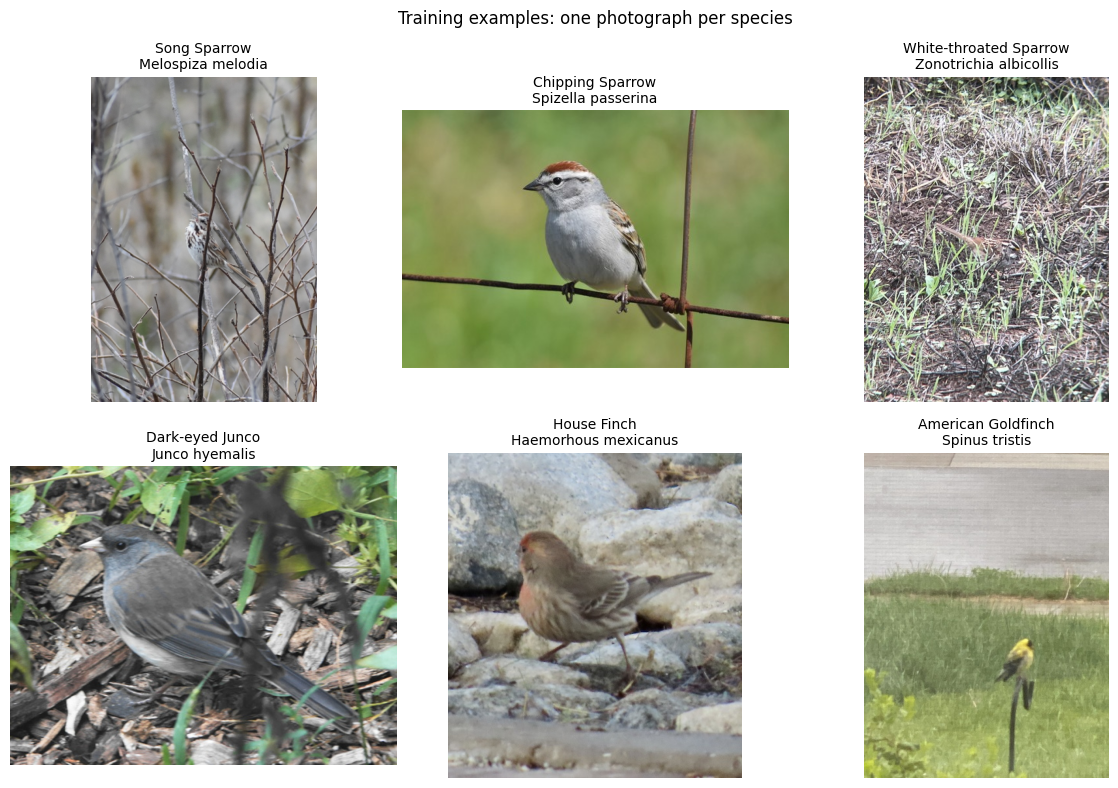

In [7]:
# One training photograph per species, before any model runs (training split only).
species_gallery=[next(r for r in splits["train"] if r["label"]==label) for label in CLASS_KEYS]
fig,axes=plt.subplots(2,3,figsize=(12,8))
for ax,record in zip(axes.ravel(),species_gallery,strict=True):
    ax.imshow(record["image"])
    ax.set_title(f"{record['common_name']}\n{record['scientific_name']}",fontsize=10)
    ax.axis("off")
fig.suptitle("Training examples: one photograph per species")
fig.tight_layout()
plt.show()

## 7. Six immutable model snapshots

Each model is staged from its exact Hugging Face revision and every manifest-listed file is verified by byte size and SHA-256 before loading.

The notebook loads weights from the verified local `model.safetensors`; no mutable `main` fallback is permitted.

> **Infrastructure.** This section supports reproducibility and execution. Run the associated setup code as written; understanding its implementation is not a learning objective for this notebook.

In [8]:
MANIFESTS = json.loads(
    '{"resnet50":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"resnet50-a1","modelId":"timm/resnet50.a1_in1k","revision":"767268603ca0cb0bfe326fa87277f19c419566ef","files":[{"path":"README.md","bytes":38435,"sha256":"1bf90a24888cff1da80e2e7b2e341fad1e4e448c19d92eb5bc08468393251721"},{"path":"config.json","bytes":756,"sha256":"ff00d936f02c3b5f9f80a169d651ed28f9b6dc9cb1fd0464f92da4761caaac50"},{"path":"model.safetensors","bytes":102469840,"sha256":"773525d5821de224f8f30c33377b7a795d7863e08522698200d3217d3f2a41bb"}],"totalBytes":102509031},"mobilenetv4":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"mobilenetv4-conv-small","modelId":"timm/mobilenetv4_conv_small.e2400_r224_in1k","revision":"331fb803779522b685cf942e15f914fb6741c1eb","files":[{"path":"README.md","bytes":13066,"sha256":"864651a7a9c0457023728da202cb1119abf3fa0872ded374ba736efde6454eb7"},{"path":"config.json","bytes":681,"sha256":"ecd20bcf1287aaa88129a736d188904d0b134c96e152b55b241be895657fe41a"},'
    '{"path":"model.safetensors","bytes":15223016,"sha256":"7a7102ec18f62bbfb555b6fe829bbb5af749516b84174926c29ffdfdfc03aec4"}],"totalBytes":15236763},"convnext":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"convnext-tiny-in12k","modelId":"timm/convnext_tiny.in12k_ft_in1k","revision":"aa096f03029c7f0ec052013f64c819b34f8ad790","files":[{"path":"README.md","bytes":16006,"sha256":"8f702c1663d3ccade5f47673d8924cc76f86880129b12a2958a9d094a8ec15cc"},{"path":"config.json","bytes":662,"sha256":"7333fa40fddb5a875bcf1bdcfe30916c925c27c6155834b900e2c4cc08dc4333"},'
    '{"path":"model.safetensors","bytes":114374272,"sha256":"a1aefa409b513cf209b085424eb3efffe4e4a9f511491bc2c12ea35209e6bb95"}],"totalBytes":114390940},"vit":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"vit-base-p16-224","modelId":"timm/vit_base_patch16_224.orig_in21k_ft_in1k","revision":"e0bd370de6799e8d1f47a911174ff4c3708e2323","files":[{"path":"README.md","bytes":3409,"sha256":"c5171b9aefd75755fac887b960b4d1df8cfa1f90568fc03ff5a5d5b74566664d"},{"path":"config.json","bytes":585,"sha256":"91aa54e1244ba735215d4ec117b62c1a00a9f4a744b0e0543b16b901eaf73784"},'
    '{"path":"model.safetensors","bytes":346284714,"sha256":"669b949ea91fd19217f200cee259780bde32210c1eb9a5af3859f0dd8346b2ec"}],"totalBytes":346288708},"swinv2":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"swinv2-tiny-window8-256-ms-in1k","modelId":"timm/swinv2_tiny_window8_256.ms_in1k","revision":"650d02aabf05e8adbd060a739ab39e39f53da639","files":[{"path":"config.json","bytes":632,"sha256":"75b22a3513f40757680f3f3b204adee1aa751f07eb630ee46200ed2c8a22c767"},{"path":"model.safetensors","bytes":114918618,"sha256":"c47f52b4556ff4436aa9502f5efbc93aac77fdab42d9d70dd845931757ff5d65"}],"totalBytes":114919250},"eva02":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"eva02-base-448","modelId":"timm/eva02_base_patch14_448.mim_in22k_ft_in22k_in1k","revision":"81063ecfe9c381a16a19d06f396d6c7011aa426a","files":[{"path":"README.md","bytes":5454,"sha256":"b347298844860ff288638f1d7c0baece71d9fe1cd796eefbfbf3f0780175ba07"},'
    '{"path":"config.json","bytes":653,"sha256":"d62e73f578eb363032000b6bfcc57764c6a5d10ee2562cbfe3f105d795e1c4be"},{"path":"model.safetensors","bytes":348492484,"sha256":"533937d6f9f8f8d4f50627ef0d00829a5015861a5b67e1c69c5a5e45b7dc2609"}],"totalBytes":348498591}}'
)

from huggingface_hub import hf_hub_download

MODEL_REGISTRY = {
    "resnet50":{
        "display":"ResNet-50",
        "timm_name":"resnet50.a1_in1k",
        "family":"Residual CNN","license":"Apache-2.0","declared_input":224,
    },
    "mobilenetv4":{
        "display":"MobileNetV4-Conv-Small",
        "timm_name":"mobilenetv4_conv_small.e2400_r224_in1k",
        "family":"Efficient/mobile CNN","license":"Apache-2.0","declared_input":224,
    },
    "convnext":{
        "display":"ConvNeXt-Tiny",
        "timm_name":"convnext_tiny.in12k_ft_in1k",
        "family":"Modern ConvNet","license":"Apache-2.0","declared_input":224,
    },
    "vit":{
        "display":"ViT-B/16",
        "timm_name":"vit_base_patch16_224.orig_in21k_ft_in1k",
        "family":"Global Vision Transformer","license":"Apache-2.0","declared_input":224,
    },
    "swinv2":{
        "display":"SwinV2-Tiny",
        "timm_name":"swinv2_tiny_window8_256.ms_in1k",
        "family":"Hierarchical windowed transformer","license":"MIT","declared_input":256,
    },
    "eva02":{
        "display":"EVA-02 Base 448",
        "timm_name":"eva02_base_patch14_448.mim_in22k_ft_in22k_in1k",
        "family":"Modern vision transformer","license":"MIT","declared_input":448,
    },
}
for key in MODEL_REGISTRY:
    MODEL_REGISTRY[key]["manifest"] = MANIFESTS[key]

SNAPSHOT_ROOT = Path("weights/model-snapshots")
SNAPSHOT_ROOT.mkdir(parents=True, exist_ok=True)

def sha256_file(path):
    h = hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1<<20), b""):
            h.update(chunk)
    return h.hexdigest()

def stage_snapshot(key):
    spec = MODEL_REGISTRY[key]
    manifest = spec["manifest"]
    root = SNAPSHOT_ROOT / manifest["modelKey"]
    root.mkdir(parents=True, exist_ok=True)
    (root/"dimer-base-manifest.json").write_text(json.dumps(manifest,indent=2),encoding="utf-8")
    t0 = time.perf_counter()
    for entry in manifest["files"]:
        path = root / entry["path"]
        if not path.is_file():
            path.parent.mkdir(parents=True, exist_ok=True)
            hf_hub_download(
                repo_id=manifest["modelId"],
                filename=entry["path"],
                revision=manifest["revision"],
                local_dir=str(root),
            )
    for entry in manifest["files"]:
        path = root / entry["path"]
        if path.stat().st_size != entry["bytes"]:
            raise RuntimeError(f"{key} {entry['path']}: size mismatch")
        if sha256_file(path) != entry["sha256"]:
            raise RuntimeError(f"{key} {entry['path']}: SHA-256 mismatch")
    return root, time.perf_counter()-t0

print("Registered models:")
for key,spec in MODEL_REGISTRY.items():
    print(f"  {key:<12} {spec['display']:<27} {spec['manifest']['modelId']} @ {spec['manifest']['revision'][:12]}…")

Registered models:
  resnet50     ResNet-50                   timm/resnet50.a1_in1k @ 767268603ca0…
  mobilenetv4  MobileNetV4-Conv-Small      timm/mobilenetv4_conv_small.e2400_r224_in1k @ 331fb8037795…
  convnext     ConvNeXt-Tiny               timm/convnext_tiny.in12k_ft_in1k @ aa096f03029c…
  vit          ViT-B/16                    timm/vit_base_patch16_224.orig_in21k_ft_in1k @ e0bd370de679…
  swinv2       SwinV2-Tiny                 timm/swinv2_tiny_window8_256.ms_in1k @ 650d02aabf05…
  eva02        EVA-02 Base 448             timm/eva02_base_patch14_448.mim_in22k_ft_in22k_in1k @ 81063ecfe9c3…


## 8. Common representation and probe methodology

For every checkpoint:

1. load the exact pretrained architecture;
2. freeze every backbone parameter;
3. apply its own native `timm` evaluation preprocessing;
4. call `forward_features` then `forward_head(..., pre_logits=True)`;
5. cache one pooled representation per image;
6. fit feature mean/std **on training features only**;
7. evaluate a 5-NN baseline;
8. train a zero-initialized `nn.Linear(feature_dim, 6)` probe;
9. select the probe epoch using validation cross-entropy;
10. evaluate test once;
11. export the probe as SafeTensors and prove fresh reload parity.

In [9]:
PROBABILITY_TOLERANCE=1e-4

def confusion_matrix_np(y_true,y_pred,n_classes=6):
    cm = np.zeros((n_classes,n_classes),dtype=int)
    for t,p in zip(y_true,y_pred,strict=True):
        cm[int(t),int(p)] += 1
    return cm

def class_metrics(cm,class_names=None):
    class_names=list(CLASS_KEYS if class_names is None else class_names)
    rows=[]
    for i in range(cm.shape[0]):
        tp=cm[i,i]; fp=cm[:,i].sum()-tp; fn=cm[i,:].sum()-tp
        support=cm[i,:].sum()
        precision=tp/(tp+fp) if tp+fp else 0.0
        recall=tp/(tp+fn) if tp+fn else 0.0
        f1=2*precision*recall/(precision+recall) if precision+recall else 0.0
        rows.append({"class_id":i,"class_label":class_names[i],"support":int(support),
                     "precision":float(precision),"recall":float(recall),"f1":float(f1)})
    return rows

def validate_scores(y_true,probs,n_classes,predicted_ids=None):
    """Reject scores that are not one valid distribution per row, before any metric is computed."""
    y_true=np.asarray(y_true)
    probs=np.asarray(probs,dtype=float)
    if probs.ndim!=2 or probs.shape!=(len(y_true),n_classes):
        raise ValueError(f"scores must have shape ({len(y_true)}, {n_classes}); got {probs.shape}")
    if not np.isfinite(probs).all():
        raise ValueError("scores contain missing or non-finite values")
    if (probs<-PROBABILITY_TOLERANCE).any() or (probs>1+PROBABILITY_TOLERANCE).any():
        raise ValueError("scores must lie between 0 and 1")
    if (np.abs(probs.sum(axis=1)-1.0)>PROBABILITY_TOLERANCE).any():
        raise ValueError("each row of scores must sum to 1")
    for name,ids in (("true",y_true),("predicted",predicted_ids)):
        if ids is None:
            continue
        ids=np.asarray(ids)
        if ids.shape!=(len(y_true),) or not np.issubdtype(ids.dtype,np.integer) or ids.min(initial=0)<0 or ids.max(initial=0)>=n_classes:
            raise ValueError(f"{name} class ids must be {len(y_true)} integers in 0..{n_classes-1}")
    return probs

def classification_metrics(y_true,probs,class_names=None,predicted_ids=None):
    """Score one model. `predicted_ids` is the model's own decision; without it, the highest score is used.

    5-NN passes its decision explicitly: vote fractions can tie, and the tie is decided by summed cosine
    similarity, which argmax over the fractions would ignore.
    """
    class_names=list(CLASS_KEYS if class_names is None else class_names)
    n_classes=len(class_names)
    y_true=np.asarray(y_true,dtype=int)
    probs=validate_scores(y_true,probs,n_classes,predicted_ids)
    pred=probs.argmax(axis=1) if predicted_ids is None else np.asarray(predicted_ids,dtype=int)
    cm=confusion_matrix_np(y_true,pred,n_classes)
    per=class_metrics(cm,class_names)
    top3=np.argsort(-probs,axis=1,kind="stable")[:,:min(3,n_classes)]
    log_loss=float(-np.mean(np.log(np.maximum(probs[np.arange(len(y_true)),y_true],1e-12))))
    return {
        "accuracy":float(np.mean(pred==y_true)),
        "macro_f1":float(np.mean([r["f1"] for r in per])),
        "top3_accuracy":float(np.mean([y_true[i] in top3[i] for i in range(len(y_true))])),
        "log_loss":log_loss,
        "confusion_matrix":cm,
        "per_class":per,
        "predicted_ids":pred,
        "n_images":int(len(y_true)),
    }

def standardize_from_train(train_x,*others):
    mean=train_x.mean(axis=0,keepdims=True).astype(np.float32)
    std=train_x.std(axis=0,keepdims=True).astype(np.float32)
    std=np.maximum(std,1e-6)
    return mean,std,[(x-mean)/std for x in (train_x,*others)]

def knn_predict(train_x,train_y,test_x,k=5,n_classes=None):
    """Cosine k-NN. Decision: most votes, then larger summed cosine similarity, then lower class id.

    Returns the decided class ids and the vote fractions (the scores). The fractions are left as they are;
    they are not adjusted to encode the tie decision.
    """
    n_classes=len(CLASS_KEYS) if n_classes is None else n_classes
    train_n=train_x/np.maximum(np.linalg.norm(train_x,axis=1,keepdims=True),1e-12)
    test_n=test_x/np.maximum(np.linalg.norm(test_x,axis=1,keepdims=True),1e-12)
    sims=test_n@train_n.T
    predictions=[]
    probs=[]
    for row in sims:
        idx=np.argsort(-row,kind="stable")[:min(k,len(train_y))]
        vote_counts=np.zeros(n_classes,dtype=int)
        sim_sums=np.zeros(n_classes,dtype=float)
        for j in idx:
            c=int(train_y[j]); vote_counts[c]+=1; sim_sums[c]+=float(row[j])
        order=sorted(range(n_classes), key=lambda c:(-vote_counts[c],-sim_sums[c],c))
        predictions.append(order[0])
        p=vote_counts.astype(float)
        p=p/p.sum()
        probs.append(p)
    return np.array(predictions,dtype=np.int64),np.array(probs,dtype=np.float32)

def fit_probe(train_x,train_y,val_x,val_y,test_x=None,
              epochs=PROBE_EPOCHS,lr=PROBE_LR,weight_decay=PROBE_WEIGHT_DECAY,n_classes=None):
    """Train and select a linear probe on training and validation data only.

    `test_x` is optional: when it is omitted, nothing about the test split is read or scored.
    """
    n_classes=len(CLASS_KEYS) if n_classes is None else n_classes
    others=(val_x,) if test_x is None else (val_x,test_x)
    mean,std,standardized=standardize_from_train(train_x,*others)
    tr,va=standardized[0],standardized[1]
    xtr=torch.from_numpy(tr.astype(np.float32))
    ytr=torch.from_numpy(np.asarray(train_y,dtype=np.int64))
    xva=torch.from_numpy(va.astype(np.float32))
    yva=torch.from_numpy(np.asarray(val_y,dtype=np.int64))

    layer=torch.nn.Linear(tr.shape[1],n_classes)
    torch.nn.init.zeros_(layer.weight); torch.nn.init.zeros_(layer.bias)
    opt=torch.optim.AdamW(layer.parameters(),lr=lr,weight_decay=weight_decay)

    best_loss=float("inf"); best_epoch=None; best_state=None
    start=time.perf_counter()
    for epoch in range(1,epochs+1):
        layer.train()
        opt.zero_grad(set_to_none=True)
        loss=F.cross_entropy(layer(xtr),ytr)
        loss.backward()
        opt.step()
        layer.eval()
        with torch.inference_mode():
            val_loss=float(F.cross_entropy(layer(xva),yva))
        if val_loss < best_loss - 1e-12:
            best_loss=val_loss; best_epoch=epoch
            best_state={k:v.detach().clone() for k,v in layer.state_dict().items()}
    training_seconds=time.perf_counter()-start
    layer.load_state_dict(best_state)
    layer.eval()
    with torch.inference_mode():
        val_probs=torch.softmax(layer(xva),dim=1).numpy().astype(np.float32)
        test_probs=(
            None if test_x is None
            else torch.softmax(layer(torch.from_numpy(standardized[2].astype(np.float32))),dim=1).numpy().astype(np.float32)
        )
    return {
        "layer":layer,"mean":mean.squeeze(0),"std":std.squeeze(0),
        "best_epoch":best_epoch,"validation_loss":best_loss,
        "validation_accuracy":float(np.mean(val_probs.argmax(1)==np.asarray(val_y))),
        # Honesty flags: a first-epoch pick means the probe barely trained; a cap pick means validation loss was
        # still falling (common when the 24 validation images are already separable).
        "selected_at_first_epoch":best_epoch==1,"selected_at_epoch_cap":best_epoch==epochs,
        "test_probs":test_probs,"val_probs":val_probs,
        "training_seconds":training_seconds,
    }

def representation_geometry(test_x,test_y):
    x=test_x/np.maximum(np.linalg.norm(test_x,axis=1,keepdims=True),1e-12)
    sim=x@x.T
    same=[]; diff=[]
    for i in range(len(x)):
        for j in range(i+1,len(x)):
            (same if test_y[i]==test_y[j] else diff).append(float(sim[i,j]))
    return {
        "mean_same_class_cosine":float(np.mean(same)),
        "mean_different_class_cosine":float(np.mean(diff)),
        "separability_gap":float(np.mean(same)-np.mean(diff)),
    }

def load_probe_artifact(probe_dir,spec):
    """Rebuild a probe from its artifact directory alone: manifest.json + probe.safetensors.

    Nothing from the training session is used. The manifest's base identity, file digest, class order,
    dimensions and normalisation statistics are all checked before the probe is returned.
    """
    probe_dir=Path(probe_dir)
    manifest_path=probe_dir/"manifest.json"
    if not manifest_path.is_file():
        raise RuntimeError(f"{probe_dir}: manifest.json is missing")
    manifest=json.loads(manifest_path.read_text(encoding="utf-8"))
    if manifest.get("format")!="dimer_linear_probe" or manifest.get("format_version")!=1:
        raise RuntimeError(f"{probe_dir}: not a dimer_linear_probe v1 artifact")
    base_sha=next(x["sha256"] for x in spec["manifest"]["files"] if x["path"]=="model.safetensors")
    if manifest["base_model_id"]!=spec["manifest"]["modelId"] or manifest["base_model_revision"]!=spec["manifest"]["revision"]:
        raise RuntimeError("Probe/base model identity mismatch")
    if manifest["base_weight_sha256"]!=base_sha:
        raise RuntimeError("Probe/base weight digest mismatch")
    path=probe_dir/"probe.safetensors"
    if not path.is_file():
        raise RuntimeError(f"{probe_dir}: probe.safetensors is missing")
    if path.stat().st_size!=manifest["probe_file"]["bytes"] or sha256_file(path)!=manifest["probe_file"]["sha256"]:
        raise RuntimeError("Probe file does not match the digest recorded in its manifest")
    class_order=list(manifest["class_order"])
    if len(class_order)<2 or len(set(class_order))!=len(class_order):
        raise RuntimeError("Probe class_order must list at least two distinct classes")
    state=load_file(str(path),device="cpu")
    dim=int(manifest["feature_dim"])
    n_classes=len(class_order)
    expected={"classifier.weight":(n_classes,dim),"classifier.bias":(n_classes,),"feature_mean":(dim,),"feature_std":(dim,)}
    for name,shape in expected.items():
        if name not in state or tuple(state[name].shape)!=shape:
            raise RuntimeError(f"Probe tensor {name} must have shape {shape}")
    if not (torch.isfinite(state["feature_std"]).all() and (state["feature_std"]>0).all() and torch.isfinite(state["feature_mean"]).all()):
        raise RuntimeError("Probe normalisation statistics are invalid")
    layer=torch.nn.Linear(dim,n_classes)
    layer.load_state_dict({"weight":state["classifier.weight"],"bias":state["classifier.bias"]},strict=True)
    layer.eval()
    return {"manifest":manifest,"layer":layer,"mean":state["feature_mean"].numpy(),
            "std":state["feature_std"].numpy(),"class_order":class_order,"feature_dim":dim}

def probe_predict(probe,features):
    if features.shape[1]!=probe["feature_dim"]:
        raise RuntimeError("Probe feature dimension mismatch")
    x=torch.from_numpy(((features-probe["mean"])/probe["std"]).astype(np.float32))
    with torch.inference_mode():
        probs=torch.softmax(probe["layer"](x),dim=1).numpy()
    labels=[probe["class_order"][int(i)] for i in probs.argmax(1)]
    return probs,labels

## 9. Majority baseline

The dataset is exactly balanced across six species, so a deterministic majority-class classifier has expected accuracy `1/6 ≈ 16.67%`.

> **Before you run it:** predict whether this simple reference will be easy or difficult for the learned model(s) to beat. Record the baseline before interpreting the more complex result.

In [10]:
majority_accuracy=1.0/len(CLASS_KEYS)
print({"majority_accuracy":majority_accuracy})

{'majority_accuracy': 0.16666666666666666}


## 10. Sequential backbone workflow

The next cell executes the same procedure for all six checkpoints.

No backbone gradients are enabled. Each probe is saved as a SafeTensors file plus `manifest.json`, then rebuilt from those two files alone and checked: the manifest's base model, file digest, class order and dimensions must be valid, and the rebuilt probe must reproduce the same probabilities **and the same species labels**. Model-specific differences in preprocessing are preserved, including 224×224, 256×256 and 448×448 native inputs.

In [11]:
from timm.data import resolve_model_data_config, create_transform

OUT_ROOT=Path(OUTPUT_DIR)
(OUT_ROOT/"features").mkdir(parents=True,exist_ok=True)
(OUT_ROOT/"probes").mkdir(parents=True,exist_ok=True)
(OUT_ROOT/"pca").mkdir(parents=True,exist_ok=True)

def load_backbone(key):
    spec=MODEL_REGISTRY[key]
    root,verify_seconds=stage_snapshot(key)
    t0=time.perf_counter()
    model=timm.create_model(spec["timm_name"],pretrained=False)
    state=load_file(str(root/"model.safetensors"),device="cpu")
    # Some checkpoints (SwinV2) carry buffers that timm now rebuilds at construction and does not persist
    # (attention masks). Drop such an entry only when it is bit-identical to the rebuilt buffer; everything
    # else still goes through a strict load.
    persistent=set(model.state_dict())
    rebuilt={n:b for n,b in model.named_buffers() if n not in persistent}
    for name in [k for k in state if k in rebuilt]:
        if not torch.equal(state[name].to(rebuilt[name].dtype),rebuilt[name].cpu()):
            raise RuntimeError(f"{key}: checkpoint buffer {name} differs from the one timm rebuilds")
        del state[name]
    result=model.load_state_dict(state,strict=True)
    if result.missing_keys or result.unexpected_keys:
        raise RuntimeError(f"{key}: state mismatch {result}")
    del state
    model=model.to(DEVICE).eval()
    for p in model.parameters():
        p.requires_grad_(False)
    if sum(p.requires_grad for p in model.parameters()) != 0:
        raise RuntimeError(f"{key}: backbone is not fully frozen")
    data_config=resolve_model_data_config(model)
    transform=create_transform(**data_config,is_training=False)
    input_size=int(data_config["input_size"][-1])
    if input_size != spec["declared_input"]:
        raise RuntimeError(f"{key}: resolved input {input_size} != declared {spec['declared_input']}")
    return model,transform,data_config,root,verify_seconds,time.perf_counter()-t0

def extract_features(model,transform,part):
    feats=[]; ids=[]; labels=[]; source_ids=[]
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    t0=time.perf_counter()
    for start in range(0,len(part),FEATURE_BATCH_SIZE):
        batch=part[start:start+FEATURE_BATCH_SIZE]
        tensor=torch.stack([transform(r["image"]) for r in batch]).to(DEVICE)
        with torch.inference_mode():
            f=model.forward_features(tensor)
            z=model.forward_head(f,pre_logits=True)
        if z.ndim != 2 or z.shape[0] != len(batch):
            raise RuntimeError(f"Unexpected pre-logit shape {tuple(z.shape)}")
        if not torch.isfinite(z).all():
            raise RuntimeError("Non-finite pre-logit features")
        feats.append(z.float().cpu().numpy())
        ids.extend(r["id"] for r in batch)
        source_ids.extend(r["source_id"] for r in batch)
        labels.extend(r["label_id"] for r in batch)
    elapsed=time.perf_counter()-t0
    peak=torch.cuda.max_memory_allocated() if torch.cuda.is_available() else None
    return {
        "features":np.vstack(feats).astype(np.float32),
        "ids":np.array(ids,dtype=str),
        "source_ids":np.array(source_ids,dtype=str),
        "labels":np.array(labels,dtype=np.int64),
        "seconds":elapsed,"peak_gpu_memory_bytes":peak,
    }

def latency_measure(model,transform,image):
    """Median warmed backbone feature-forward time for one image, with CUDA synchronisation.
    It excludes image preprocessing, host-to-device transfer and the probe: it is not full image-to-label latency."""
    x=transform(image).unsqueeze(0).to(DEVICE)
    with torch.inference_mode():
        for _ in range(2):
            _=model.forward_head(model.forward_features(x),pre_logits=True)
    values=[]
    for _ in range(LATENCY_REPEATS):
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0=time.perf_counter()
        with torch.inference_mode():
            _=model.forward_head(model.forward_features(x),pre_logits=True)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        values.append(time.perf_counter()-t0)
    return float(np.median(values)),values

def save_probe_artifact(key,spec,probe,feature_dim,train_digest,val_digest):
    root=OUT_ROOT/"probes"/key
    root.mkdir(parents=True,exist_ok=True)
    path=root/"probe.safetensors"
    tensors={
        "classifier.weight":probe["layer"].weight.detach().cpu().contiguous(),
        "classifier.bias":probe["layer"].bias.detach().cpu().contiguous(),
        "feature_mean":torch.from_numpy(probe["mean"]).contiguous(),
        "feature_std":torch.from_numpy(probe["std"]).contiguous(),
    }
    save_file(tensors,str(path))
    base_sha=next(x["sha256"] for x in spec["manifest"]["files"] if x["path"]=="model.safetensors")
    manifest={
        "format":"dimer_linear_probe",
        "format_version":1,
        "base_model_id":spec["manifest"]["modelId"],
        "base_model_revision":spec["manifest"]["revision"],
        "base_weight_sha256":base_sha,
        "feature_interface":"pre_logits",
        "feature_dim":feature_dim,
        "class_order":CLASS_KEYS,
        "probe":{"best_epoch":probe["best_epoch"],"optimizer":"AdamW","learning_rate":PROBE_LR,
                 "weight_decay":PROBE_WEIGHT_DECAY},
        "training_sample_digest":train_digest,
        "validation_sample_digest":val_digest,
        "probe_file":{"bytes":path.stat().st_size,"sha256":sha256_file(path)},
    }
    (root/"manifest.json").write_text(json.dumps(manifest,indent=2),encoding="utf-8")
    return path,manifest

def reload_probe_verify(probe_dir,spec,test_x,reference_probs,expected_class_order):
    """Fresh-boundary check: rebuild the probe from its artifact directory only, then compare the numbers
    and the class labels they decode to with the in-session probe."""
    probe=load_probe_artifact(probe_dir,spec)
    if probe["class_order"]!=list(expected_class_order):
        raise RuntimeError("Probe class_order differs from the classes it was trained on")
    probs,labels=probe_predict(probe,test_x)
    reference_labels=[expected_class_order[int(i)] for i in np.asarray(reference_probs).argmax(1)]
    diff=float(np.max(np.abs(probs-reference_probs)))
    if diff > 1e-6 or labels!=reference_labels:
        raise RuntimeError(f"Probe reload parity failed: max diff {diff}")
    return diff

def split_digest(part):
    payload=[[r["source_id"],r["label_id"],r["pixel_sha256"]] for r in part]
    return hashlib.sha256(json.dumps(payload,separators=(",",":")).encode()).hexdigest()

ALL_RESULTS={}
ALL_FEATURES={}

fixed_latency_image=splits["test"][0]["image"]

for key,spec in MODEL_REGISTRY.items():
    print(f"\n=== {spec['display']} ===")
    model,transform,data_cfg,snapshot_dir,verify_s,load_s=load_backbone(key)
    parameter_count=sum(p.numel() for p in model.parameters())
    # Pre-logit width: timm's head_hidden_size (MobileNetV4 adds a 960->1280 head conv, so num_features is not it).
    feature_dim=int(getattr(model,"head_hidden_size",model.num_features))

    median_latency,latency_values=latency_measure(model,transform,fixed_latency_image)

    tr=extract_features(model,transform,splits["train"])
    va=extract_features(model,transform,splits["validation"])
    te=extract_features(model,transform,splits["test"])

    if tr["features"].shape[1] != feature_dim or va["features"].shape[1] != feature_dim or te["features"].shape[1] != feature_dim:
        raise RuntimeError(f"{key}: feature dimension does not match the pre-logit width {feature_dim}")

    mean,std,(tr_std,va_std,te_std)=standardize_from_train(tr["features"],va["features"],te["features"])
    knn_pred,knn_probs=knn_predict(tr_std,tr["labels"],te_std,KNN_K)
    # Score the k-NN decision itself (vote count, then summed cosine similarity), not argmax of the vote fractions.
    knn_metrics=classification_metrics(te["labels"],knn_probs,predicted_ids=knn_pred)

    probe=fit_probe(tr["features"],tr["labels"],va["features"],va["labels"],te["features"])
    probe_metrics=classification_metrics(te["labels"],probe["test_probs"])

    geom=representation_geometry(te["features"],te["labels"])

    feature_path=OUT_ROOT/"features"/f"{key}.npz"
    np.savez_compressed(
        feature_path,
        train_ids=tr["ids"],train_source_ids=tr["source_ids"],train_labels=tr["labels"],train_features=tr["features"],
        validation_ids=va["ids"],validation_source_ids=va["source_ids"],validation_labels=va["labels"],validation_features=va["features"],
        test_ids=te["ids"],test_source_ids=te["source_ids"],test_labels=te["labels"],test_features=te["features"],
    )

    probe_path,probe_manifest=save_probe_artifact(
        key,spec,probe,feature_dim,split_digest(splits["train"]),split_digest(splits["validation"])
    )
    reload_diff=reload_probe_verify(probe_path.parent,spec,te["features"],probe["test_probs"],CLASS_KEYS)

    input_size=int(data_cfg["input_size"][-1])
    peak=max(x for x in [tr["peak_gpu_memory_bytes"],va["peak_gpu_memory_bytes"],te["peak_gpu_memory_bytes"]] if x is not None) if torch.cuda.is_available() else None

    ALL_FEATURES[key]={"train":tr,"validation":va,"test":te}
    ALL_RESULTS[key]={
        "model":spec["display"],"family":spec["family"],"feature_dim":feature_dim,
        "parameter_count":parameter_count,"weight_bytes":next(x["bytes"] for x in spec["manifest"]["files"] if x["path"]=="model.safetensors"),
        "native_input_size":input_size,"snapshot_verify_seconds":verify_s,"model_load_seconds":load_s,
        "median_single_image_latency_s":median_latency,"latency_values":latency_values,
        "feature_extraction_seconds":tr["seconds"]+va["seconds"]+te["seconds"],
        "probe_training_seconds":probe["training_seconds"],"peak_gpu_memory_bytes":peak,
        "knn_metrics":knn_metrics,"probe_metrics":probe_metrics,
        "best_epoch":probe["best_epoch"],"validation_log_loss":probe["validation_loss"],
        "selected_at_first_epoch":probe["selected_at_first_epoch"],"selected_at_epoch_cap":probe["selected_at_epoch_cap"],
        "geometry":geom,"probe_reload_max_abs_probability_diff":reload_diff,
        "test_probs":probe["test_probs"],"test_pred":probe_metrics["predicted_ids"],"knn_pred":knn_pred,
        "probe_manifest":probe_manifest,
    }

    print({
        "feature_dim":feature_dim,
        "5nn_accuracy":knn_metrics["accuracy"],
        "probe_accuracy":probe_metrics["accuracy"],
        "macro_f1":probe_metrics["macro_f1"],
        "best_epoch":probe["best_epoch"],
        "backbone_forward_latency_ms":median_latency*1000,
    })

    del model,probe
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


=== ResNet-50 ===
{'feature_dim': 2048, '5nn_accuracy': 0.5, 'probe_accuracy': 0.5, 'macro_f1': 0.4668915879442195, 'best_epoch': 35, 'backbone_forward_latency_ms': 7.45728349997421}

=== MobileNetV4-Conv-Small ===
{'feature_dim': 1280, '5nn_accuracy': 0.4166666666666667, 'probe_accuracy': 0.5, 'macro_f1': 0.5048534798534798, 'best_epoch': 46, 'backbone_forward_latency_ms': 4.4711534999635205}

=== ConvNeXt-Tiny ===
{'feature_dim': 768, '5nn_accuracy': 0.7291666666666666, 'probe_accuracy': 0.7291666666666666, 'macro_f1': 0.7271929824561404, 'best_epoch': 1000, 'backbone_forward_latency_ms': 9.380831500010345}

=== ViT-B/16 ===
{'feature_dim': 768, '5nn_accuracy': 0.7916666666666666, 'probe_accuracy': 0.7916666666666666, 'macro_f1': 0.7885477582846003, 'best_epoch': 1000, 'backbone_forward_latency_ms': 13.18040099999962}

=== SwinV2-Tiny ===
{'feature_dim': 768, '5nn_accuracy': 0.5833333333333334, 'probe_accuracy': 0.6666666666666666, 'macro_f1': 0.6435947265668629, 'best_epoch': 34, '

## 11. Main comparison

The table below compares representation-only 5-NN performance with the learned linear probe.

No automatic overall winner is declared.

**How to read the columns.**

| Column | Meaning | Better |
|---|---|---|
| Accuracy | share of the 48 test photos whose predicted species is correct; one photo is about 2.1 percentage points | higher |
| Macro F1 | the F1 score (balance of precision and recall) computed per species, then averaged, so every species counts equally | higher |
| Top-3 | share of photos whose true species is among the three highest scores | higher |
| Log-loss | average of −log(score given to the true species); it punishes confident mistakes | lower |

*Worked contrast.* Two models both get 47 of 48 photos right (accuracy 0.979). On the one mistake, model A gives the true species a score of 0.40 and model B gives it 0.01. Their accuracies are identical, but B's log-loss is higher, because −log(0.01) ≈ 4.6 while −log(0.40) ≈ 0.9: B was confidently wrong.

The 5-NN column uses the majority vote of the five nearest training photos; ties between species are decided by the larger summed cosine similarity, then by the lower class number. Its scores are vote fractions, so its log-loss is not comparable with the probe's.

> **What to notice.** Compare the learned-model result with the baseline/reference first, then use the secondary diagnostics to explain the behavior. Do not infer a universal model ranking from one tutorial sample and configuration.

In [12]:
print(f"{'Model':<27} {'Feat':>6} {'5NN Acc':>9} {'Probe Acc':>10} {'Macro F1':>9} {'Top-3':>8} {'LogLoss':>8}")
print("-"*90)
for key,spec in MODEL_REGISTRY.items():
    r=ALL_RESULTS[key]
    k=r["knn_metrics"]; p=r["probe_metrics"]
    print(
        f"{r['model']:<27} {r['feature_dim']:>6} {k['accuracy']:>9.3f} "
        f"{p['accuracy']:>10.3f} {p['macro_f1']:>9.3f} {p['top3_accuracy']:>8.3f} {p['log_loss']:>8.3f}"
    )

Model                         Feat   5NN Acc  Probe Acc  Macro F1    Top-3  LogLoss
------------------------------------------------------------------------------------------
ResNet-50                     2048     0.500      0.500     0.467    0.854    1.754
MobileNetV4-Conv-Small        1280     0.417      0.500     0.505    0.812    1.448
ConvNeXt-Tiny                  768     0.729      0.729     0.727    0.917    1.133
ViT-B/16                       768     0.792      0.792     0.789    0.958    0.897
SwinV2-Tiny                    768     0.583      0.667     0.644    0.875    1.055
EVA-02 Base 448                768     0.833      0.896     0.896    0.979    0.367


## 12. Prediction exercise

Before interpreting resource tradeoffs, consider:

1. Which checkpoint produced the strongest frozen representation?
2. Did the largest checkpoint also produce the highest probe accuracy?
3. Did the highest-resolution EVA-02 representation justify its compute cost?
4. Which model gave the best result under a small weight/latency envelope?
5. Did 5-NN and the learned linear probe rank the representations similarly?

Use the measured table rather than assumptions about architecture families.

In [13]:
for key,r in ALL_RESULTS.items():
    print({
        "model":r["model"],
        "probe_accuracy":r["probe_metrics"]["accuracy"],
        "weight_mb":r["weight_bytes"]/1e6,
        "median_latency_ms":r["median_single_image_latency_s"]*1000,
        "input_size":r["native_input_size"],
    })

{'model': 'ResNet-50', 'probe_accuracy': 0.5, 'weight_mb': 102.46984, 'median_latency_ms': 7.45728349997421, 'input_size': 224}
{'model': 'MobileNetV4-Conv-Small', 'probe_accuracy': 0.5, 'weight_mb': 15.223016, 'median_latency_ms': 4.4711534999635205, 'input_size': 224}
{'model': 'ConvNeXt-Tiny', 'probe_accuracy': 0.7291666666666666, 'weight_mb': 114.374272, 'median_latency_ms': 9.380831500010345, 'input_size': 224}
{'model': 'ViT-B/16', 'probe_accuracy': 0.7916666666666666, 'weight_mb': 346.284714, 'median_latency_ms': 13.18040099999962, 'input_size': 224}
{'model': 'SwinV2-Tiny', 'probe_accuracy': 0.6666666666666666, 'weight_mb': 114.918618, 'median_latency_ms': 14.696819500017, 'input_size': 256}
{'model': 'EVA-02 Base 448', 'probe_accuracy': 0.8958333333333334, 'weight_mb': 348.492484, 'median_latency_ms': 73.55299650001257, 'input_size': 448}


## 13. Per-species confusion and cross-model consensus

A single aggregate accuracy can hide species-specific behavior. The next cell shows, in order:

1. how many test photos all six probes got right, most got right, split on, or mostly got wrong;
2. each probe's **recall** per species (the share of that species' test photos it recognised);
3. each probe's **confusion matrix**: rows are the true species, columns the predicted one, so an off-diagonal number is a specific mix-up;
4. up to three real test photos the probes got wrong or disagreed on, chosen by a fixed rule (hardest category first, then image id), with every model's prediction.

If every probe gets every photo right, the cell says so instead of inventing an example.

> **Checkpoint.** Find one species pair that is confused by more than one model. Is it confused in both directions? Look at the gallery photo: what makes it hard?

Test photos by how many of the six probes got them right: {'split': 8, 'unanimous_correct': 14, 'majority_correct': 19, 'shared_hard_case': 7}

Recall by species          ResNet-50 MobileNetV4 ConvNeXt-Ti    ViT-B/16 SwinV2-Tiny EVA-02 Base
Song Sparrow                    0.25        0.25        0.38        0.50        0.50        0.75
Chipping Sparrow                0.50        0.38        0.62        0.88        0.25        1.00
White-throated Sparrow          0.25        0.25        0.88        0.88        0.88        1.00
Dark-eyed Junco                 0.25        0.75        0.62        0.75        0.38        0.75
House Finch                     0.75        0.50        0.88        0.88        1.00        0.88
American Goldfinch              1.00        0.88        1.00        0.88        1.00        1.00


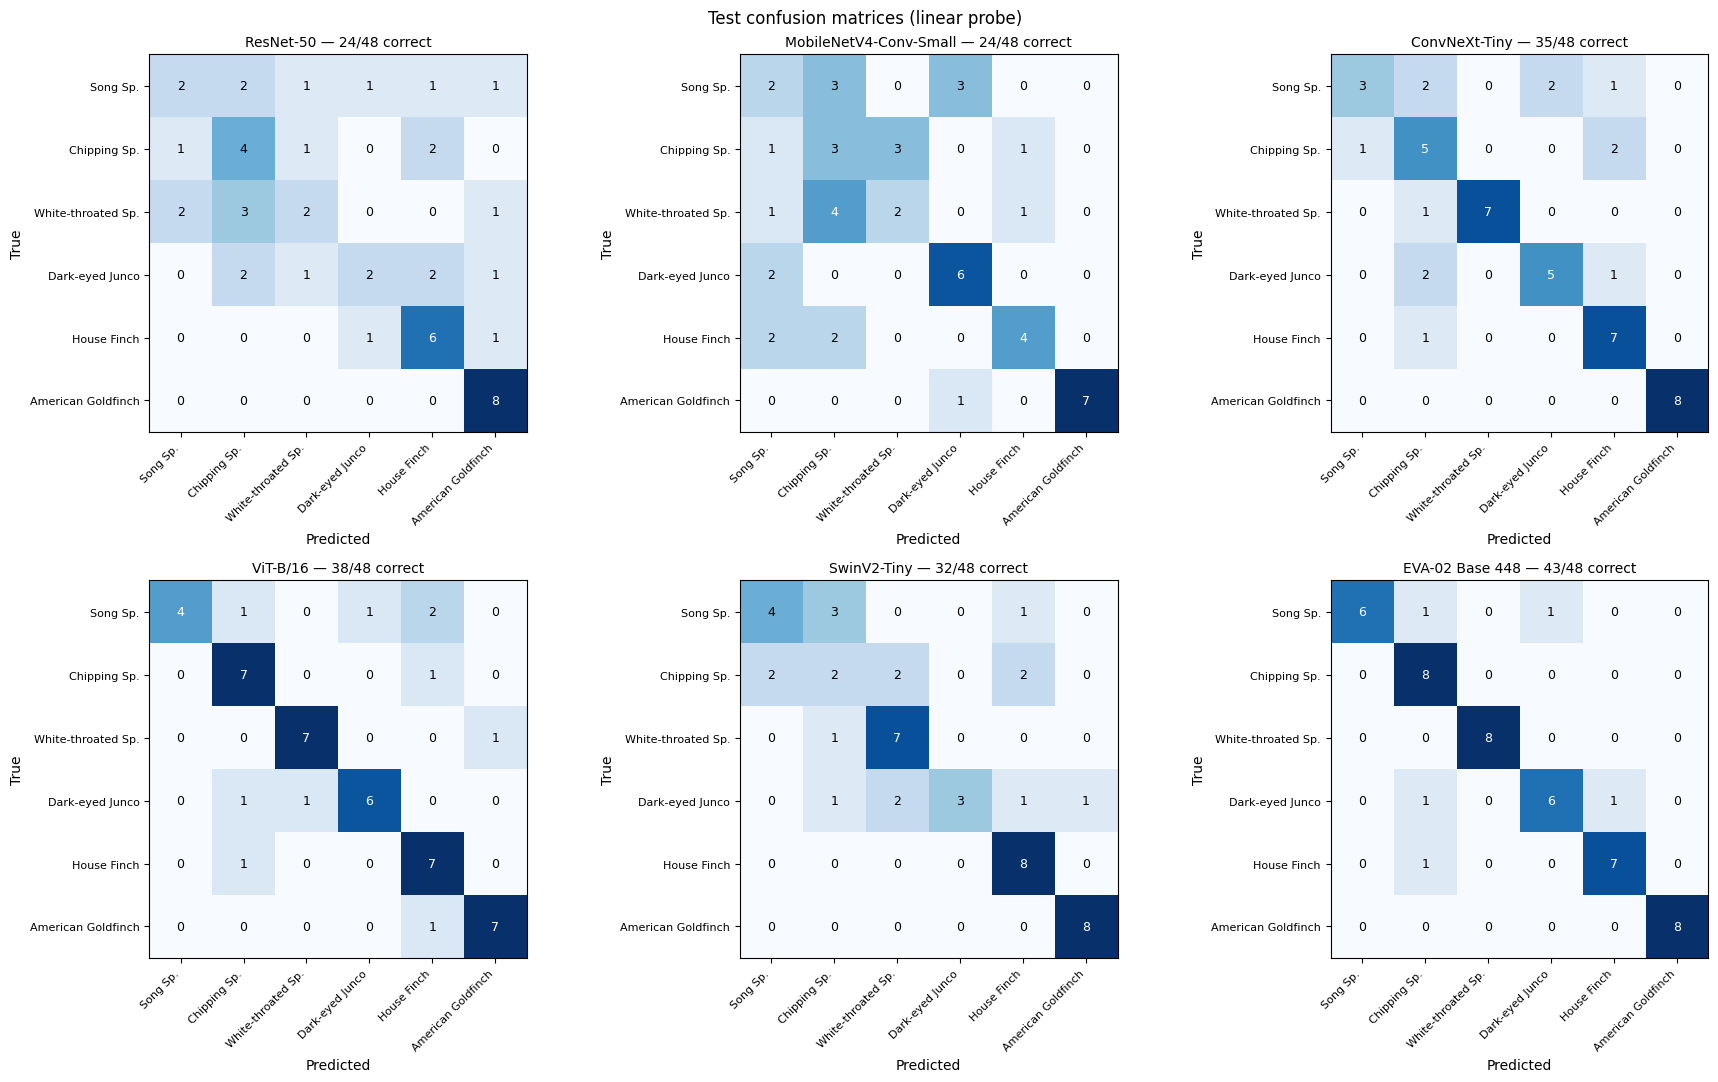

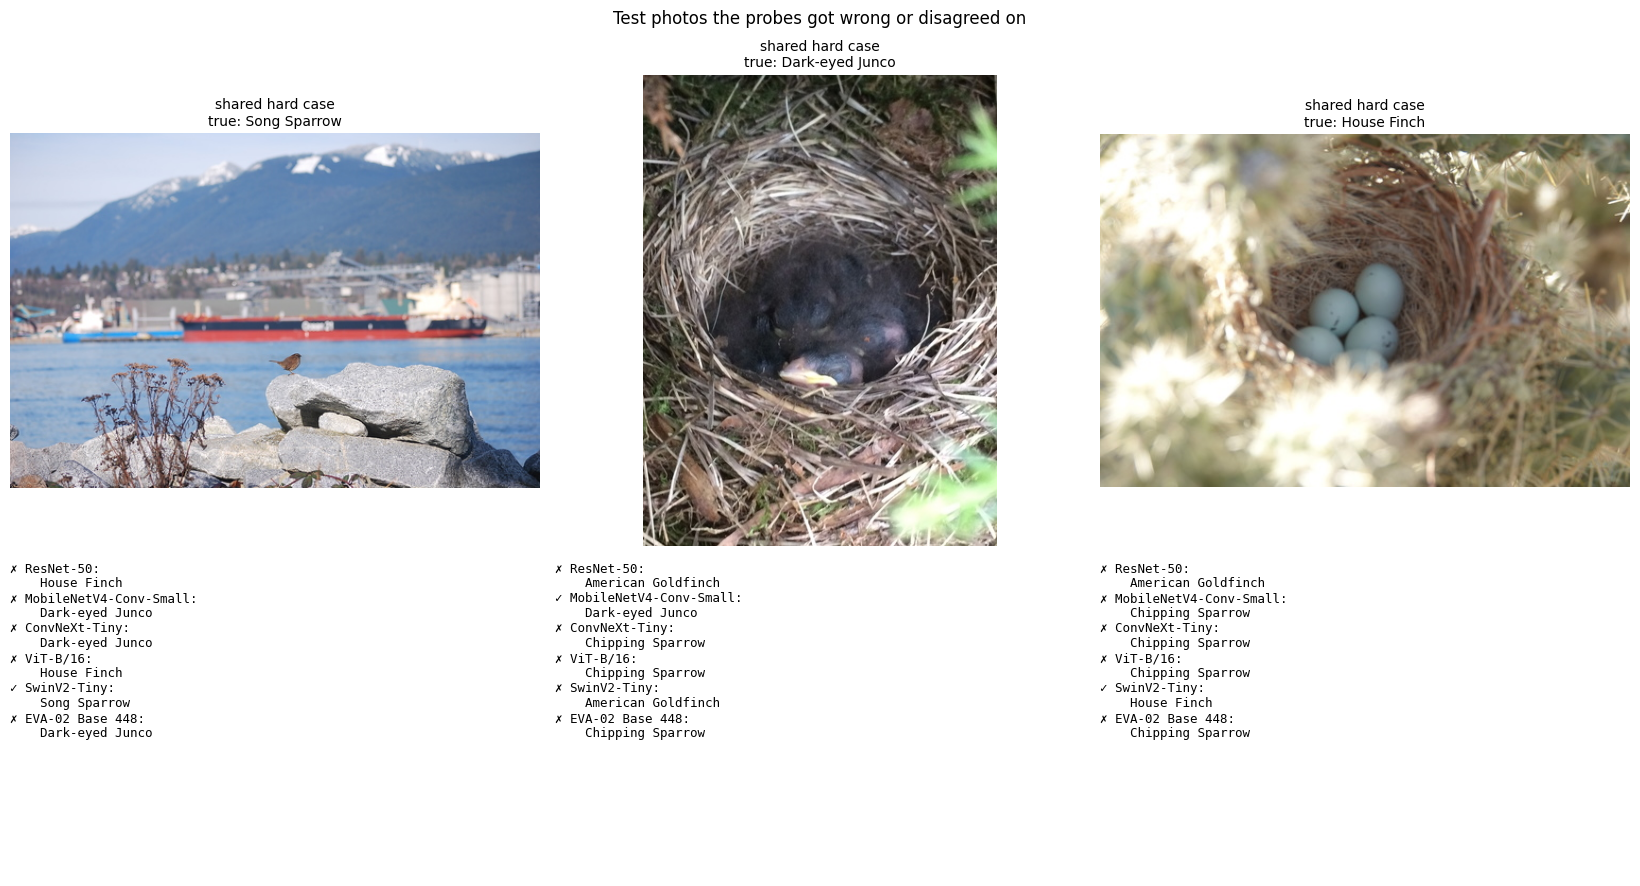

In [14]:
import textwrap

test_records=splits["test"]
prediction_rows=[]
for key,r in ALL_RESULTS.items():
    probs=r["test_probs"]
    for i,record in enumerate(test_records):
        order=np.argsort(-probs[i],kind="stable")
        prediction_rows.append({
            "image_id":record["id"],"source_id":record["source_id"],"gold_label":record["label"],
            "model":r["model"],"predicted_label":CLASS_KEYS[int(order[0])],
            "correct":bool(int(order[0])==record["label_id"]),
            "top1_score":float(probs[i,order[0]]),
            "top2_label":CLASS_KEYS[int(order[1])],"top2_score":float(probs[i,order[1]]),
            "margin":float(probs[i,order[0]]-probs[i,order[1]]),
            # Every class score, so log-loss and top-3 can be recomputed from this file alone.
            **{f"score_{label}":float(probs[i,c]) for c,label in enumerate(CLASS_KEYS)},
        })

consensus_rows=[]
for i,record in enumerate(test_records):
    preds=[int(ALL_RESULTS[k]["test_pred"][i]) for k in MODEL_REGISTRY]
    correct=sum(p==record["label_id"] for p in preds)
    unique=len(set(preds))
    if correct==6: category="unanimous_correct"
    elif correct>=4: category="majority_correct"
    elif correct>=2: category="split"
    else: category="shared_hard_case"
    consensus_rows.append({
        "image_id":record["id"],"source_id":record["source_id"],"gold_label":record["label"],
        "models_correct":correct,"unique_predictions":unique,"difficulty_category":category,
    })

print("Test photos by how many of the six probes got them right:",
      dict(Counter(r["difficulty_category"] for r in consensus_rows)))

# Per-species recall for every probe: which species each model finds hardest.
print()
print(f"{'Recall by species':<24}"+"".join(f"{ALL_RESULTS[k]['model'][:11]:>12}" for k in MODEL_REGISTRY))
for c,label in enumerate(CLASS_KEYS):
    print(f"{SPECIES[label][1]:<24}"+"".join(f"{ALL_RESULTS[k]['probe_metrics']['per_class'][c]['recall']:>12.2f}" for k in MODEL_REGISTRY))

# Confusion matrices: rows are the true species, columns the predicted species.
short=[SPECIES[label][1].replace(" Sparrow"," Sp.") for label in CLASS_KEYS]
fig,axes=plt.subplots(2,3,figsize=(18,11))
for ax,key in zip(axes.ravel(),MODEL_REGISTRY,strict=True):
    cm=ALL_RESULTS[key]["probe_metrics"]["confusion_matrix"]
    ax.imshow(cm,cmap="Blues",vmin=0,vmax=max(1,int(cm.max())))
    for t in range(cm.shape[0]):
        for p in range(cm.shape[1]):
            ax.text(p,t,int(cm[t,p]),ha="center",va="center",fontsize=9,
                    color="white" if cm[t,p]>cm.max()/2 else "black")
    ax.set_xticks(range(len(short)),short,rotation=45,ha="right",fontsize=8)
    ax.set_yticks(range(len(short)),short,fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{ALL_RESULTS[key]['model']} — {int(np.trace(cm))}/{int(cm.sum())} correct",fontsize=10)
fig.suptitle("Test confusion matrices (linear probe)")
fig.tight_layout()
fig.savefig(OUT_ROOT/"confusion_matrices.png",dpi=120)
plt.show()

# A deterministic gallery of real mistakes and disagreements: hardest category first, then image id.
priority={"shared_hard_case":0,"split":1,"majority_correct":2}
gallery=sorted(
    (row for row in consensus_rows if row["difficulty_category"] in priority),
    key=lambda row:(priority[row["difficulty_category"]],row["image_id"]),
)[:3]
if not gallery:
    print("Every probe classified every test photo correctly: there is no mistake or disagreement to show.")
else:
    record_by_id={r["id"]:r for r in test_records}
    position={r["id"]:i for i,r in enumerate(test_records)}
    fig,axes=plt.subplots(2,len(gallery),figsize=(5.5*len(gallery),9),
                          gridspec_kw={"height_ratios":[3,2]},squeeze=False)
    for column,row in enumerate(gallery):
        record=record_by_id[row["image_id"]]
        i=position[row["image_id"]]
        axes[0][column].imshow(record["image"])
        axes[0][column].set_title(
            f"{row['difficulty_category'].replace('_',' ')}\ntrue: {SPECIES[record['label']][1]}",fontsize=10)
        axes[0][column].axis("off")
        lines=[]
        for key in MODEL_REGISTRY:
            predicted=CLASS_KEYS[int(ALL_RESULTS[key]["test_pred"][i])]
            mark="✓" if predicted==record["label"] else "✗"
            lines.append(f"{mark} {ALL_RESULTS[key]['model']}:")
            lines.append("    "+"\n    ".join(textwrap.wrap(SPECIES[predicted][1],24)))
        axes[1][column].text(0,1,"\n".join(lines),va="top",ha="left",fontsize=9,family="monospace")
        axes[1][column].axis("off")
    fig.suptitle("Test photos the probes got wrong or disagreed on")
    fig.tight_layout()
    fig.savefig(OUT_ROOT/"disagreement_gallery.png",dpi=120)
    plt.show()

## 14. Representation geometry

For each backbone, held-out raw pre-logit vectors are L2-normalized and compared by cosine similarity.

`separability_gap = mean same-class cosine − mean different-class cosine`

This is a diagnostic representation statistic, not an accuracy measure.

In [15]:
for key,r in ALL_RESULTS.items():
    print(r["model"], r["geometry"])

ResNet-50 {'mean_same_class_cosine': 0.45765095283942564, 'mean_different_class_cosine': 0.3754467140262326, 'separability_gap': 0.08220423881319305}
MobileNetV4-Conv-Small {'mean_same_class_cosine': 0.375933157634877, 'mean_different_class_cosine': 0.3240144483589878, 'separability_gap': 0.05191870927588921}
ConvNeXt-Tiny {'mean_same_class_cosine': 0.4830578743435797, 'mean_different_class_cosine': 0.2565958099226312, 'separability_gap': 0.22646206442094852}
ViT-B/16 {'mean_same_class_cosine': 0.4154263631263304, 'mean_different_class_cosine': 0.2618406839674814, 'separability_gap': 0.15358567915884902}
SwinV2-Tiny {'mean_same_class_cosine': 0.41618874365286457, 'mean_different_class_cosine': 0.24465607220724148, 'separability_gap': 0.1715326714456231}
EVA-02 Base 448 {'mean_same_class_cosine': 0.5205427831083181, 'mean_different_class_cosine': 0.21842544105359896, 'separability_gap': 0.3021173420547192}


## 15. Data-efficiency experiment (predeclared test curve)

Because features are already cached, additional probes are cheap.

Nested training subsets use exactly the same images across all models:

- 6 images/species = 36 train images
- 12 images/species = 72
- 18 images/species = 108

Validation and test remain unchanged.

These three conditions were fixed when the notebook was written, before any result, and each probe is still selected on validation only. Reporting their **test** accuracy is a planned learning curve, not a choice made from test results. Do not use this table to choose settings. For your own exploration, use the validation-only activity at the end of the notebook, which never reads the test split.

In [16]:
data_efficiency_rows=[]

def nested_train_indices(part,per_class):
    selected=[]
    for class_id in range(len(CLASS_KEYS)):
        candidates=[
            (r["source_id"],i)
            for i,r in enumerate(part)
            if r["label_id"]==class_id
        ]
        candidates.sort()
        selected.extend(i for _sid,i in candidates[:per_class])
    return sorted(selected)

if RUN_DATA_EFFICIENCY:
    for per_class in DATA_EFFICIENCY_PER_CLASS:
        idx=nested_train_indices(splits["train"],per_class)
        for key,r in ALL_RESULTS.items():
            feat=ALL_FEATURES[key]
            probe=fit_probe(
                feat["train"]["features"][idx],feat["train"]["labels"][idx],
                feat["validation"]["features"],feat["validation"]["labels"],
                feat["test"]["features"],
            )
            m=classification_metrics(feat["test"]["labels"],probe["test_probs"])
            data_efficiency_rows.append({
                "model":r["model"],"model_key":key,
                "train_images_per_class":per_class,"train_images":len(idx),
                "best_epoch":probe["best_epoch"],"validation_loss":probe["validation_loss"],
                "test_accuracy":m["accuracy"],"test_macro_f1":m["macro_f1"],
            })
    for key in MODEL_REGISTRY:
        rows=[x for x in data_efficiency_rows if x["model_key"]==key]
        print(ALL_RESULTS[key]["model"], [(x["train_images_per_class"],round(x["test_accuracy"],3)) for x in rows])
else:
    print("Data-efficiency experiment disabled.")

ResNet-50 [(6, 0.5), (12, 0.583), (18, 0.5)]
MobileNetV4-Conv-Small [(6, 0.458), (12, 0.521), (18, 0.5)]
ConvNeXt-Tiny [(6, 0.771), (12, 0.771), (18, 0.729)]
ViT-B/16 [(6, 0.771), (12, 0.812), (18, 0.792)]
SwinV2-Tiny [(6, 0.542), (12, 0.688), (18, 0.667)]
EVA-02 Base 448 [(6, 0.896), (12, 0.917), (18, 0.896)]


## 16. Train-fitted PCA views

For visualization only, two-component PCA is fitted on each backbone's standardized **training** features, then applied to its test features. The next cell displays one plot per backbone and saves it under `pca/`.

Each axis label gives the share of the training variance that component explains. A two-dimensional projection keeps only a small part of the information in a 768–2048-dimensional representation, so well-separated clusters here do not prove the classifier is accurate, and overlapping clusters do not prove it is not. Use the plots to form hypotheses; the metrics in Sections 11 and 13 are the evidence.

The projections do not influence model selection.

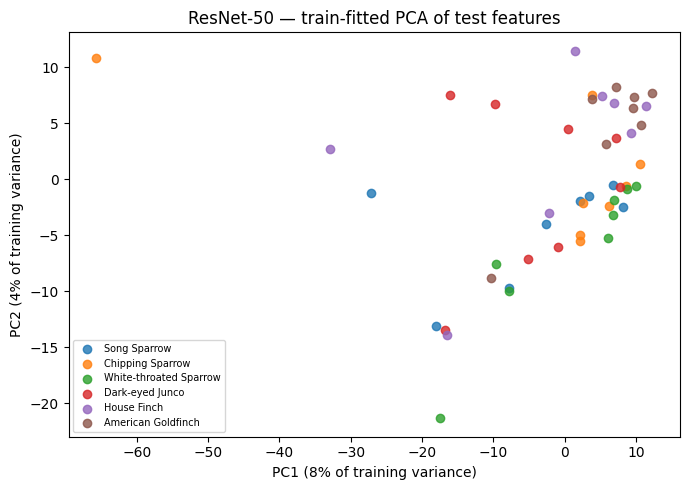

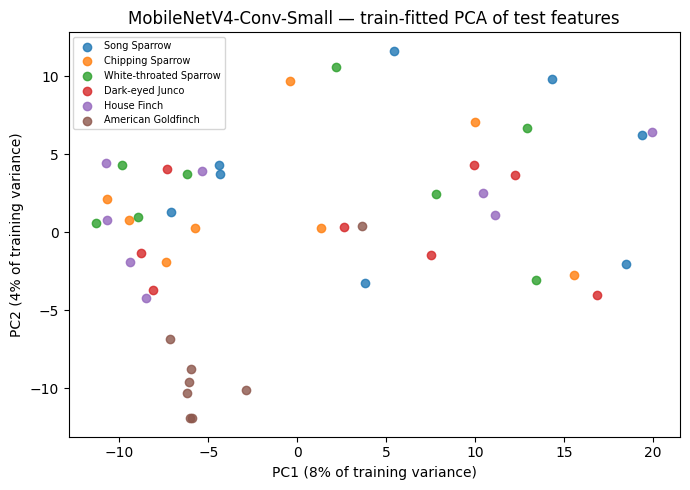

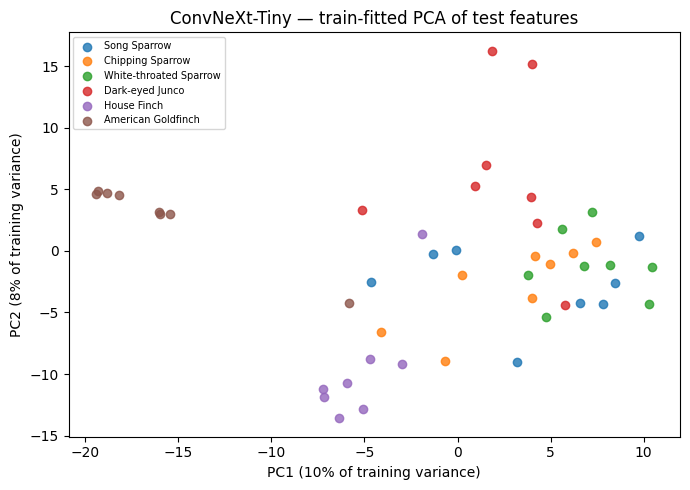

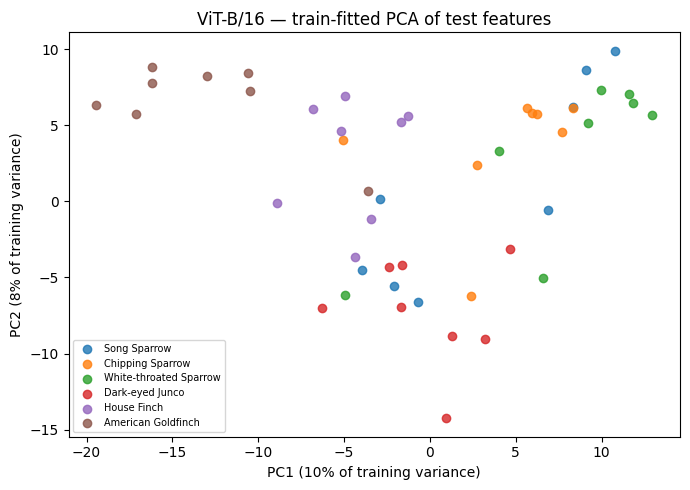

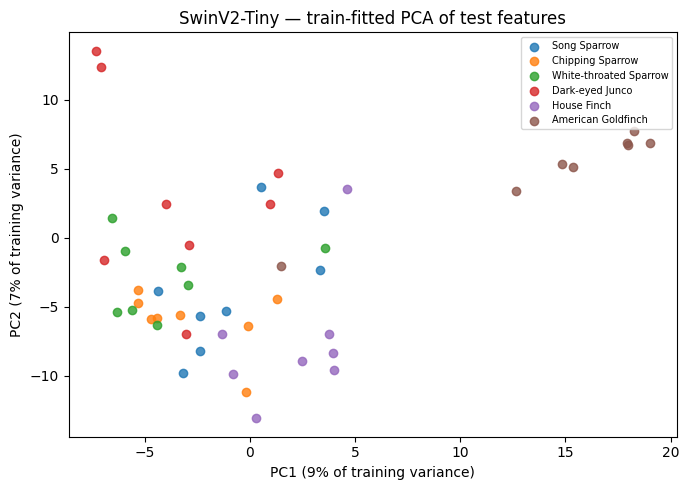

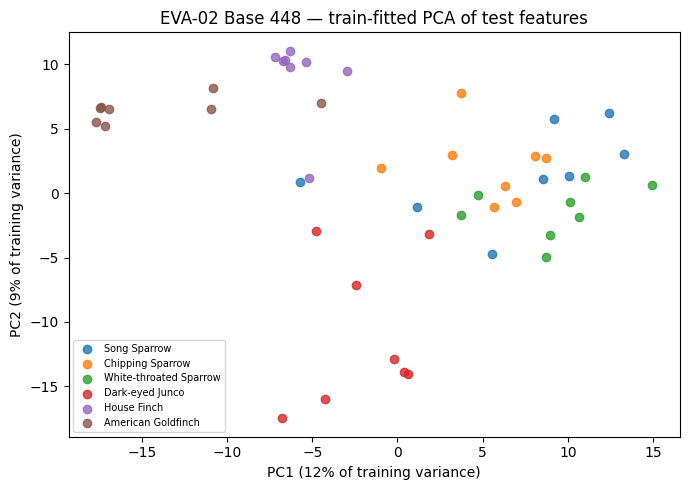

In [17]:
pca_rows=[]
if RUN_PCA_VISUALIZATION:
    for key,r in ALL_RESULTS.items():
        feat=ALL_FEATURES[key]
        mean,std,(tr,te)=standardize_from_train(feat["train"]["features"],feat["test"]["features"])
        tr_center=tr-tr.mean(axis=0,keepdims=True)
        _u,_s,vt=np.linalg.svd(tr_center,full_matrices=False)
        components=vt[:2].T
        explained=(_s**2)/np.sum(_s**2)
        te2=(te-tr.mean(axis=0,keepdims=True))@components

        fig=plt.figure(figsize=(7,5))
        ax=fig.add_subplot(111)
        for class_id,label in enumerate(CLASS_KEYS):
            mask=feat["test"]["labels"]==class_id
            ax.scatter(te2[mask,0],te2[mask,1],label=SPECIES[label][1],alpha=0.8)
            for point,source_id in zip(te2[mask],feat["test"]["source_ids"][mask],strict=True):
                pca_rows.append({"model":r["model"],"model_key":key,"source_id":str(source_id),
                                 "class_id":class_id,"class_label":label,
                                 "pc1":float(point[0]),"pc2":float(point[1])})
        ax.set_title(f"{r['model']} — train-fitted PCA of test features")
        ax.set_xlabel(f"PC1 ({explained[0]:.0%} of training variance)")
        ax.set_ylabel(f"PC2 ({explained[1]:.0%} of training variance)")
        ax.legend(fontsize=7)
        fig.tight_layout()
        fig.savefig(OUT_ROOT/"pca"/f"{key}.png",dpi=140)
        plt.show()
else:
    print("PCA visualization disabled.")

## 17. Accuracy/resource tradeoffs

Native preprocessing is deliberately preserved:

- 224×224: ResNet, MobileNetV4, ConvNeXt, ViT
- 256×256: SwinV2
- 448×448: EVA-02

Higher resolution provides more input detail but also changes compute cost. The comparison is therefore between deployable checkpoint configurations.

**What the latency column measures.** The median of repeated, warmed-up backbone feature-forward passes for one image, with GPU synchronisation. It excludes image decoding and preprocessing, moving the image to the GPU, and the probe itself. It compares backbones under the same measurement, but it is not the full image-to-label latency of a deployed service.

In [18]:
resource_rows=[]
for key,r in ALL_RESULTS.items():
    resource_rows.append({
        "model":r["model"],"model_key":key,
        "model_id":MODEL_REGISTRY[key]["manifest"]["modelId"],
        "revision":MODEL_REGISTRY[key]["manifest"]["revision"],
        "parameter_count":r["parameter_count"],"weight_bytes":r["weight_bytes"],
        "native_input_size":r["native_input_size"],"feature_dim":r["feature_dim"],
        "load_seconds":r["model_load_seconds"],
        "median_single_image_latency_s":r["median_single_image_latency_s"],
        "feature_extraction_seconds":r["feature_extraction_seconds"],
        "probe_training_seconds":r["probe_training_seconds"],
        "peak_gpu_memory_bytes":r["peak_gpu_memory_bytes"],
        "probe_accuracy":r["probe_metrics"]["accuracy"],
    })
for row in resource_rows:
    print({
        "model":row["model"],"params_m":row["parameter_count"]/1e6,
        "weights_mb":row["weight_bytes"]/1e6,"input":row["native_input_size"],
        "accuracy":row["probe_accuracy"],"backbone_forward_latency_ms":row["median_single_image_latency_s"]*1000,
    })

{'model': 'ResNet-50', 'params_m': 25.557032, 'weights_mb': 102.46984, 'input': 224, 'accuracy': 0.5, 'backbone_forward_latency_ms': 7.45728349997421}
{'model': 'MobileNetV4-Conv-Small', 'params_m': 3.774024, 'weights_mb': 15.223016, 'input': 224, 'accuracy': 0.5, 'backbone_forward_latency_ms': 4.4711534999635205}
{'model': 'ConvNeXt-Tiny', 'params_m': 28.589128, 'weights_mb': 114.374272, 'input': 224, 'accuracy': 0.7291666666666666, 'backbone_forward_latency_ms': 9.380831500010345}
{'model': 'ViT-B/16', 'params_m': 86.567656, 'weights_mb': 346.284714, 'input': 224, 'accuracy': 0.7916666666666666, 'backbone_forward_latency_ms': 13.18040099999962}
{'model': 'SwinV2-Tiny', 'params_m': 28.347154, 'weights_mb': 114.918618, 'input': 256, 'accuracy': 0.6666666666666666, 'backbone_forward_latency_ms': 14.696819500017}
{'model': 'EVA-02 Base 448', 'params_m': 87.117544, 'weights_mb': 348.492484, 'input': 448, 'accuracy': 0.8958333333333334, 'backbone_forward_latency_ms': 73.55299650001257}


## 18. Optional resolution-stress experiment

Disabled by default. Set `RUN_RESOLUTION_STRESS = True` in Section 3 to run it; it reloads every backbone once more, so it adds several minutes.

When enabled, each held-out test photo is first reduced so its longer side is 96 or 160 pixels (aspect ratio kept), then passed through the model's normal native preprocessing, which enlarges it again to the model's input size. The already-selected full-data probe is rebuilt from its saved artifact and reused unchanged: nothing is refitted or reselected, and each row records the probe file's SHA-256.

The table reports test accuracy, macro-F1 and log-loss for the original photos and for each reduced size. This probes sensitivity to source-image detail; it is a planned robustness check, not a way to choose a model.

In [19]:
resolution_stress_rows=[]

def reduce_resolution(image,longest_side):
    reduced=image.copy()
    reduced.thumbnail((longest_side,longest_side),Image.Resampling.BICUBIC)
    return reduced

if RUN_RESOLUTION_STRESS:
    for key,spec in MODEL_REGISTRY.items():
        probe=load_probe_artifact(OUT_ROOT/"probes"/key,spec)
        model,transform,_cfg,_root,_verify,_load=load_backbone(key)
        conditions=[("original",splits["test"])]+[
            (f"{size}px",[{**r,"image":reduce_resolution(r["image"],size)} for r in splits["test"]])
            for size in RESOLUTION_STRESS_SIZES
        ]
        for condition,part in conditions:
            feats=extract_features(model,transform,part)
            probs,_labels=probe_predict(probe,feats["features"])
            m=classification_metrics(feats["labels"],probs)
            resolution_stress_rows.append({
                "model":spec["display"],"model_key":key,"condition":condition,"n_images":m["n_images"],
                "accuracy":m["accuracy"],"macro_f1":m["macro_f1"],"log_loss":m["log_loss"],
                "probe_sha256":probe["manifest"]["probe_file"]["sha256"],
            })
        del model
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    print(f"{'Model':<27} {'Condition':>10} {'Accuracy':>9} {'Macro F1':>9} {'Log-loss':>9}")
    for row in resolution_stress_rows:
        print(f"{row['model']:<27} {row['condition']:>10} {row['accuracy']:>9.3f} {row['macro_f1']:>9.3f} {row['log_loss']:>9.3f}")
else:
    print("Resolution stress skipped (RUN_RESOLUTION_STRESS = False). No reduced-resolution results were produced.")

Resolution stress skipped (RUN_RESOLUTION_STRESS = False). No reduced-resolution results were produced.


## 19. Machine-readable exports

Exports include model metrics, per-class metrics, predictions, consensus, data-efficiency curves, representation geometry, resource observations, PCA coordinates, cached features, probe artifacts, and full provenance.

`predictions.csv` includes every class score (`score_<species>`), so accuracy, top-3 accuracy and log-loss can be recomputed from that file alone. `confusion_matrices.png`, `disagreement_gallery.png` and `pca/*.png` hold the figures shown above. These files describe the **built-in sample** run; the optional BYOD branch writes its own set under `byod/`.

In [20]:
def write_csv(path,rows,fieldnames):
    path.parent.mkdir(parents=True,exist_ok=True)
    with open(path,"w",encoding="utf-8",newline="") as f:
        w=csv.DictWriter(f,fieldnames=fieldnames); w.writeheader()
        for row in rows: w.writerow({k:row.get(k) for k in fieldnames})

model_metric_rows=[]
class_metric_rows=[]
geometry_rows=[]
for key,r in ALL_RESULTS.items():
    model_metric_rows.append({
        "model":r["model"],"model_key":key,"architecture_family":r["family"],
        "feature_dim":r["feature_dim"],
        "knn5_accuracy":r["knn_metrics"]["accuracy"],"knn5_macro_f1":r["knn_metrics"]["macro_f1"],
        "probe_accuracy":r["probe_metrics"]["accuracy"],"probe_macro_f1":r["probe_metrics"]["macro_f1"],
        "probe_top3_accuracy":r["probe_metrics"]["top3_accuracy"],"probe_log_loss":r["probe_metrics"]["log_loss"],
        "best_epoch":r["best_epoch"],"validation_log_loss":r["validation_log_loss"],
        "selected_at_first_epoch":r["selected_at_first_epoch"],"selected_at_epoch_cap":r["selected_at_epoch_cap"],
    })
    for cmr in r["probe_metrics"]["per_class"]:
        class_metric_rows.append({"model":r["model"],"model_key":key,**cmr})
    geometry_rows.append({"model":r["model"],"model_key":key,"feature_dim":r["feature_dim"],**r["geometry"]})

write_csv(OUT_ROOT/"model_metrics.csv",model_metric_rows,
          ["model","model_key","architecture_family","feature_dim","knn5_accuracy","knn5_macro_f1",
           "probe_accuracy","probe_macro_f1","probe_top3_accuracy","probe_log_loss","best_epoch","validation_log_loss",
           "selected_at_first_epoch","selected_at_epoch_cap"])
write_csv(OUT_ROOT/"class_metrics.csv",class_metric_rows,
          ["model","model_key","class_id","class_label","support","precision","recall","f1"])
write_csv(OUT_ROOT/"predictions.csv",prediction_rows,
          ["image_id","source_id","gold_label","model","predicted_label","correct","top1_score","top2_label","top2_score","margin",
           *[f"score_{label}" for label in CLASS_KEYS]])
write_csv(OUT_ROOT/"consensus.csv",consensus_rows,
          ["image_id","source_id","gold_label","models_correct","unique_predictions","difficulty_category"])
write_csv(OUT_ROOT/"data_efficiency.csv",data_efficiency_rows,
          ["model","model_key","train_images_per_class","train_images","best_epoch","validation_loss","test_accuracy","test_macro_f1"])
write_csv(OUT_ROOT/"representation_geometry.csv",geometry_rows,
          ["model","model_key","feature_dim","mean_same_class_cosine","mean_different_class_cosine","separability_gap"])
write_csv(OUT_ROOT/"resource_metrics.csv",resource_rows,
          ["model","model_key","model_id","revision","parameter_count","weight_bytes","native_input_size","feature_dim",
           "load_seconds","median_single_image_latency_s","feature_extraction_seconds","probe_training_seconds",
           "peak_gpu_memory_bytes","probe_accuracy"])
write_csv(OUT_ROOT/"pca_coordinates.csv",pca_rows,
          ["model","model_key","source_id","class_id","class_label","pc1","pc2"])
if resolution_stress_rows:
    write_csv(OUT_ROOT/"resolution_stress.csv",resolution_stress_rows,
              ["model","model_key","condition","n_images","accuracy","macro_f1","log_loss","probe_sha256"])

(OUT_ROOT/"dataset_manifest.json").write_text(
    json.dumps({
        "corpus":CORPUS_NAME,"release":CORPUS_RELEASE,"license":CORPUS_LICENSE,
        "source_bytes":CORPUS_BYTES,"seed":SAMPLE_SEED,
        "split_sizes":{k:len(v) for k,v in splits.items()},
        "dataset_digest":dataset_digest,
        "records":dataset_manifest,
    },indent=2),encoding="utf-8"
)

metrics_json={
    "majority_accuracy":majority_accuracy,
    "models":{
        key:{
            "knn5":{k:v for k,v in r["knn_metrics"].items() if k not in ("confusion_matrix","per_class","predicted_ids")},
            "probe":{k:v for k,v in r["probe_metrics"].items() if k not in ("confusion_matrix","per_class","predicted_ids")},
            "per_class":r["probe_metrics"]["per_class"],
            "confusion_matrix":r["probe_metrics"]["confusion_matrix"].tolist(),
            "geometry":r["geometry"],
            "best_epoch":r["best_epoch"],
            "validation_log_loss":r["validation_log_loss"],
            "reload_max_abs_probability_diff":r["probe_reload_max_abs_probability_diff"],
        }
        for key,r in ALL_RESULTS.items()
    },
    "data_efficiency":data_efficiency_rows,
}
(OUT_ROOT/"metrics.json").write_text(json.dumps(metrics_json,indent=2),encoding="utf-8")

provenance={
    "notebook_spec":"2.1","profile":"E2E","pedagogical_mode":"WORKSHOP","standalone":True,
    "notebook":{"file":NOTEBOOK_FILE,"revision":NOTEBOOK_REVISION},
    "observer_overlap":OBSERVER_OVERLAP,
    "knn_decision_rule":"5 nearest training features by cosine similarity; most votes, then larger summed similarity, then lower class id",
    "dataset":{"corpus":CORPUS_NAME,"license":CORPUS_LICENSE,"seed":SAMPLE_SEED,
               "split_sizes":{k:len(v) for k,v in splits.items()},"dataset_digest":dataset_digest},
    "models":{
        key:{
            "model_id":spec["manifest"]["modelId"],"revision":spec["manifest"]["revision"],
            "license":spec["license"],"manifest":spec["manifest"],
            "native_input_size":ALL_RESULTS[key]["native_input_size"],
            "feature_dim":ALL_RESULTS[key]["feature_dim"],
            "parameter_count":ALL_RESULTS[key]["parameter_count"],
        }
        for key,spec in MODEL_REGISTRY.items()
    },
    "probe_protocol":{
        "architecture":"nn.Linear(feature_dim, 6)","initialization":"zeros",
        "optimizer":"AdamW","learning_rate":PROBE_LR,"weight_decay":PROBE_WEIGHT_DECAY,
        "epochs":PROBE_EPOCHS,"selection":"lowest validation cross-entropy; earliest epoch tie-break",
        "feature_normalization":"training mean/std only",
    },
    "runtime":RUNTIME,
}
(OUT_ROOT/"provenance.json").write_text(json.dumps(provenance,indent=2),encoding="utf-8")

print("Exports:")
for path in sorted(OUT_ROOT.iterdir()):
    print(" ",path)

Exports:
  outputs/modern_image_classification/class_metrics.csv
  outputs/modern_image_classification/confusion_matrices.png
  outputs/modern_image_classification/consensus.csv
  outputs/modern_image_classification/data_efficiency.csv
  outputs/modern_image_classification/dataset_manifest.json
  outputs/modern_image_classification/disagreement_gallery.png
  outputs/modern_image_classification/features
  outputs/modern_image_classification/metrics.json
  outputs/modern_image_classification/model_metrics.csv
  outputs/modern_image_classification/pca
  outputs/modern_image_classification/pca_coordinates.csv
  outputs/modern_image_classification/predictions.csv
  outputs/modern_image_classification/probes
  outputs/modern_image_classification/provenance.json
  outputs/modern_image_classification/representation_geometry.csv
  outputs/modern_image_classification/resource_metrics.csv


## 20. Bring Your Own Data

BYOD uses the **same E2E protocol** rather than inference only: frozen features, 5-NN, a common linear probe selected on your validation images, one test evaluation, and a saved probe that is rebuilt from its files and checked.

**Input.** A directory, or a ZIP of one, containing `labels.csv` and the images. Folders inside the ZIP are kept, so a `filename` such as `images/a1.jpg` means the same thing in a directory and in a ZIP. `labels.csv` needs the columns `filename,label,split`, where split is exactly `train`, `validation` or `test`, and every `filename` is a relative path inside the dataset.

**Enforced requirements.** The notebook checks these before decoding any image and stops with a message if one fails:

- 2–20 classes and 60–600 images in total;
- at least 10 training, 2 validation and 2 test images per class;
- image files ending in `.jpg`, `.jpeg`, `.png`, `.webp`, `.tif`, `.tiff` or `.bmp`, each listed once;
- no absolute paths, `..`, symbolic links or paths that leave the dataset folder, in the ZIP or in `labels.csv`;
- a ZIP of at most 1 GB expanded, with no two members that would land on the same file;
- no identical decoded image in two different splits.

Labels are kept as text exactly as written (after trimming surrounding spaces), so `001` and `NA` are ordinary class names. Your test images are never used for validation.

**Where your data goes.** Every ZIP upload is unpacked into a new folder of its own under `byod_modern_image/`, used only if the whole dataset passes the checks, and removed if it fails, so an earlier or later upload can never fill in a missing file. A directory you point to is read in place and never modified or deleted.

**Privacy.** Your images are processed in this notebook's runtime, not sent to a DIMER worker or API. A hosted notebook such as Colab is still an external compute environment, not an on-premises system: do not upload confidential, personal, biometric, restricted or regulated images unless you are authorised to process them there. The BYOD outputs under `byod/` contain your labels, file names, per-image predictions and scores, and the trained probes.

In [21]:
import shutil
import tempfile

BYOD_EXTENSIONS={".jpg",".jpeg",".png",".webp",".tif",".tiff",".bmp"}
BYOD_STAGING_ROOT=Path("byod_modern_image")
BYOD_MAX_EXPANDED_BYTES=1_000_000_000

def safe_relative_path(name,what):
    """A relative path that stays inside its root: no absolute path, drive, '..' or empty part."""
    name=name.replace("\\","/")
    parts=name.split("/")
    if name.startswith("/") or (parts and ":" in parts[0]) or any(p in ("","..",".") for p in parts[:-1]) or parts[-1] in ("","..","."):
        raise ValueError(f"Unsafe {what}: {name!r}")
    return "/".join(parts)

def stage_byod_zip(source):
    """Validate the whole archive, then unpack it into a new folder owned by this notebook, keeping its folders."""
    members=[]
    seen=set()
    expanded=0
    with zipfile.ZipFile(source) as zf:
        for info in zf.infolist():
            if info.is_dir():
                continue
            name=safe_relative_path(info.filename,"ZIP member")
            mode=(info.external_attr>>16)&0o170000
            if mode==0o120000:
                raise ValueError(f"Symlink ZIP member refused: {name}")
            if name.casefold() in seen:
                raise ValueError(f"Two ZIP members would write the same file: {name}")
            seen.add(name.casefold())
            expanded+=info.file_size
            if expanded>BYOD_MAX_EXPANDED_BYTES:
                raise ValueError("BYOD ZIP exceeds 1 GB expanded")
            members.append((info,name))
        BYOD_STAGING_ROOT.mkdir(exist_ok=True)
        staged=Path(tempfile.mkdtemp(prefix="upload-",dir=BYOD_STAGING_ROOT))
        try:
            for info,name in members:
                target=staged.joinpath(*name.split("/"))
                target.parent.mkdir(parents=True,exist_ok=True)
                with zf.open(info) as src, open(target,"xb") as dst:
                    shutil.copyfileobj(src,dst)
        except BaseException:
            shutil.rmtree(staged,ignore_errors=True)
            raise
    return staged

def find_labels_root(root):
    if (root/"labels.csv").is_file():
        return root
    children=[p for p in root.iterdir() if not p.name.startswith((".","__MACOSX"))]
    if len(children)==1 and children[0].is_dir() and (children[0]/"labels.csv").is_file():
        return children[0]
    raise ValueError("BYOD requires labels.csv at the top level or inside one wrapping folder")

def resolve_byod_image(root,filename):
    """The listed image, which must be a regular file inside the dataset folder and not reached through a link."""
    relative=safe_relative_path(filename,"filename in labels.csv")
    path=root.joinpath(*relative.split("/"))
    for step in [path,*path.parents]:
        if step==root:
            break
        if step.is_symlink():
            raise ValueError(f"Symbolic links are not allowed in the dataset: {filename}")
    resolved=path.resolve()
    if root.resolve() not in resolved.parents:
        raise ValueError(f"Image path leaves the dataset folder: {filename}")
    if path.suffix.lower() not in BYOD_EXTENSIONS or not path.is_file():
        raise ValueError(f"Unsupported/missing image {filename}")
    return path

def read_byod_table(root):
    """Check labels.csv against every requirement that does not need an image to be decoded."""
    table=root/"labels.csv"
    with table.open(encoding="utf-8",newline="") as handle:
        rows=list(csv.DictReader(handle))
    required={"filename","label","split"}
    if not rows or not required.issubset(rows[0]):
        raise ValueError("labels.csv must contain filename,label,split")
    allowed=("train","validation","test")
    labels=sorted({r["label"].strip() for r in rows})
    if "" in labels:
        raise ValueError("Every row needs a non-empty label")
    if not 2<=len(labels)<=20:
        raise ValueError("BYOD must contain 2..20 classes")
    if not 60<=len(rows)<=600:
        raise ValueError("BYOD must contain 60..600 images")
    listed=Counter(safe_relative_path(r["filename"].strip(),"filename in labels.csv").casefold() for r in rows)
    repeated=[name for name,count in listed.items() if count>1]
    if repeated:
        raise ValueError(f"Images listed more than once in labels.csv: {repeated[:5]}")
    for r in rows:
        if r["split"].strip().lower() not in allowed:
            raise ValueError(f"Unknown split {r['split']!r}")
    for label in labels:
        counts={s:sum(r["label"].strip()==label and r["split"].strip().lower()==s for r in rows) for s in allowed}
        if counts["train"]<10 or counts["validation"]<2 or counts["test"]<2:
            raise ValueError(f"{label}: insufficient explicit split counts {counts}")
    paths=[resolve_byod_image(root,r["filename"].strip()) for r in rows]
    return rows,labels,paths

def load_byod_explicit(path):
    source=Path(path)
    staged=None
    if source.is_file() and source.suffix.lower()==".zip":
        staged=stage_byod_zip(source)
        root=staged
    elif source.is_dir():
        root=source
    else:
        raise ValueError("BYOD_PATH must be a directory or ZIP")
    try:
        root=find_labels_root(root)
        rows,labels,paths=read_byod_table(root)
        label_to_id={label:i for i,label in enumerate(labels)}
        out={k:[] for k in ("train","validation","test")}
        pixel_seen={}
        for i,(row,p) in enumerate(zip(rows,paths,strict=True)):
            split=row["split"].strip().lower()
            image=Image.open(p)
            image.load()
            image=image.convert("RGB")
            pix=image_digest(image)
            if pix in pixel_seen and pixel_seen[pix]!=split:
                raise ValueError(f"Duplicate decoded image crosses splits: {row['filename']}")
            pixel_seen[pix]=split
            label=row["label"].strip()
            out[split].append({
                "id":f"{split}-{i:04d}","source_id":row["filename"].strip(),"split":split,
                "label":label,"label_id":label_to_id[label],
                "image":image,"pixel_sha256":pix,
            })
    except BaseException:
        # Only a folder this notebook created for this upload is ever removed.
        if staged is not None:
            shutil.rmtree(staged,ignore_errors=True)
        raise
    return out,labels

def generic_classification_metrics(y_true,probs,class_names,predicted_ids=None):
    return classification_metrics(y_true,probs,class_names,predicted_ids)

def generic_fit_probe(train_x,train_y,val_x,val_y,test_x,n_classes):
    return fit_probe(train_x,train_y,val_x,val_y,test_x,n_classes=n_classes)

def save_generic_probe(root,key,spec,probe,class_names,feature_dim,split_digests):
    pdir=root/"probes"/key
    pdir.mkdir(parents=True,exist_ok=True)
    pfile=pdir/"probe.safetensors"
    save_file({
        "classifier.weight":probe["layer"].weight.detach().cpu().contiguous(),
        "classifier.bias":probe["layer"].bias.detach().cpu().contiguous(),
        "feature_mean":torch.from_numpy(probe["mean"]).contiguous(),
        "feature_std":torch.from_numpy(probe["std"]).contiguous(),
    },str(pfile))
    base_sha=next(x["sha256"] for x in spec["manifest"]["files"] if x["path"]=="model.safetensors")
    manifest={
        "format":"dimer_linear_probe","format_version":1,
        "base_model_id":spec["manifest"]["modelId"],
        "base_model_revision":spec["manifest"]["revision"],
        "base_weight_sha256":base_sha,
        "feature_interface":"pre_logits","feature_dim":feature_dim,
        "class_order":class_names,
        "probe":{"best_epoch":probe["best_epoch"],"optimizer":"AdamW",
                 "learning_rate":PROBE_LR,"weight_decay":PROBE_WEIGHT_DECAY},
        "training_sample_digest":split_digests["train"],
        "validation_sample_digest":split_digests["validation"],
        "probe_file":{"bytes":pfile.stat().st_size,"sha256":sha256_file(pfile)},
    }
    (pdir/"manifest.json").write_text(json.dumps(manifest,indent=2),encoding="utf-8")
    return pfile,manifest

def byod_split_digest(part):
    payload=[[r["source_id"],r["label_id"],r["pixel_sha256"]] for r in part]
    return hashlib.sha256(json.dumps(payload,separators=(",",":")).encode()).hexdigest()

byod_summary=[]
if USE_BYOD:
    byod_splits,byod_labels=load_byod_explicit(BYOD_PATH)
    selected_keys=[k for k in BYOD_MODEL_KEYS if k in MODEL_REGISTRY]
    if not selected_keys:
        raise ValueError("BYOD_MODEL_KEYS contains no valid model keys")
    byod_root=OUT_ROOT/"byod"
    byod_root.mkdir(parents=True,exist_ok=True)
    n_classes=len(byod_labels)
    byod_prediction_rows=[]
    byod_class_rows=[]

    for key in selected_keys:
        spec=MODEL_REGISTRY[key]
        print(f"BYOD — {spec['display']}")
        model,transform,data_cfg,_snapshot,_verify,_load=load_backbone(key)
        tr=extract_features(model,transform,byod_splits["train"])
        va=extract_features(model,transform,byod_splits["validation"])
        te=extract_features(model,transform,byod_splits["test"])

        _mean,_std,(tr_std,_va_std,te_std)=standardize_from_train(
            tr["features"],va["features"],te["features"]
        )
        knn_pred,knn_probs=knn_predict(tr_std,tr["labels"],te_std,KNN_K,n_classes=n_classes)
        knn_metrics=classification_metrics(te["labels"],knn_probs,byod_labels,predicted_ids=knn_pred)

        probe=fit_probe(
            tr["features"],tr["labels"],va["features"],va["labels"],te["features"],n_classes=n_classes
        )
        probe_metrics=classification_metrics(te["labels"],probe["test_probs"],byod_labels)

        pfile,pmanifest=save_generic_probe(
            byod_root,key,spec,probe,byod_labels,int(getattr(model,"head_hidden_size",model.num_features)),
            {
                "train":byod_split_digest(byod_splits["train"]),
                "validation":byod_split_digest(byod_splits["validation"]),
            },
        )
        reload_diff=reload_probe_verify(pfile.parent,spec,te["features"],probe["test_probs"],byod_labels)

        for i,record in enumerate(byod_splits["test"]):
            scores=probe["test_probs"][i]
            byod_prediction_rows.append({
                "model_key":key,"image_id":record["id"],"filename":record["source_id"],
                "gold_label":record["label"],"predicted_label":byod_labels[int(scores.argmax())],
                "knn_predicted_label":byod_labels[int(knn_pred[i])],
                **{f"score_{label}":float(scores[c]) for c,label in enumerate(byod_labels)},
            })
        for row in probe_metrics["per_class"]:
            byod_class_rows.append({"model_key":key,**row})

        byod_summary.append({
            "model":spec["display"],"model_key":key,
            "classes":n_classes,"train_images":len(byod_splits["train"]),
            "validation_images":len(byod_splits["validation"]),
            "test_images":len(byod_splits["test"]),
            "knn5_accuracy":knn_metrics["accuracy"],
            "probe_accuracy":probe_metrics["accuracy"],
            "probe_macro_f1":probe_metrics["macro_f1"],
            "probe_top3_accuracy":probe_metrics["top3_accuracy"],
            "probe_log_loss":probe_metrics["log_loss"],
            "best_epoch":probe["best_epoch"],
            "validation_loss":probe["validation_loss"],
            "reload_max_abs_probability_diff":reload_diff,
        })

        del model,probe
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    write_csv(
        byod_root/"summary.csv",byod_summary,
        ["model","model_key","classes","train_images","validation_images","test_images",
         "knn5_accuracy","probe_accuracy","probe_macro_f1","probe_top3_accuracy","probe_log_loss",
         "best_epoch","validation_loss","reload_max_abs_probability_diff"]
    )
    write_csv(
        byod_root/"predictions.csv",byod_prediction_rows,
        ["model_key","image_id","filename","gold_label","predicted_label","knn_predicted_label",
         *[f"score_{label}" for label in byod_labels]]
    )
    write_csv(
        byod_root/"class_metrics.csv",byod_class_rows,
        ["model_key","class_id","class_label","support","precision","recall","f1"]
    )
    (byod_root/"provenance.json").write_text(json.dumps({
        "notebook":{"file":NOTEBOOK_FILE,"revision":NOTEBOOK_REVISION},
        "source":str(BYOD_PATH),
        "class_order":byod_labels,
        "split_counts":{k:len(v) for k,v in byod_splits.items()},
        "model_keys":selected_keys,
        "knn_decision_rule":"5 nearest training features by cosine similarity; most votes, then larger summed similarity, then lower class id",
        "probe_protocol":{
            "optimizer":"AdamW","learning_rate":PROBE_LR,
            "weight_decay":PROBE_WEIGHT_DECAY,"epochs":PROBE_EPOCHS,
            "selection":"lowest validation cross-entropy",
        },
        "runtime":RUNTIME,
    },indent=2),encoding="utf-8")

    byod_required=[byod_root/"summary.csv",byod_root/"predictions.csv",byod_root/"class_metrics.csv",byod_root/"provenance.json"]
    byod_required+=[byod_root/"probes"/k/name for k in selected_keys for name in ("probe.safetensors","manifest.json")]
    missing=[str(p) for p in byod_required if not p.is_file()]
    if missing:
        raise RuntimeError(f"BYOD outputs missing: {missing}")
    print("BYOD complete. Files written under",byod_root)
    for p in byod_required:
        print(" ",p)
    for row in byod_summary:
        print({k:row[k] for k in ("model","knn5_accuracy","probe_accuracy","probe_macro_f1","best_epoch")})
else:
    print("BYOD disabled on the canonical Run all path.")

BYOD disabled on the canonical Run all path.


## 21. Interpretation and limitations

### This is representation transfer, not native-head classification

The fitted head is deliberately simple. Differences indicate how linearly useful the frozen checkpoint representations are for this downstream six-species task.

### This is not architecture alone

Results also reflect pretraining data, objectives, training recipe, model size and input resolution.

### Native resolution is part of deployment cost

EVA-02 receives 448×448 inputs while several competitors receive 224×224. Its quality and latency must be interpreted together.

### 5-NN and linear probes answer different questions

5-NN asks whether nearby frozen representations are already grouped by species. The linear probe asks whether a learned linear boundary can separate them.

### Small-data curves are useful

A checkpoint that transfers well with six labelled examples/species may be attractive even if another has a slightly higher full-data result.

### The test set is small, and not fully independent

There are 48 test photographs, so one photo moves accuracy by about 2.1 percentage points; differences of one or two photos between models are weak evidence. Several observers contributed photos to more than one split (the split cell reports how many), so test photos can share a photographer, camera or site with training photos. The pretrained checkpoints may also have seen related iNaturalist images during pretraining. Treat the results as tutorial evidence for this sample, not a benchmark.

### Softmax scores are not calibrated probabilities

No universal confidence threshold is established.

## 22. Terminal summary

The final cell verifies the required output inventory and prints the measured comparison without declaring a universal winner. These totals are for the built-in sample; the optional BYOD branch prints and checks its own inventory under `byod/`.

In [22]:
required_outputs=[
    OUT_ROOT/"model_metrics.csv",OUT_ROOT/"class_metrics.csv",OUT_ROOT/"predictions.csv",
    OUT_ROOT/"consensus.csv",OUT_ROOT/"data_efficiency.csv",OUT_ROOT/"representation_geometry.csv",
    OUT_ROOT/"resource_metrics.csv",OUT_ROOT/"metrics.json",OUT_ROOT/"provenance.json",
    OUT_ROOT/"dataset_manifest.json",
]
missing=[str(p) for p in required_outputs if not p.is_file()]
if missing:
    raise RuntimeError(f"Required outputs missing: {missing}")

for key in MODEL_REGISTRY:
    if not (OUT_ROOT/"features"/f"{key}.npz").is_file():
        raise RuntimeError(f"Missing feature archive for {key}")
    if not (OUT_ROOT/"probes"/key/"probe.safetensors").is_file():
        raise RuntimeError(f"Missing probe artifact for {key}")
    if not (OUT_ROOT/"probes"/key/"manifest.json").is_file():
        raise RuntimeError(f"Missing probe manifest for {key}")

print("DIMER Modern Image Classification Workshop")
print("-"*51)
print("Dataset:")
print(f"  train: {len(splits['train'])}")
print(f"  validation: {len(splits['validation'])}")
print(f"  test: {len(splits['test'])}")
print(f"  classes: {len(CLASS_KEYS)}")
print()
print(f"{'Model':<27} {'5NN Acc':>8} {'Probe Acc':>10} {'Macro F1':>9} {'Feat':>6}")
print("-"*66)
for key,r in ALL_RESULTS.items():
    print(f"{r['model']:<27} {r['knn_metrics']['accuracy']:>8.3f} "
          f"{r['probe_metrics']['accuracy']:>10.3f} {r['probe_metrics']['macro_f1']:>9.3f} "
          f"{r['feature_dim']:>6}")
print()
print(f"Outputs: {OUT_ROOT}/")

DIMER Modern Image Classification Workshop
---------------------------------------------------
Dataset:
  train: 108
  validation: 24
  test: 48
  classes: 6

Model                        5NN Acc  Probe Acc  Macro F1   Feat
------------------------------------------------------------------
ResNet-50                      0.500      0.500     0.467   2048
MobileNetV4-Conv-Small         0.417      0.500     0.505   1280
ConvNeXt-Tiny                  0.729      0.729     0.727    768
ViT-B/16                       0.792      0.792     0.789    768
SwinV2-Tiny                    0.583      0.667     0.644    768
EVA-02 Base 448                0.833      0.896     0.896    768

Outputs: outputs/modern_image_classification/


## Try it yourself — one controlled change

Use the same experimental discipline as the canonical path:

**Predict → change one variable → rerun → observe → explain**

**Question:** how much does each representation lose when the probe sees fewer labelled training photos?

1. **Plan and predict.** In the next cell, set `ACTIVITY_PER_CLASS` (for example `[6, 12, 18]`) and write down which backbones you expect to lose the most. Running the cell saves this plan in `activity/plan.json` before any result.
2. **Change one thing.** The only thing that changes is the number of training photos per species. The same nested subsets, validation photos, probe recipe and selection rule are used for every model.
3. **Run.** Set `RUN_VALIDATION_ACTIVITY = True` and run the cell. It reads the training and validation features only. The test split is never read, scored or saved, and the results go to `activity/`, separate from the canonical results.
4. **Observe.** For each backbone and training size, the table shows validation log-loss and accuracy, the selected epoch, the number of training photos, and the change from the full training set.
5. **Explain.** "I predicted __. With __ photos per species, __ lost __ in validation log-loss compared with the full set. This suggests __, with uncertainty from __ (only 24 validation photos)."

You have already seen test results in Sections 10–15. Rerunning this activity cannot make the test split untouched again, so do not use it to pick a model and then quote the test score as independent evidence.

In [23]:
RUN_VALIDATION_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_PER_CLASS = [6, 12, 18]  # training photos per species; the full set is always included for comparison

def validation_activity(per_class_values):
    """Fit probes on nested training subsets and score them on validation only. The test split is not read."""
    rows=[]
    full=len(splits["train"])//len(CLASS_KEYS)
    for per_class in sorted(set(per_class_values)|{full}):
        idx=nested_train_indices(splits["train"],per_class)
        for key,r in ALL_RESULTS.items():
            feat=ALL_FEATURES[key]
            probe=fit_probe(
                feat["train"]["features"][idx],feat["train"]["labels"][idx],
                feat["validation"]["features"],feat["validation"]["labels"],
            )
            rows.append({
                "model":r["model"],"model_key":key,
                "train_images_per_class":per_class,"train_images":len(idx),
                "best_epoch":probe["best_epoch"],
                "validation_log_loss":probe["validation_loss"],
                "validation_accuracy":probe["validation_accuracy"],
            })
    reference={row["model_key"]:row for row in rows if row["train_images_per_class"]==full}
    for row in rows:
        row["log_loss_change_vs_full"]=row["validation_log_loss"]-reference[row["model_key"]]["validation_log_loss"]
    return rows

activity_dir=OUT_ROOT/"activity"
if RUN_VALIDATION_ACTIVITY:
    activity_dir.mkdir(parents=True,exist_ok=True)
    plan={"question":"validation cost of fewer labelled training photos","per_class":sorted(set(ACTIVITY_PER_CLASS)),
          "unchanged":["validation photos","probe recipe","selection rule","nested subset order"],
          "test_split":"not read"}
    (activity_dir/"plan.json").write_text(json.dumps(plan,indent=2),encoding="utf-8")
    activity_rows=validation_activity(ACTIVITY_PER_CLASS)
    write_csv(activity_dir/"validation_results.csv",activity_rows,
              ["model","model_key","train_images_per_class","train_images","best_epoch",
               "validation_log_loss","validation_accuracy","log_loss_change_vs_full"])
    print(f"{'Model':<27} {'Per class':>9} {'Images':>7} {'Epoch':>6} {'Val loss':>9} {'Val acc':>8} {'Δ loss vs full':>15}")
    for row in activity_rows:
        print(f"{row['model']:<27} {row['train_images_per_class']:>9} {row['train_images']:>7} {row['best_epoch']:>6} "
              f"{row['validation_log_loss']:>9.3f} {row['validation_accuracy']:>8.3f} {row['log_loss_change_vs_full']:>+15.3f}")
    print("Saved to",activity_dir,"— validation only; no test data was read.")
else:
    print("Validation-only activity skipped (RUN_VALIDATION_ACTIVITY = False).")

Validation-only activity skipped (RUN_VALIDATION_ACTIVITY = False).


## Self-paced checkpoint

Before opening the sample interpretation, answer:

1. What did the model/system receive as input, and what did it produce?
2. Which baseline/reference tells you whether the learned model added value?
3. What failure mode or tradeoff matters most here?
4. What additional evidence would you want before transferring the result to a new domain?

<details>
<summary><b>Show a sample interpretation</b></summary>

This notebook compares pretrained checkpoint representations under common downstream probes. It is not a pure architecture ablation because pretraining data, recipes, capacities, preprocessing, and resolutions differ. Compare representation quality and resource cost, not just the highest single accuracy.

Use the outputs from **your run** when writing your final answer; small numeric differences across supported runtimes are possible.

</details>


## Write an evidence-based conclusion

1. **State the question** tested by this notebook.
2. **Report the primary result** against the relevant baseline/reference.
3. **Add supporting evidence** from a secondary metric, error pattern, disagreement, or qualitative diagnostic.
4. **Account for cost/complexity** when it materially affects the comparison.
5. **State the limits** of the data, split, model revision, and configuration.

Report the common-probe result against the majority reference, use the k-NN/linear-probe or representation-geometry evidence to explain the result, describe the data-efficiency tradeoff, and keep claims specific to these checkpoints and the six-species sample.


# Troubleshooting

| What you see | Likely cause | What to do |
|---|---|---|
| Accelerator unavailable or execution is unexpectedly slow | The runtime does not match the documented resource envelope | Select the documented accelerator/runtime, start a fresh session, and run top-to-bottom. |
| The setup cell stops with "needs a Linux x86_64 runtime" | The locked environment is built from Linux x86_64 wheels | Use Google Colab, Kaggle or a Linux x86_64 Jupyter server; Windows and macOS kernels are not supported. |
| The setup cell fails while downloading (`uv`, Python or a package) | The runtime cannot reach PyPI, `files.pythonhosted.org` or the managed-Python download, or a download did not match its pinned size or hash | Check network access and run the setup cell again. A size or SHA-256 mismatch is refused; do not bypass it. |
| "The isolated environment's Python process exited" | The worker running the notebook's cells was stopped, usually by running out of memory | Restart the session and choose **Run all**; the environment is reused if the runtime was kept. Do not enable resolution stress and BYOD in the same run. |
| Model/sample digest or byte-size check fails | Download is incomplete or upstream bytes differ from the pinned artifact | Remove the affected runtime cache/download and rerun. Do not disable the integrity check. |
| Out-of-memory or runtime restart | Too many large models/intermediates are resident | Backbones are loaded one at a time; keep `FEATURE_BATCH_SIZE` small and do not enable the optional resolution-stress and BYOD branches in the same run. |
| BYOD validation fails | Input does not satisfy the requirements in Section 20 | Follow the validation message, correct the indicated field/format, then rerun the BYOD branch. A corrected ZIP is unpacked into a new folder, so files from an earlier upload are never reused. |
| Your numbers differ slightly | Supported hardware/library execution can introduce small numerical variation | Verify the split, model revision, metric definition, and qualitative pattern before treating the difference as substantive. |

# Glossary

| Term | Meaning in this notebook |
|---|---|
| **Representation** | A numerical description of an image produced by a pretrained backbone. |
| **Frozen backbone** | A feature extractor whose pretrained parameters are not updated. |
| **Linear probe** | A simple classifier trained on frozen representations. |
| **k-NN** | k-nearest neighbors; a non-parametric prediction rule based on nearby representations. |
| **Representation geometry** | How examples and classes are arranged relative to one another in feature space. |
| **PCA** | Principal Component Analysis; a linear projection used here to visualize dominant directions in representations. |